# Gastronomic Studies
## Restaurent Review

Dataset url - https://www.kaggle.com/datasets/batjoker/zomato-restaurants-hyderabad?select=Restaurant+reviews.csv

# Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.width", 120)

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
DATA_PATH = Path("Restaurant reviews.csv")
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Dataset loaded successfully.
Rows: 10,000
Columns: 7


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,"Soumen das and Arun was a great guy. Only because of their behavior and sincerety, And good food off course, I would like to visit this place again.",5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and basket mutton biryani. All are good. Thanks to Pradeep. He served well. We enjoyed here. Ambience is also very good.,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


In [ ]:
missing_values = df.isnull().sum()
print("Missing values in each column:\n")
print(missing_values)
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("Missing-value percentage:\n")
print(missing_percentage.round(2))

Missing values in each column:

Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64
Missing-value percentage:

Restaurant    0.00
Reviewer      0.38
Review        0.45
Rating        0.38
Metadata      0.38
Time          0.38
Pictures      0.00
dtype: float64


In [ ]:
exact_duplicates = df.duplicated().sum()
duplicate_reviews = df["Review"].duplicated().sum()
print("Number of exact duplicate rows:", exact_duplicates)
print("Number of duplicate review texts:", duplicate_reviews)

Number of exact duplicate rows: 36
Number of duplicate review texts: 635


In [ ]:
number_of_restaurants = df["Restaurant"].nunique()
reviews_per_restaurant = df["Restaurant"].value_counts()
print("Number of unique restaurants:", number_of_restaurants)
print("Reviews per restaurant:")
print(reviews_per_restaurant)

Number of unique restaurants: 100
Reviews per restaurant:
Restaurant
Beyond Flavours                    100
Paradise                           100
Flechazo                           100
Shah Ghouse Hotel & Restaurant     100
Over The Moon Brew Company         100
                                  ... 
Desi Bytes                         100
Hyderabadi Daawat                  100
Zega - Sheraton Hyderabad Hotel    100
Triptify                           100
Chinese Pavilion                   100
Name: count, Length: 100, dtype: int64


In [ ]:
audit = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Values": df.isnull().sum().values,
    "Missing (%)": (df.isnull().sum().values / len(df) * 100).round(2),
    "Unique Values": df.nunique().values
})
display(audit)

,Column,Data Type,Missing Values,Missing (%),Unique Values
0,Restaurant,object,0,0.00,100
1,Reviewer,object,38,0.38,7446
2,Review,object,45,0.45,9364
3,Rating,object,38,0.38,10
4,Metadata,object,38,0.38,2477
5,Time,object,38,0.38,9782
6,Pictures,int64,0,0.00,36


# Data Investigation

## Rating

In [ ]:
rating_counts = df["Rating"].value_counts(dropna=False).sort_index()
print("Rating distribution:")
display(rating_counts)

Rating distribution:


,count
Rating,
1,1735
1.5,9
2,684
2.5,19
3,1193
3.5,47
4,2373
4.5,69
5,3832


In [ ]:
df["Rating_numeric"] = pd.to_numeric(
    df["Rating"],
    errors="coerce"
)
print("Rating values after numeric conversion:")
print(sorted(df["Rating_numeric"].dropna().unique()))

Rating values after numeric conversion:
[np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]


In [ ]:
invalid_ratings = df[
    df["Rating_numeric"].isna() & df["Rating"].notna()
]
print("Invalid/non-numeric ratings:")
display(invalid_ratings[["Restaurant", "Review", "Rating"]])

Invalid/non-numeric ratings:


,Restaurant,Review,Rating
7601,The Old Madras Baking Company,One of the best pizzas to try. It served with the fresh crust and the topping of veggies are fresh and the taste of the ingredients was awesome and it is fully overloaded with Cheese. I would like...,Like


In [ ]:
print("Minimum numeric rating:", df["Rating_numeric"].min())
print("Maximum numeric rating:", df["Rating_numeric"].max())

Minimum numeric rating: 1.0
Maximum numeric rating: 5.0


## Duplicates

In [ ]:
duplicate_review_counts = (
    df["Review"]
    .value_counts()
    .reset_index()
)

duplicate_review_counts.columns = ["Review", "Frequency"]

duplicate_review_counts = duplicate_review_counts[
    duplicate_review_counts["Frequency"] > 1
]

print("Number of review texts appearing more than once:",
      len(duplicate_review_counts))

display(duplicate_review_counts.head(20))

Number of review texts appearing more than once: 99


,Review,Frequency
0,good,237
1,Good,49
2,nice,30
3,very good,23
4,excellent,20
5,good service,14
6,super,13
7,not good,13
8,awesome,12
9,good delivery,12


In [ ]:
duplicate_within_restaurant = df.duplicated(
    subset=["Restaurant", "Review"],
    keep=False
)

print(
    "Rows involved in duplicate Restaurant + Review combinations:",
    duplicate_within_restaurant.sum()
)

display(
    df.loc[
        duplicate_within_restaurant,
        ["Restaurant", "Review", "Rating"]
    ].sort_values(["Restaurant", "Review"]).head(20)
)

Rows involved in duplicate Restaurant + Review combinations: 395


,Restaurant,Review,Rating
2097,13 Dhaba,good,5
2099,13 Dhaba,good,5
8243,Al Saba Restaurant,Good job,5
8253,Al Saba Restaurant,Good job,5
8222,Al Saba Restaurant,good,4
8223,Al Saba Restaurant,good,5
8232,Al Saba Restaurant,good,5
8236,Al Saba Restaurant,good,4
8247,Al Saba Restaurant,nice,5
8276,Al Saba Restaurant,nice,3


In [ ]:
review_restaurant_counts = (
    df.groupby("Review")["Restaurant"]
      .nunique()
)

cross_restaurant_reviews = review_restaurant_counts[
    review_restaurant_counts > 1
]

print(
    "Review texts appearing for multiple restaurants:",
    len(cross_restaurant_reviews)
)

display(
    cross_restaurant_reviews
    .sort_values(ascending=False)
    .head(20)
)

Review texts appearing for multiple restaurants: 95


,Restaurant
Review,
good,42
Good,28
excellent,18
nice,17
very good,13
good service,12
not good,12
super,11
good delivery,10


In [ ]:
exact_duplicate_rows = df[df.duplicated(keep=False)]

print("Rows involved in exact duplicates:",
      len(exact_duplicate_rows))

display(exact_duplicate_rows.head(20))

Rows involved in exact duplicates: 38


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Rating_numeric
8777,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0,NaN
8778,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0,NaN
8779,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0,NaN
8780,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0,NaN
8781,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0,NaN
8782,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0,NaN
8783,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0,NaN
8784,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0,NaN
8785,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0,NaN
8786,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0,NaN


In [ ]:
missing_review_rows = df[df["Review"].isna()]

print("Rows with missing Review:", len(missing_review_rows))

display(
    missing_review_rows[
        ["Restaurant", "Reviewer", "Review", "Rating", "Metadata", "Time", "Pictures"]
    ]
)

Rows with missing Review: 45


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
2360,Amul,Lakshmi Narayana,NaN,5,0 Reviews,7/29/2018 18:00,0
5799,Being Hungry,Surya,NaN,5,"4 Reviews , 4 Followers",7/19/2018 23:55,0
6449,Hyderabad Chefs,Madhurimanne97,NaN,5,1 Review,7/23/2018 16:29,0
6489,Hyderabad Chefs,Harsha,NaN,5,1 Review,7/8/2018 21:19,0
7954,Olive Garden,ARUGULLA PRAVEEN KUMAR,NaN,3,"1 Review , 1 Follower",8/9/2018 23:25,0
8228,Al Saba Restaurant,Suresh,NaN,5,1 Review,7/20/2018 22:42,0
8777,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8778,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8779,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0
8780,American Wild Wings,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
empty_review_records = df[
    df["Review"].isna() &
    df["Rating"].isna()
]

print(
    "Records with both missing Review and Rating:",
    len(empty_review_records)
)

display(
    empty_review_records[
        ["Restaurant", "Reviewer", "Review", "Rating", "Metadata", "Time"]
    ]
)

Records with both missing Review and Rating: 38


,Restaurant,Reviewer,Review,Rating,Metadata,Time
8777,American Wild Wings,NaN,NaN,NaN,NaN,NaN
8778,American Wild Wings,NaN,NaN,NaN,NaN,NaN
8779,American Wild Wings,NaN,NaN,NaN,NaN,NaN
8780,American Wild Wings,NaN,NaN,NaN,NaN,NaN
8781,American Wild Wings,NaN,NaN,NaN,NaN,NaN
8782,American Wild Wings,NaN,NaN,NaN,NaN,NaN
8783,American Wild Wings,NaN,NaN,NaN,NaN,NaN
8784,American Wild Wings,NaN,NaN,NaN,NaN,NaN
8785,American Wild Wings,NaN,NaN,NaN,NaN,NaN
8786,American Wild Wings,NaN,NaN,NaN,NaN,NaN


In [ ]:
original_columns = [
    "Restaurant",
    "Reviewer",
    "Review",
    "Rating",
    "Metadata",
    "Time",
    "Pictures"
]

exact_duplicate_mask = df.duplicated(
    subset=original_columns,
    keep=False
)

print(
    "Rows involved in exact duplicates:",
    exact_duplicate_mask.sum()
)

print(
    "Number of exact duplicate groups:",
    df.loc[
        exact_duplicate_mask,
        original_columns
    ].drop_duplicates().shape[0]
)

Rows involved in exact duplicates: 38
Number of exact duplicate groups: 2


In [ ]:
complete_review_df = df[df["Review"].notna()].copy()

duplicate_review_mask = complete_review_df.duplicated(
    subset=["Restaurant", "Review"],
    keep=False
)

print(
    "Rows with duplicate Restaurant + Review combinations:",
    duplicate_review_mask.sum()
)

display(
    complete_review_df.loc[
        duplicate_review_mask,
        ["Restaurant", "Review", "Rating"]
    ]
    .sort_values(["Restaurant", "Review"])
    .head(30)
)

Rows with duplicate Restaurant + Review combinations: 355


,Restaurant,Review,Rating
2097,13 Dhaba,good,5
2099,13 Dhaba,good,5
8243,Al Saba Restaurant,Good job,5
8253,Al Saba Restaurant,Good job,5
8222,Al Saba Restaurant,good,4
8223,Al Saba Restaurant,good,5
8232,Al Saba Restaurant,good,5
8236,Al Saba Restaurant,good,4
8247,Al Saba Restaurant,nice,5
8276,Al Saba Restaurant,nice,3


In [ ]:
df["Review_normalized"] = (
    df["Review"]
    .fillna("")
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

normalized_duplicate_counts = (
    df.loc[df["Review_normalized"] != "", "Review_normalized"]
    .value_counts()
)

normalized_duplicates = normalized_duplicate_counts[
    normalized_duplicate_counts > 1
]

print(
    "Unique normalized review texts appearing more than once:",
    len(normalized_duplicates)
)

display(normalized_duplicates.head(20))

Unique normalized review texts appearing more than once: 99


,count
Review_normalized,
good,286
nice,39
very good,26
excellent,22
awesome,19
good delivery,17
good service,17
super,16
not good,13


# **Data Cleaning**

In [ ]:
df_clean = df.copy()

print("Original number of rows:", len(df_clean))

Original number of rows: 10000


In [ ]:
unusable_mask = (
    df_clean["Review"].isna() &
    df_clean["Rating"].isna()
)

print("Completely unusable records:", unusable_mask.sum())

df_clean = df_clean.loc[~unusable_mask].copy()

print("Rows remaining after removal:", len(df_clean))

Completely unusable records: 38
Rows remaining after removal: 9962


In [ ]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 10000
Cleaned rows: 9962
Rows removed: 38


In [ ]:
missing_after_initial_cleaning = df_clean.isna().sum()

print("Missing values after initial cleaning:\n")
display(missing_after_initial_cleaning)

Missing values after initial cleaning:



,0
Restaurant,0
Reviewer,0
Review,7
Rating,0
Metadata,0
Time,0
Pictures,0
Rating_numeric,1
Review_normalized,0


In [ ]:
remaining_missing_reviews = df_clean[
    df_clean["Review"].isna()
]

print(
    "Remaining rows with missing Review:",
    len(remaining_missing_reviews)
)

display(
    remaining_missing_reviews[
        ["Restaurant", "Reviewer", "Review", "Rating", "Metadata", "Time"]
    ]
)

Remaining rows with missing Review: 7


,Restaurant,Reviewer,Review,Rating,Metadata,Time
2360,Amul,Lakshmi Narayana,NaN,5,0 Reviews,7/29/2018 18:00
5799,Being Hungry,Surya,NaN,5,"4 Reviews , 4 Followers",7/19/2018 23:55
6449,Hyderabad Chefs,Madhurimanne97,NaN,5,1 Review,7/23/2018 16:29
6489,Hyderabad Chefs,Harsha,NaN,5,1 Review,7/8/2018 21:19
7954,Olive Garden,ARUGULLA PRAVEEN KUMAR,NaN,3,"1 Review , 1 Follower",8/9/2018 23:25
8228,Al Saba Restaurant,Suresh,NaN,5,1 Review,7/20/2018 22:42
8844,Domino's Pizza,Sayan Gupta,NaN,5,"2 Reviews , 2 Followers",8/9/2018 21:41


In [ ]:
exact_duplicate_mask = df_clean.duplicated(
    subset=[
        "Restaurant",
        "Reviewer",
        "Review",
        "Rating",
        "Metadata",
        "Time",
        "Pictures"
    ],
    keep=False
)

print(
    "Rows involved in exact duplicates after removing unusable records:",
    exact_duplicate_mask.sum()
)

display(
    df_clean.loc[
        exact_duplicate_mask
    ].sort_values(
        ["Restaurant", "Review"]
    ).head(20)
)

Rows involved in exact duplicates after removing unusable records: 0


,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Rating_numeric,Review_normalized


In [ ]:
df_clean["Rating_numeric"] = pd.to_numeric(
    df_clean["Rating"],
    errors="coerce"
)

print("Missing numeric ratings:", df_clean["Rating_numeric"].isna().sum())

Missing numeric ratings: 1


In [ ]:
df_clean["Review_clean"] = (
    df_clean["Review"]
    .astype("string")
    .str.strip()
)

print("Missing cleaned reviews:", df_clean["Review_clean"].isna().sum())

Missing cleaned reviews: 7


In [ ]:
if "Review_normalized" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Review_normalized"])

print("Current columns:")
print(df_clean.columns.tolist())

Current columns:
['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time', 'Pictures', 'Rating_numeric', 'Review_clean']


In [ ]:
excluded_businesses = [
    "10 Downing Street",
    "Amul",
    "Cafe Eclat",
    "Club Rogue",
    "Cream Stone",
    "Domino's Pizza",
    "Driven Cafe",
    "Dunkin' Donuts",
    "Faasos",
    "Hunger Maggi Point",
    "KFC",
    "KS Bakers",
    "Karachi Bakery",
    "Karachi Cafe",
    "La La Land - Bar & Kitchen",
    "Labonel",
    "Momos Delight",
    "Mustang Terrace Lounge",
    "Over The Moon Brew Company",
    "PourHouse7",
    "Prism Club & Kitchen",
    "SKYHY",
    "Sardarji's Chaats & More",
    "Shah Ghouse Spl Shawarma",
    "Squeeze @ The Lime",
    "Tempteys",
    "The Chocolate Room",
    "The Lal Street - Bar Exchange",
    "The Old Madras Baking Company",
    "The Tilt Bar Republic",
    "Tiki Shack",
    "Yum Yum Tree - The Arabian Food Court",
    "Asian Meal Box",
    "Being Hungry",
    "Behrouz Biryani",
    "Biryanis And More",
    "Mohammedia Shawarma",
    "eat.fit"
]

print("Businesses marked for exclusion:", len(excluded_businesses))

Businesses marked for exclusion: 38


In [ ]:
restaurant_df = df_clean[
    ~df_clean["Restaurant"].isin(excluded_businesses)
].copy()

print("Restaurant-only rows:", len(restaurant_df))
print(
    "Restaurant-only businesses:",
    restaurant_df["Restaurant"].nunique()
)

Restaurant-only rows: 6162
Restaurant-only businesses: 62


In [ ]:
restaurant_summary = (
    restaurant_df.groupby("Restaurant")
    .size()
    .sort_values(ascending=False)
)

print("Number of restaurants:", len(restaurant_summary))
print("\nReviews per retained restaurant:")
display(restaurant_summary)

Number of restaurants: 62

Reviews per retained restaurant:


,0
Restaurant,
13 Dhaba,100
"3B's - Buddies, Bar & Barbecue",100
AB's - Absolute Barbecues,100
Absolute Sizzlers,100
Al Saba Restaurant,100
...,...
Udipi's Upahar,100
Zega - Sheraton Hyderabad Hotel,100
Zing's Northeast Kitchen,100


In [ ]:
remaining_excluded = restaurant_df[
    restaurant_df["Restaurant"].isin(excluded_businesses)
]["Restaurant"].unique()

print("Excluded businesses still present:", len(remaining_excluded))
print(remaining_excluded)

Excluded businesses still present: 0
[]


In [ ]:
print("Final restaurant dataset shape:", restaurant_df.shape)

print("\nMissing values:")
display(restaurant_df.isna().sum())

Final restaurant dataset shape: (6162, 9)

Missing values:


,0
Restaurant,0
Reviewer,0
Review,4
Rating,0
Metadata,0
Time,0
Pictures,0
Rating_numeric,0
Review_clean,4


In [ ]:
missing_restaurant_reviews = restaurant_df[
    restaurant_df["Review_clean"].isna()
]

print(
    "Restaurant records with missing review:",
    len(missing_restaurant_reviews)
)

display(
    missing_restaurant_reviews[
        ["Restaurant", "Reviewer", "Review", "Rating", "Rating_numeric", "Metadata", "Time"]
    ]
)

Restaurant records with missing review: 4


,Restaurant,Reviewer,Review,Rating,Rating_numeric,Metadata,Time
6449,Hyderabad Chefs,Madhurimanne97,NaN,5,5.0,1 Review,7/23/2018 16:29
6489,Hyderabad Chefs,Harsha,NaN,5,5.0,1 Review,7/8/2018 21:19
7954,Olive Garden,ARUGULLA PRAVEEN KUMAR,NaN,3,3.0,"1 Review , 1 Follower",8/9/2018 23:25
8228,Al Saba Restaurant,Suresh,NaN,5,5.0,1 Review,7/20/2018 22:42


In [ ]:
rating_distribution = (
    restaurant_df["Rating_numeric"]
    .value_counts()
    .sort_index()
)

print("Numeric rating distribution:")
display(rating_distribution)

Numeric rating distribution:


,count
Rating_numeric,
1.0,1003
1.5,3
2.0,412
2.5,15
3.0,724
3.5,23
4.0,1396
4.5,26
5.0,2560


In [ ]:
rating_statistics = restaurant_df["Rating_numeric"].describe()

print("Rating statistics:")
display(rating_statistics)

Rating statistics:


,Rating_numeric
count,6162.000000
mean,3.671292
std,1.472463
min,1.000000
25%,3.000000
50%,4.000000
75%,5.000000
max,5.000000


In [ ]:
restaurant_counts = (
    restaurant_df["Restaurant"]
    .value_counts()
    .sort_values()
)

print("Minimum reviews for a restaurant:", restaurant_counts.min())
print("Maximum reviews for a restaurant:", restaurant_counts.max())
print("Median reviews per restaurant:", restaurant_counts.median())
print("Mean reviews per restaurant:", restaurant_counts.mean())

Minimum reviews for a restaurant: 77
Maximum reviews for a restaurant: 100
Median reviews per restaurant: 100.0
Mean reviews per restaurant: 99.38709677419355


In [ ]:
incomplete_restaurants = restaurant_counts[
    restaurant_counts < 100
]

print("Restaurants with fewer than 100 records:")
display(incomplete_restaurants)

Restaurants with fewer than 100 records:


,count
Restaurant,
American Wild Wings,77
Arena Eleven,85


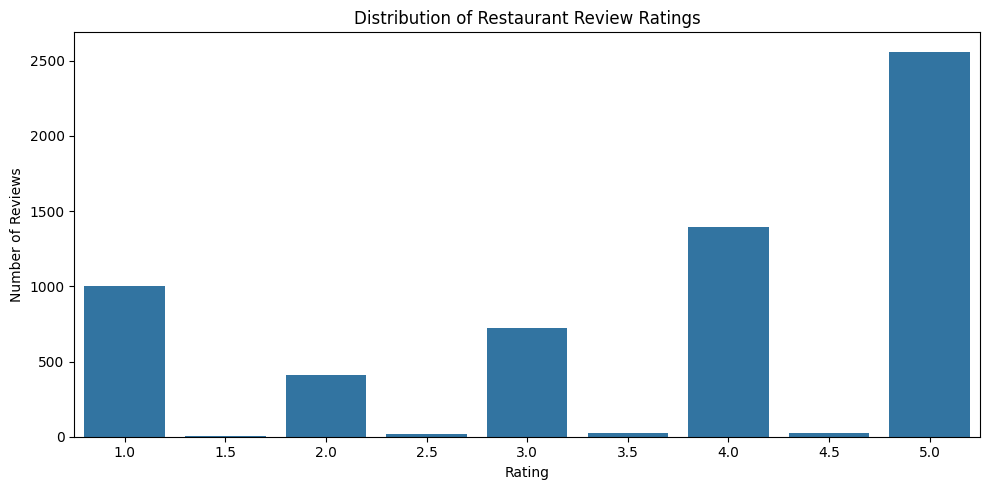

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=restaurant_df,
    x="Rating_numeric",
    order=sorted(restaurant_df["Rating_numeric"].dropna().unique())
)

plt.title("Distribution of Restaurant Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()

plt.show()

# **Exploratory data analysis**

In [ ]:
restaurant_df["review_word_count"] = (
    restaurant_df["Review_clean"]
    .fillna("")
    .str.split()
    .str.len()
)

restaurant_df["review_char_count"] = (
    restaurant_df["Review_clean"]
    .fillna("")
    .str.len()
)

display(
    restaurant_df[
        ["Review_clean", "review_word_count", "review_char_count"]
    ].head(10)
)

,Review_clean,review_word_count,review_char_count
0,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective . Good place for a sate brunch. One can also chill with friends and or parents. Waiter Soumen Das was rea...",41,222
1,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,27,144
2,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.,31,189
3,"Soumen das and Arun was a great guy. Only because of their behavior and sincerety, And good food off course, I would like to visit this place again.",28,148
4,Food is good.we ordered Kodi drumsticks and basket mutton biryani. All are good. Thanks to Pradeep. He served well. We enjoyed here. Ambience is also very good.,27,160
5,"Ambiance is good, service is good, food is aPradeecp and subro best service Food is good. Papiya good hostess and ur caption very good. This is 4star restaurant.",28,161
6,"Its a very nice place, ambience is different, all the food we ordered was very tasty, service is also gud, worth visit. Its reasonable as well. Really a must visit place.",31,170
7,Well after reading so many reviews finally visited this place...ambience was so good and coming to food crispy corn is nice. Tawa fish was ok... Basket Biryani disappointed us... biryani was ok bu...,47,288
8,"Excellent food , specially if you like spicy food . Courteous staff . Shubro and pradeep and papiya gave excellent service to our corporate team dinner . Overall great for team dinners and party",34,194
9,"Came for the birthday treat of a close friend. Perfect place for a treat like this. Very hospitable and cooperative staff. Food was delicious, ambience was really good with the music and the light...",53,295


In [ ]:
review_length_stats = restaurant_df[
    "review_word_count"
].describe()

display(review_length_stats)

,review_word_count
count,6162.000000
mean,51.383966
std,64.581732
min,0.000000
25%,25.000000
50%,34.000000
75%,58.000000
max,964.000000


In [ ]:
short_review_summary = pd.DataFrame({
    "Threshold": [
        "1 word",
        "2 words or fewer",
        "3 words or fewer",
        "5 words or fewer",
        "10 words or fewer"
    ],
    "Count": [
        (restaurant_df["review_word_count"] == 1).sum(),
        (restaurant_df["review_word_count"] <= 2).sum(),
        (restaurant_df["review_word_count"] <= 3).sum(),
        (restaurant_df["review_word_count"] <= 5).sum(),
        (restaurant_df["review_word_count"] <= 10).sum()
    ]
})

short_review_summary["Percentage"] = (
    short_review_summary["Count"]
    / len(restaurant_df)
    * 100
).round(2)

display(short_review_summary)

,Threshold,Count,Percentage
0,1 word,314,5.10
1,2 words or fewer,543,8.81
2,3 words or fewer,673,10.92
3,5 words or fewer,827,13.42
4,10 words or fewer,1033,16.76


In [ ]:
shortest_reviews = (
    restaurant_df[
        restaurant_df["Review_clean"].notna()
    ]
    .sort_values("review_word_count")
    [["Restaurant", "Review_clean", "Rating_numeric", "review_word_count"]]
)

display(shortest_reviews.head(30))

,Restaurant,Review_clean,Rating_numeric,review_word_count
3588,Green Bawarchi Restaurant,good,5.0,1
9894,Triptify,good,5.0,1
9876,Triptify,good,5.0,1
9879,Triptify,good,5.0,1
9880,Triptify,v.good,5.0,1
6274,Shree Santosh Dhaba Family Restaurant,.,5.0,1
6278,Shree Santosh Dhaba Family Restaurant,excellent,5.0,1
6249,Shree Santosh Dhaba Family Restaurant,okay,5.0,1
6251,Shree Santosh Dhaba Family Restaurant,gud,5.0,1
6253,Shree Santosh Dhaba Family Restaurant,good,5.0,1


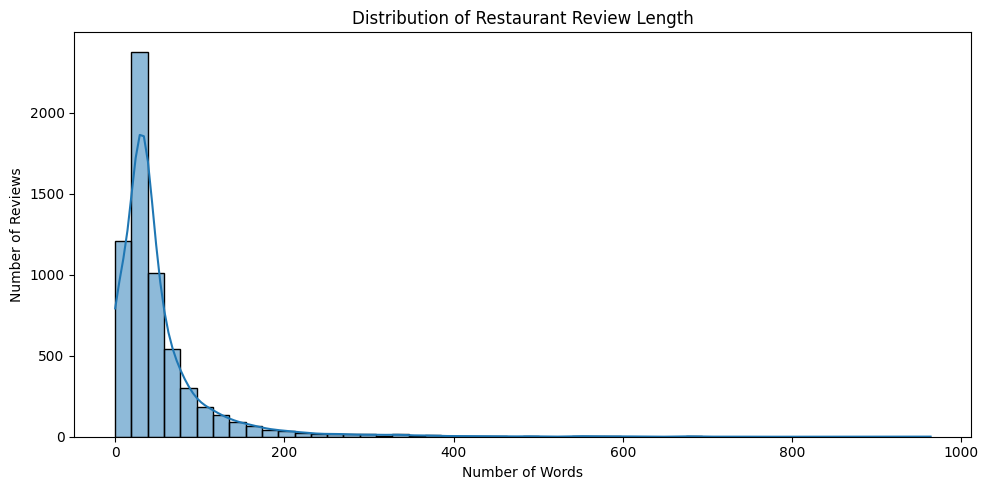

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=restaurant_df,
    x="review_word_count",
    bins=50,
    kde=True
)

plt.title("Distribution of Restaurant Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.tight_layout()

plt.show()

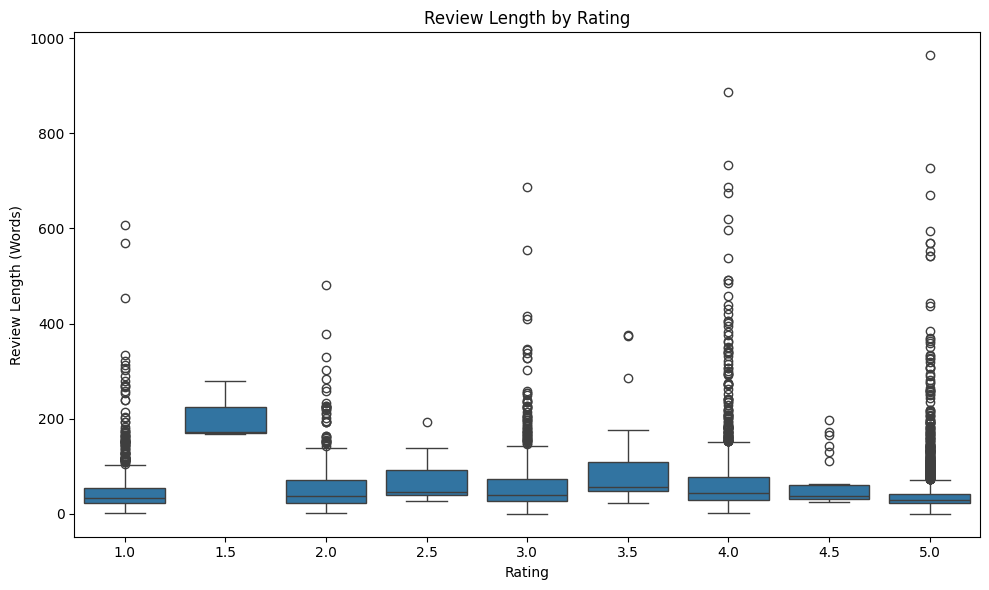

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=restaurant_df,
    x="Rating_numeric",
    y="review_word_count"
)

plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (Words)")
plt.tight_layout()

plt.show()

## Restaurant level analysis

In [ ]:
restaurant_stats = (
    restaurant_df
    .groupby("Restaurant")["Rating_numeric"]
    .agg(
        Review_Count="count",
        Mean_Rating="mean",
        Median_Rating="median",
        Std_Rating="std",
        Minimum_Rating="min",
        Maximum_Rating="max"
    )
    .reset_index()
)

restaurant_stats = restaurant_stats.sort_values(
    "Mean_Rating",
    ascending=False
)

display(restaurant_stats)

,Restaurant,Review_Count,Mean_Rating,Median_Rating,Std_Rating,Minimum_Rating,Maximum_Rating
2,AB's - Absolute Barbecues,100,4.88,5.0,0.498077,2.0,5.0
8,B-Dubs,100,4.81,5.0,0.614554,1.0,5.0
1,"3B's - Buddies, Bar & Barbecue",100,4.76,5.0,0.830237,1.0,5.0
43,Paradise,100,4.70,5.0,0.771984,1.0,5.0
22,Flechazo,100,4.66,5.0,0.878704,1.0,5.0
...,...,...,...,...,...,...,...
17,Desi Bytes,100,2.90,3.0,1.623688,1.0,5.0
49,Shree Santosh Dhaba Family Restaurant,100,2.83,3.0,1.645655,1.0,5.0
37,Mathura Vilas,100,2.82,3.0,1.546452,1.0,5.0
42,Pakwaan Grand,100,2.71,3.0,1.506183,1.0,5.0


In [ ]:
print("Top 10 restaurants by mean rating:")
display(
    restaurant_stats[
        ["Restaurant", "Review_Count", "Mean_Rating"]
    ].head(10)
)

print("\nBottom 10 restaurants by mean rating:")
display(
    restaurant_stats[
        ["Restaurant", "Review_Count", "Mean_Rating"]
    ].tail(10)
)

Top 10 restaurants by mean rating:


,Restaurant,Review_Count,Mean_Rating
2,AB's - Absolute Barbecues,100,4.88
8,B-Dubs,100,4.81
1,"3B's - Buddies, Bar & Barbecue",100,4.76
43,Paradise,100,4.70
22,Flechazo,100,4.66
55,The Indi Grill,100,4.60
60,Zega - Sheraton Hyderabad Hotel,100,4.45
11,Beyond Flavours,100,4.28
12,Cascade - Radisson Hyderabad Hitec City,100,4.26
21,Feast - Sheraton Hyderabad Hotel,100,4.22



Bottom 10 restaurants by mean rating:


,Restaurant,Review_Count,Mean_Rating
50,T Grill,100,3.170
4,Al Saba Restaurant,100,3.155
48,Shanghai Chef 2,100,3.060
27,Hitech Bawarchi Food Zone,100,3.050
15,Delhi-39,100,2.975
17,Desi Bytes,100,2.900
49,Shree Santosh Dhaba Family Restaurant,100,2.830
37,Mathura Vilas,100,2.820
42,Pakwaan Grand,100,2.710
28,Hotel Zara Hi-Fi,100,2.400


In [ ]:
highest_variability = restaurant_stats.sort_values(
    "Std_Rating",
    ascending=False
)

print("Restaurants with highest rating variability:")
display(
    highest_variability[
        ["Restaurant", "Review_Count", "Mean_Rating", "Std_Rating"]
    ].head(10)
)

Restaurants with highest rating variability:


,Restaurant,Review_Count,Mean_Rating,Std_Rating
27,Hitech Bawarchi Food Zone,100,3.050,1.760251
28,Hotel Zara Hi-Fi,100,2.400,1.734964
46,Royal Spicy Restaurant,100,3.740,1.679466
41,Owm Nom Nom,100,3.290,1.677510
26,Green Bawarchi Restaurant,100,3.490,1.654471
35,Kritunga Restaurant,100,3.470,1.654226
49,Shree Santosh Dhaba Family Restaurant,100,2.830,1.645655
17,Desi Bytes,100,2.900,1.623688
15,Delhi-39,100,2.975,1.605507
47,Shah Ghouse Hotel & Restaurant,100,3.210,1.603626


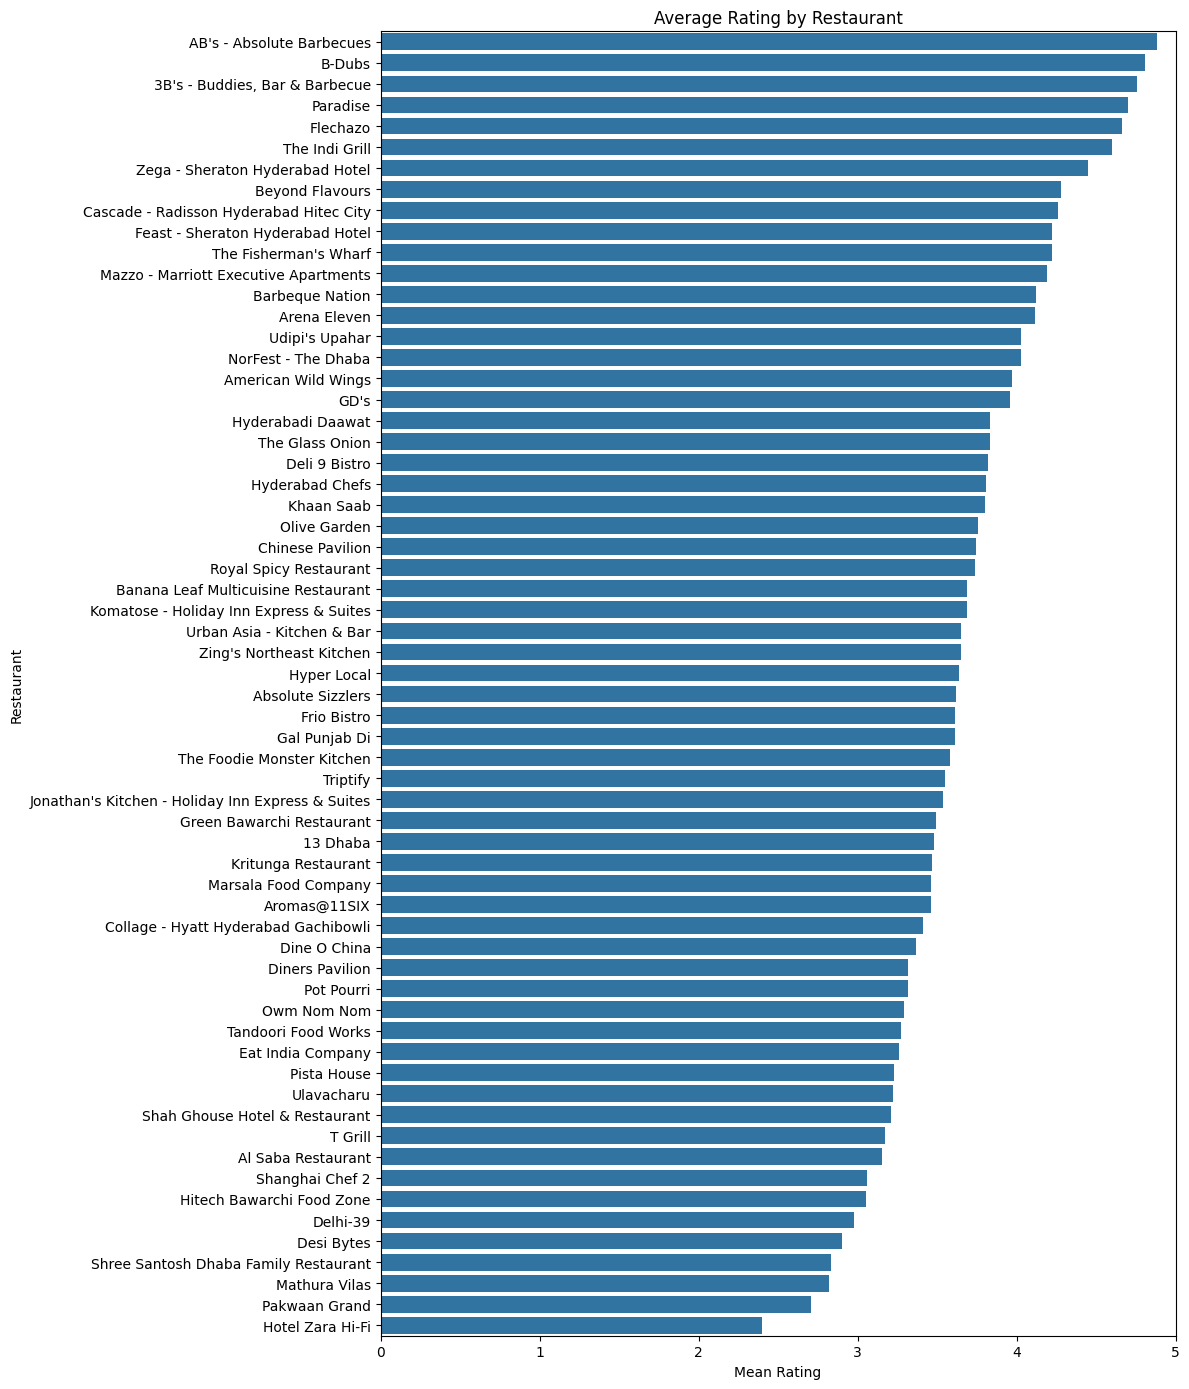

In [ ]:
plt.figure(figsize=(12, 14))

sns.barplot(
    data=restaurant_stats,
    y="Restaurant",
    x="Mean_Rating"
)

plt.title("Average Rating by Restaurant")
plt.xlabel("Mean Rating")
plt.ylabel("Restaurant")
plt.xlim(0, 5)
plt.tight_layout()

plt.show()

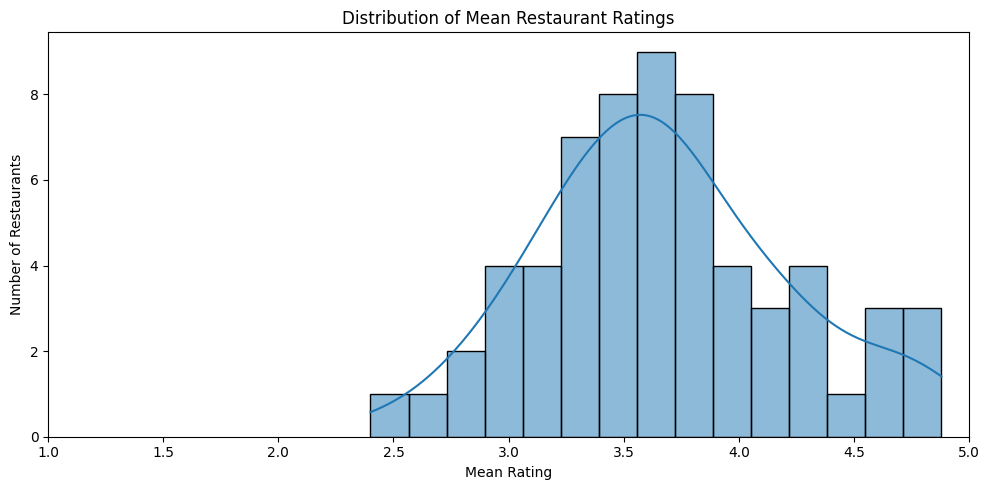

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    restaurant_stats["Mean_Rating"],
    bins=15,
    kde=True
)

plt.title("Distribution of Mean Restaurant Ratings")
plt.xlabel("Mean Rating")
plt.ylabel("Number of Restaurants")
plt.xlim(1, 5)

plt.tight_layout()
plt.show()

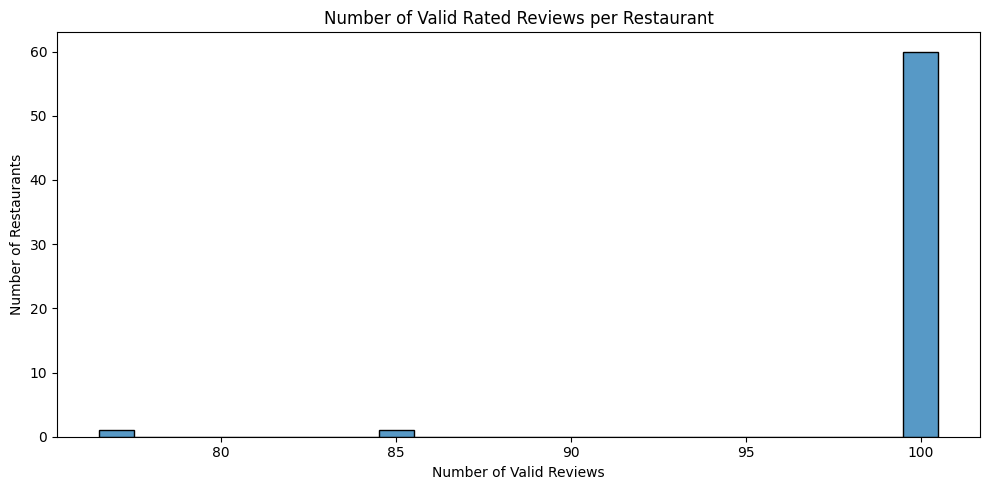

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(
    restaurant_stats["Review_Count"],
    bins=10,
    discrete=True
)

plt.title("Number of Valid Rated Reviews per Restaurant")
plt.xlabel("Number of Valid Reviews")
plt.ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

In [ ]:
rating_by_restaurant = pd.crosstab(
    restaurant_df["Restaurant"],
    restaurant_df["Rating_numeric"]
)

display(rating_by_restaurant.head(10))

Rating_numeric,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
Restaurant,,,,,,,,,
13 Dhaba,22,0,7,0,8,0,27,0,36
"3B's - Buddies, Bar & Barbecue",2,0,4,0,1,0,2,0,91
AB's - Absolute Barbecues,0,0,2,0,1,0,4,0,93
Absolute Sizzlers,20,0,7,0,9,0,19,0,45
Al Saba Restaurant,24,0,5,4,20,4,17,1,25
American Wild Wings,10,0,4,0,6,0,15,0,42
Arena Eleven,5,0,4,0,10,0,23,0,43
Aromas@11SIX,19,0,9,0,17,0,17,0,38
B-Dubs,1,0,1,0,2,0,8,0,88


In [ ]:
length_by_rating = (
    restaurant_df
    .groupby("Rating_numeric")["review_word_count"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .reset_index()
)

display(length_by_rating)

,Rating_numeric,Count,Mean,Median,Minimum,Maximum
0,1.0,1003,47.091725,33.0,1,608
1,1.5,3,206.333333,171.0,168,280
2,2.0,412,56.475728,37.0,1,480
3,2.5,15,70.133333,46.0,27,192
4,3.0,724,60.055249,40.0,0,687
5,3.5,23,103.913043,56.0,22,376
6,4.0,1396,67.597421,43.0,1,886
7,4.5,26,62.923077,37.0,25,198
8,5.0,2560,40.071875,29.0,0,964


In [ ]:
short_review_by_rating = (
    restaurant_df
    .assign(
        is_short=restaurant_df["review_word_count"] <= 10
    )
    .groupby("Rating_numeric")["is_short"]
    .agg(
        Total_Reviews="count",
        Short_Reviews="sum",
        Short_Review_Percentage="mean"
    )
    .reset_index()
)

short_review_by_rating["Short_Review_Percentage"] *= 100

display(short_review_by_rating.round(2))

,Rating_numeric,Total_Reviews,Short_Reviews,Short_Review_Percentage
0,1.0,1003,168,16.75
1,1.5,3,0,0.00
2,2.0,412,69,16.75
3,2.5,15,0,0.00
4,3.0,724,108,14.92
5,3.5,23,0,0.00
6,4.0,1396,121,8.67
7,4.5,26,0,0.00
8,5.0,2560,567,22.15


In [ ]:
restaurant_df["review_length_category"] = pd.cut(
    restaurant_df["review_word_count"],
    bins=[-1, 5, 10, 25, 50, 100, float("inf")],
    labels=[
        "1–5 words",
        "6–10 words",
        "11–25 words",
        "26–50 words",
        "51–100 words",
        "100+ words"
    ]
)

length_category_stats = (
    restaurant_df
    .groupby("review_length_category", observed=False)["Rating_numeric"]
    .agg(
        Review_Count="count",
        Mean_Rating="mean"
    )
    .reset_index()
)

display(length_category_stats.round(2))

,review_length_category,Review_Count,Mean_Rating
0,1–5 words,827,4.09
1,6–10 words,206,2.76
2,11–25 words,653,3.64
3,26–50 words,2666,3.76
4,51–100 words,1127,3.44
5,100+ words,683,3.49


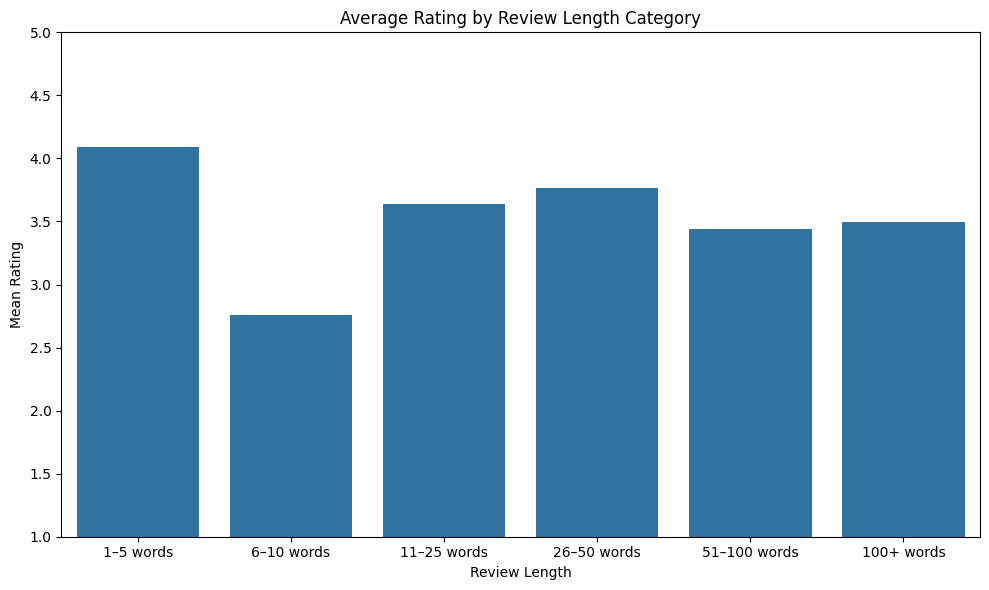

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=length_category_stats,
    x="review_length_category",
    y="Mean_Rating"
)

plt.title("Average Rating by Review Length Category")
plt.xlabel("Review Length")
plt.ylabel("Mean Rating")
plt.ylim(1, 5)

plt.tight_layout()
plt.show()

In [ ]:
short_reviews = (
    restaurant_df[
        restaurant_df["review_word_count"] <= 3
    ][
        ["Restaurant", "Review_clean", "Rating_numeric", "review_word_count"]
    ]
    .sort_values(["Rating_numeric", "review_word_count"])
)

display(short_reviews.head(50))

,Restaurant,Review_clean,Rating_numeric,review_word_count
3568,Green Bawarchi Restaurant,bad,1.0,1
3798,Kritunga Restaurant,bad,1.0,1
4888,Udipi's Upahar,Worst,1.0,1
6360,Dine O China,poor,1.0,1
6498,Hyderabad Chefs,cheated,1.0,1
7565,Royal Spicy Restaurant,waste,1.0,1
8077,Tandoori Food Works,weast,1.0,1
8281,Al Saba Restaurant,d,1.0,1
9528,Desi Bytes,1,1.0,1
9597,Desi Bytes,...,1.0,1


# End of data engineering part
# Gangarpanam krishnarpanam
# Na part aypoyindi migilindi meru cheyandi


# Machine Learning part

# NLP

In [ ]:
ml_df = restaurant_df[
    restaurant_df["Review_clean"].notna()
].copy()

print("Records available for NLP:", len(ml_df))
print("Restaurants represented:", ml_df["Restaurant"].nunique())

Records available for NLP: 6158
Restaurants represented: 62


In [ ]:
print(
    "Missing ratings in ML dataset:",
    ml_df["Rating_numeric"].isna().sum()
)

print(
    "Minimum rating:",
    ml_df["Rating_numeric"].min()
)

print(
    "Maximum rating:",
    ml_df["Rating_numeric"].max()
)

Missing ratings in ML dataset: 0
Minimum rating: 1.0
Maximum rating: 5.0


In [ ]:
ml_df["rating_class_5"] = np.floor(
    ml_df["Rating_numeric"] + 0.5
).astype(int)

print("5-class target distribution:")
display(
    ml_df["rating_class_5"]
    .value_counts()
    .sort_index()
)

5-class target distribution:


,count
rating_class_5,
1,1003
2,415
3,738
4,1419
5,2583


In [ ]:
rating_mapping = (
    ml_df[
        ["Rating_numeric", "rating_class_5"]
    ]
    .drop_duplicates()
    .sort_values("Rating_numeric")
)

display(rating_mapping)

,Rating_numeric,rating_class_5
14,1.0,1
9298,1.5,2
75,2.0,2
1188,2.5,3
30,3.0,3
6574,3.5,4
7,4.0,4
1151,4.5,5
0,5.0,5


In [ ]:
def create_sentiment_class(rating):
    if rating <= 2.0:
        return "Negative"
    elif rating <= 3.0:
        return "Neutral"
    else:
        return "Positive"


ml_df["sentiment_class"] = (
    ml_df["Rating_numeric"]
    .apply(create_sentiment_class)
)

sentiment_distribution = (
    ml_df["sentiment_class"]
    .value_counts()
    .reindex(["Negative", "Neutral", "Positive"])
)

print("3-class sentiment distribution:")
display(sentiment_distribution)

3-class sentiment distribution:


,count
sentiment_class,
Negative,1418
Neutral,738
Positive,4002


In [ ]:
ml_df["rating_target"] = ml_df["Rating_numeric"]

print(
    "Regression target range:",
    ml_df["rating_target"].min(),
    "to",
    ml_df["rating_target"].max()
)

Regression target range: 1.0 to 5.0


In [ ]:
sentiment_summary = pd.DataFrame({
    "Count": sentiment_distribution,
    "Percentage": (
        sentiment_distribution
        / len(ml_df)
        * 100
    ).round(2)
})

display(sentiment_summary)

,Count,Percentage
sentiment_class,,
Negative,1418,23.03
Neutral,738,11.98
Positive,4002,64.99


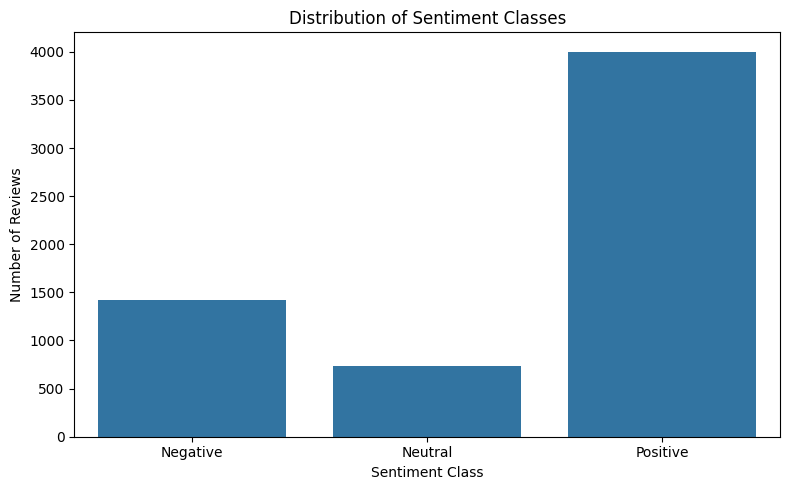

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=ml_df,
    x="sentiment_class",
    order=["Negative", "Neutral", "Positive"]
)

plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")
plt.tight_layout()

plt.show()

In [ ]:
ml_df["rating_target"] = ml_df["Rating_numeric"].astype(float)

print("Regression target:")
print(
    f"Minimum: {ml_df['rating_target'].min():.1f}"
)
print(
    f"Maximum: {ml_df['rating_target'].max():.1f}"
)

Regression target:
Minimum: 1.0
Maximum: 5.0


In [ ]:
restaurant_sentiment_profile = pd.crosstab(
    ml_df["Restaurant"],
    ml_df["sentiment_class"],
    normalize="index"
) * 100

restaurant_sentiment_profile = (
    restaurant_sentiment_profile
    .reindex(columns=["Negative", "Neutral", "Positive"], fill_value=0)
)

display(
    restaurant_sentiment_profile.round(2)
)

sentiment_class,Negative,Neutral,Positive
Restaurant,,,
13 Dhaba,29.00,8.00,63.00
"3B's - Buddies, Bar & Barbecue",6.00,1.00,93.00
AB's - Absolute Barbecues,2.00,1.00,97.00
Absolute Sizzlers,27.00,9.00,64.00
Al Saba Restaurant,29.29,24.24,46.46
...,...,...,...
Udipi's Upahar,14.00,10.00,76.00
Ulavacharu,32.00,17.00,51.00
Urban Asia - Kitchen & Bar,19.00,16.00,65.00


In [ ]:
restaurant_dominant_class = (
    restaurant_sentiment_profile
    .idxmax(axis=1)
    .value_counts()
)

print("Restaurants by dominant sentiment class:")
display(restaurant_dominant_class)

Restaurants by dominant sentiment class:


,count
Positive,56
Negative,6


## Spliting

## 5 split-Folding

In [ ]:
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
fold_assignments = np.full(len(ml_df), -1)

for fold, (_, test_index) in enumerate(
    sgkf.split(
        ml_df["Review_clean"],
        ml_df["sentiment_class"],
        groups=ml_df["Restaurant"]
    )
):
    fold_assignments[test_index] = fold

ml_df["group_fold"] = fold_assignments

print("Fold assignment complete.")
print(ml_df["group_fold"].value_counts().sort_index())

Fold assignment complete.
group_fold
0    1184
1    1277
2    1297
3    1200
4    1200
Name: count, dtype: int64


In [ ]:
restaurant_fold_counts = (
    ml_df.groupby("Restaurant")["group_fold"]
    .nunique()
)

print(
    "Restaurants appearing in more than one fold:",
    (restaurant_fold_counts > 1).sum()
)

Restaurants appearing in more than one fold: 0


In [ ]:
fold_review_counts = (
    ml_df["group_fold"]
    .value_counts()
    .sort_index()
)

print("Reviews per fold:")
display(fold_review_counts)

Reviews per fold:


,count
group_fold,
0,1184
1,1277
2,1297
3,1200
4,1200


In [ ]:
fold_sentiment_distribution = pd.crosstab(
    ml_df["group_fold"],
    ml_df["sentiment_class"],
    normalize="index"
) * 100

fold_sentiment_distribution = (
    fold_sentiment_distribution
    .reindex(
        columns=["Negative", "Neutral", "Positive"],
        fill_value=0
    )
)

print("Sentiment percentages by fold:")
display(fold_sentiment_distribution.round(2))

Sentiment percentages by fold:


sentiment_class,Negative,Neutral,Positive
group_fold,,,
0,20.35,13.26,66.39
1,22.24,13.39,64.37
2,28.53,12.95,58.52
3,19.50,9.42,71.08
4,24.08,10.75,65.17


In [ ]:
fold_restaurant_counts = (
    ml_df.groupby("group_fold")["Restaurant"]
    .nunique()
)

print("Restaurants per fold:")
display(fold_restaurant_counts)

Restaurants per fold:


,Restaurant
group_fold,
0,12
1,13
2,13
3,12
4,12


## Dividing Train,test,validation datasets

In [ ]:
train_folds = [0, 2, 3]
validation_fold = 1
test_fold = 4

train_df = ml_df[
    ml_df["group_fold"].isin(train_folds)
].copy()

validation_df = ml_df[
    ml_df["group_fold"] == validation_fold
].copy()

test_df = ml_df[
    ml_df["group_fold"] == test_fold
].copy()

print("Training records:", len(train_df))
print("Validation records:", len(validation_df))
print("Test records:", len(test_df))
print("Training restaurants:", train_df["Restaurant"].nunique())
print("Validation restaurants:", validation_df["Restaurant"].nunique())
print("Test restaurants:", test_df["Restaurant"].nunique())

Training records: 3681
Validation records: 1277
Test records: 1200
Training restaurants: 37
Validation restaurants: 13
Test restaurants: 12


In [ ]:
train_restaurants = set(train_df["Restaurant"])
validation_restaurants = set(validation_df["Restaurant"])
test_restaurants = set(test_df["Restaurant"])

print(
    "Train ∩ Validation:",
    len(train_restaurants & validation_restaurants)
)

print(
    "Train ∩ Test:",
    len(train_restaurants & test_restaurants)
)

print(
    "Validation ∩ Test:",
    len(validation_restaurants & test_restaurants)
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [ ]:
def sentiment_distribution(data):
    return (
        data["sentiment_class"]
        .value_counts(normalize=True)
        .reindex(["Negative", "Neutral", "Positive"])
        .mul(100)
        .round(2)
    )

split_sentiment = pd.DataFrame({
    "Train": sentiment_distribution(train_df),
    "Validation": sentiment_distribution(validation_df),
    "Test": sentiment_distribution(test_df)
})

display(split_sentiment)

,Train,Validation,Test
sentiment_class,,,
Negative,22.96,22.24,24.08
Neutral,11.90,13.39,10.75
Positive,65.15,64.37,65.17


In [ ]:
split_summary = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Reviews": [
        len(train_df),
        len(validation_df),
        len(test_df)
    ],
    "Restaurants": [
        train_df["Restaurant"].nunique(),
        validation_df["Restaurant"].nunique(),
        test_df["Restaurant"].nunique()
    ]
})

split_summary["Percentage_of_reviews"] = (
    split_summary["Reviews"]
    / len(ml_df)
    * 100
).round(2)

display(split_summary)

,Dataset,Reviews,Restaurants,Percentage_of_reviews
0,Train,3681,37,59.78
1,Validation,1277,13,20.74
2,Test,1200,12,19.49


In [ ]:
total_split_records = (
    len(train_df)
    + len(validation_df)
    + len(test_df)
)

print("Original ML records:", len(ml_df))
print("Records across all splits:", total_split_records)
print(
    "Difference:",
    len(ml_df) - total_split_records
)

Original ML records: 6158
Records across all splits: 6158
Difference: 0


In [ ]:
train_texts = set(train_df["Review_clean"])
validation_texts = set(validation_df["Review_clean"])
test_texts = set(test_df["Review_clean"])

print(
    "Exact review texts shared by Train and Validation:",
    len(train_texts & validation_texts)
)

print(
    "Exact review texts shared by Train and Test:",
    len(train_texts & test_texts)
)

print(
    "Exact review texts shared by Validation and Test:",
    len(validation_texts & test_texts)
)

Exact review texts shared by Train and Validation: 22
Exact review texts shared by Train and Test: 28
Exact review texts shared by Validation and Test: 10


In [ ]:
train_df.to_csv("restaurant_train.csv", index=False)
validation_df.to_csv("restaurant_validation.csv", index=False)
test_df.to_csv("restaurant_test.csv", index=False)

print("Train, validation, and test datasets saved successfully.")

Train, validation, and test datasets saved successfully.


# Training the model

## Importing ml libraries

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
X_train_text = train_df["Review_clean"]
y_train = train_df["sentiment_class"]

X_val_text = validation_df["Review_clean"]
y_val = validation_df["sentiment_class"]

X_test_text = test_df["Review_clean"]
y_test = test_df["sentiment_class"]

print("Training reviews:", len(X_train_text))
print("Validation reviews:", len(X_val_text))
print("Test reviews:", len(X_test_text))

Training reviews: 3681
Validation reviews: 1277
Test reviews: 1200


In [ ]:
majority_class = y_train.mode()[0]

majority_predictions = np.full(
    len(y_test),
    majority_class
)

majority_accuracy = accuracy_score(
    y_test,
    majority_predictions
)

majority_balanced_accuracy = balanced_accuracy_score(
    y_test,
    majority_predictions
)

majority_f1 = precision_recall_fscore_support(
    y_test,
    majority_predictions,
    average="macro",
    zero_division=0
)[2]

print("Majority class:", majority_class)
print(f"Accuracy: {majority_accuracy:.4f}")
print(f"Balanced Accuracy: {majority_balanced_accuracy:.4f}")
print(f"Macro-F1: {majority_f1:.4f}")

Majority class: Positive
Accuracy: 0.6517
Balanced Accuracy: 0.3333
Macro-F1: 0.2630


In [ ]:
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [ ]:
X_train_tfidf = tfidf.fit_transform(X_train_text)

X_val_tfidf = tfidf.transform(X_val_text)

X_test_tfidf = tfidf.transform(X_test_text)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (3681, 22603)
Validation TF-IDF shape: (1277, 22603)
Test TF-IDF shape: (1200, 22603)


In [ ]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [ ]:
logistic_val_predictions = logistic_model.predict(
    X_val_tfidf
)

logistic_val_accuracy = accuracy_score(
    y_val,
    logistic_val_predictions
)

logistic_val_balanced_accuracy = balanced_accuracy_score(
    y_val,
    logistic_val_predictions
)

logistic_val_precision, logistic_val_recall, logistic_val_f1, _ = (
    precision_recall_fscore_support(
        y_val,
        logistic_val_predictions,
        average="macro",
        zero_division=0
    )
)

print("Logistic Regression — Validation")
print(f"Accuracy: {logistic_val_accuracy:.4f}")
print(f"Balanced Accuracy: {logistic_val_balanced_accuracy:.4f}")
print(f"Macro Precision: {logistic_val_precision:.4f}")
print(f"Macro Recall: {logistic_val_recall:.4f}")
print(f"Macro-F1: {logistic_val_f1:.4f}")

Logistic Regression — Validation
Accuracy: 0.8363
Balanced Accuracy: 0.7602
Macro Precision: 0.7401
Macro Recall: 0.7602
Macro-F1: 0.7492


In [ ]:
print(
    classification_report(
        y_val,
        logistic_val_predictions,
        labels=["Negative", "Neutral", "Positive"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Negative       0.77      0.86      0.81       284
     Neutral       0.51      0.53      0.52       171
    Positive       0.94      0.89      0.91       822

    accuracy                           0.84      1277
   macro avg       0.74      0.76      0.75      1277
weighted avg       0.84      0.84      0.84      1277



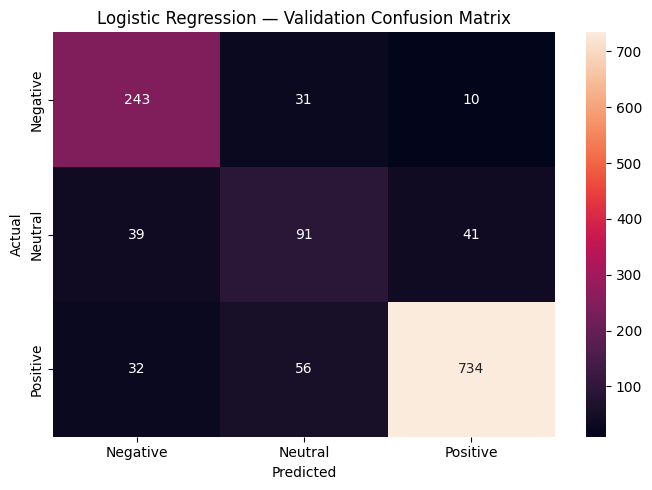

In [ ]:
logistic_cm = confusion_matrix(
    y_val,
    logistic_val_predictions,
    labels=["Negative", "Neutral", "Positive"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Logistic Regression — Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("Linear SVM training completed.")


Linear SVM training completed.


In [ ]:
svm_val_predictions = svm_model.predict(
    X_val_tfidf
)

svm_val_accuracy = accuracy_score(
    y_val,
    svm_val_predictions
)

svm_val_balanced_accuracy = balanced_accuracy_score(
    y_val,
    svm_val_predictions
)

svm_val_precision, svm_val_recall, svm_val_f1, _ = (
    precision_recall_fscore_support(
        y_val,
        svm_val_predictions,
        average="macro",
        zero_division=0
    )
)

print("Linear SVM — Validation")
print(f"Accuracy: {svm_val_accuracy:.4f}")
print(f"Balanced Accuracy: {svm_val_balanced_accuracy:.4f}")
print(f"Macro Precision: {svm_val_precision:.4f}")
print(f"Macro Recall: {svm_val_recall:.4f}")
print(f"Macro-F1: {svm_val_f1:.4f}")

Linear SVM — Validation
Accuracy: 0.8309
Balanced Accuracy: 0.7018
Macro Precision: 0.7215
Macro Recall: 0.7018
Macro-F1: 0.7045


In [ ]:
model_comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "TF-IDF + Logistic Regression",
        "TF-IDF + Linear SVM"
    ],
    "Accuracy": [
        majority_accuracy,
        logistic_val_accuracy,
        svm_val_accuracy
    ],
    "Balanced Accuracy": [
        majority_balanced_accuracy,
        logistic_val_balanced_accuracy,
        svm_val_balanced_accuracy
    ],
    "Macro-F1": [
        majority_f1,
        logistic_val_f1,
        svm_val_f1
    ]
})

display(
    model_comparison.sort_values(
        "Macro-F1",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Balanced Accuracy,Macro-F1
0,TF-IDF + Logistic Regression,0.836335,0.760247,0.749234
1,TF-IDF + Linear SVM,0.830854,0.701824,0.704530
2,Majority Baseline,0.651667,0.333333,0.263034


# Controlled hyperparameter experiment

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

def evaluate_model(model, X_val, y_val):
    predictions = model.predict(X_val)

    return {
        "Accuracy": accuracy_score(y_val, predictions),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_val,
            predictions
        ),
        "Macro_F1": f1_score(
            y_val,
            predictions,
            average="macro"
        ),
        "Neutral_F1": f1_score(
            y_val,
            predictions,
            labels=["Neutral"],
            average="macro"
        )
    }

In [ ]:
experiments = [
    {
        "name": "TF-IDF (1,1) + LR C=1",
        "ngram_range": (1, 1),
        "min_df": 2,
        "max_df": 0.95,
        "C": 1.0
    },
    {
        "name": "TF-IDF (1,2) + LR C=0.5",
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95,
        "C": 0.5
    },
    {
        "name": "TF-IDF (1,2) + LR C=1",
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95,
        "C": 1.0
    },
    {
        "name": "TF-IDF (1,2) + LR C=2",
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95,
        "C": 2.0
    },
    {
        "name": "TF-IDF (1,2) + LR C=5",
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95,
        "C": 5.0
    }
]

In [ ]:
results = []

for experiment in experiments:

    vectorizer = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=experiment["ngram_range"],
        min_df=experiment["min_df"],
        max_df=experiment["max_df"],
        sublinear_tf=True
    )

    X_train_exp = vectorizer.fit_transform(X_train_text)
    X_val_exp = vectorizer.transform(X_val_text)

    model = LogisticRegression(
        C=experiment["C"],
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_exp, y_train)

    metrics = evaluate_model(
        model,
        X_val_exp,
        y_val
    )

    results.append({
        "Model": experiment["name"],
        **metrics,
        "Features": X_train_exp.shape[1]
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "Macro_F1",
        ascending=False
    ).reset_index(drop=True)
)

,Model,Accuracy,Balanced_Accuracy,Macro_F1,Neutral_F1,Features
0,"TF-IDF (1,2) + LR C=1",0.836335,0.760247,0.749234,0.521490,22603
1,"TF-IDF (1,2) + LR C=0.5",0.828504,0.763918,0.747024,0.531507,22603
2,"TF-IDF (1,2) + LR C=2",0.837118,0.750614,0.744245,0.502994,22603
3,"TF-IDF (1,1) + LR C=1",0.808144,0.751093,0.728353,0.506329,4512
4,"TF-IDF (1,2) + LR C=5",0.830854,0.728084,0.725955,0.456250,22603


In [ ]:
best_model_name = (
    results_df
    .sort_values("Macro_F1", ascending=False)
    .iloc[0]["Model"]
)

print("Best validation configuration:")
print(best_model_name)

Best validation configuration:
TF-IDF (1,2) + LR C=1


# Error Analysis

In [ ]:
best_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_best = best_vectorizer.fit_transform(X_train_text)
X_val_best = best_vectorizer.transform(X_val_text)

best_logistic_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

best_logistic_model.fit(
    X_train_best,
    y_train
)

best_val_predictions = best_logistic_model.predict(
    X_val_best
)

print("Selected model retrained successfully.")

Selected model retrained successfully.


In [ ]:
validation_results = validation_df[
    ["Restaurant", "Review_clean", "Rating_numeric", "sentiment_class"]
].copy()

validation_results["Predicted_Sentiment"] = best_val_predictions

display(validation_results.head(10))

,Restaurant,Review_clean,Rating_numeric,sentiment_class,Predicted_Sentiment
800,Hyper Local,"Man this place. Hyperlocal is one of the go to places when you have no plans but wanna go to some place to chill, eat and drink. The food is served in matte black plates which is my favourite part...",4.0,Positive,Positive
801,Hyper Local,Best place to be to hangout with your loved ones 👌🙌🏻 ambience and taste of food... one no need to comprise on that.. friendly staff.. staff sandip very humble and understands your taste.. worth be...,5.0,Positive,Positive
802,Hyper Local,"The fisrt time i came here, fell in love with the ambience. The food is good and priced nominally. Sandeep was so helpful in choosing the right choice of food & drinks",5.0,Positive,Positive
803,Hyper Local,"My peace of advice pls don't waste your money. Over pricy, but buffet spread has very less items. Very much disappointed and the food was not even hot",1.0,Negative,Negative
804,Hyper Local,Had visited for lunch buffet.to my surprise at 2 pm most of the dishes were hardly left and were not replenised.also service is slow had to wait even to pay bill inspite of the fact that it was ha...,2.0,Negative,Negative
805,Hyper Local,Food was not that great just ambience was good very very conjusted sofa area worst ac service was good but I dnt recommend this place for food,1.0,Negative,Neutral
806,Hyper Local,"Been here for my college farewell on a tuesday afternoon! Absolutely loved the ambience. In Food , starters were amazing . However, main course and desserts could be better. We booked the dance fl...",5.0,Positive,Positive
807,Hyper Local,Visited hyperlocal for the sundower party and I must say! One of the best places to party in and around kondapur. The place is huge and divided into 3 sections. Interior has 2 portions and outdoor...,4.0,Positive,Positive
808,Hyper Local,Visited this place while IPL screening. They were running couple of bucket offers on drinks and food. Ambiance is nice and you get the botanical garden view free of cost. music is too loud for me....,4.0,Positive,Positive
809,Hyper Local,Good taste of food and nice ambience.staff are really friendly@sandip.music was really good and atmosphere was energetic.its good place to njoy with friends and family,5.0,Positive,Positive


In [ ]:
misclassified = validation_results[
    validation_results["sentiment_class"]
    != validation_results["Predicted_Sentiment"]
].copy()

print("Total validation reviews:", len(validation_results))
print("Misclassified reviews:", len(misclassified))
print(
    "Validation error rate:",
    f"{len(misclassified) / len(validation_results) * 100:.2f}%"
)

Total validation reviews: 1277
Misclassified reviews: 209
Validation error rate: 16.37%


In [ ]:
neutral_errors = misclassified[
    misclassified["sentiment_class"] == "Neutral"
].copy()

print(
    "Actual Neutral reviews misclassified:",
    len(neutral_errors)
)

display(
    neutral_errors[
        [
            "Restaurant",
            "Review_clean",
            "Rating_numeric",
            "Predicted_Sentiment"
        ]
    ].head(50)
)

Actual Neutral reviews misclassified: 80


,Restaurant,Review_clean,Rating_numeric,Predicted_Sentiment
814,Hyper Local,"One line #Only4chicken 😜, Ambience is good with large screen inside and nice atmosphere outside. Coming to food you will not find any item other than Chicken for Non veg and Aloo for Veg 😂. Servic...",3.0,Positive
822,Hyper Local,"I and my friend went here to watch the IPL live screening and have some good time. One good thing was that they have 2+2 on drinks through Zomato gold. The food pretty decent too, but what I didn'...",3.0,Negative
837,Hyper Local,They have worst north indian food i believe. Spoiled my birthday mood since i am punjabi and ordered north indian food. But other than that chinese and continental was good. Their safe sex on beac...,3.0,Positive
849,Hyper Local,One place to order pasta when you’re hungry in office also stomach filling with two toasted breads if your hungry want to order something quickly without scrolling down much just order it and wiat...,3.0,Negative
860,Hyper Local,They have this amazing IPL offer 600 for 4 pints & french fries Nice ambience A bit expensive otherwise The view is really good spanning the whole city,3.0,Positive
885,Hyper Local,"Visited Hyper Local for their newly launched Drunch buffet. The buffet spread is valid for weeekends and costs nearly 1200/- per person. The place itself is located in a good, open area inside SLN...",3.0,Positive
886,Hyper Local,Hyper Local is situated in one such building which has various lounges and pubs. Despite that it has a reputed name and hype. The place is widely spread evenly with three sections. Two sections on...,3.0,Positive
1616,NorFest - The Dhaba,"Well this is the first time I ordered from NorFest - The Dhaba. I ordered for mutton combo meal which contains rice, dal makhani, 2 paratha and mutton with a pocket pinch of Rs. 400. However, very...",3.0,Negative
1626,NorFest - The Dhaba,"Last time I ordered mutton rogan josh from here, it was amazing but today it was not fresh and only bones, no meat. It’s sad my favourite restaurant is going down in quality",3.0,Negative
1642,NorFest - The Dhaba,"#Heavy Punjabi Food A perfect place to savor typical Dhaba style Punjabi Dishes. A popular outlet for home delivery, however place has common food court space available for dine-in as well. Food...",3.0,Positive


In [ ]:
error_patterns = (
    misclassified
    .groupby(
        ["sentiment_class", "Predicted_Sentiment"]
    )
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
)

display(error_patterns)

,sentiment_class,Predicted_Sentiment,Count
5,Positive,Neutral,56
3,Neutral,Positive,41
2,Neutral,Negative,39
4,Positive,Negative,32
0,Negative,Neutral,31
1,Negative,Positive,10


In [ ]:
neutral_correct = validation_results[
    (validation_results["sentiment_class"] == "Neutral") &
    (validation_results["Predicted_Sentiment"] == "Neutral")
]

print(
    "Correctly classified Neutral reviews:",
    len(neutral_correct)
)

display(
    neutral_correct[
        [
            "Restaurant",
            "Review_clean",
            "Rating_numeric"
        ]
    ].head(30)
)

Correctly classified Neutral reviews: 91


,Restaurant,Review_clean,Rating_numeric
850,Hyper Local,Menu needs a major overhaul. Not for a large group of people. Not for everyone due to limited items in menu. Mocktails are damn expensive. Ambience not as good as few competitors.,3.0
852,Hyper Local,"There is a cafe named Hyper Local Cafe in Manikonda ,I don’t know if this belongs to the same one but went to this place with certain expectations but was disappointed...it has quite a good experi...",3.0
862,Hyper Local,The drunch trend has picked up in Hyderabad and Hyperlocal has joined in too. The ambience is good although the place is pretty small and a bit cramped up. The utilisation of the limited space is ...,3.0
872,Hyper Local,Its a decent place for dinner. Decors and the service is average but the food is good. And the bar is fully loaded with great drinks. And the offers are also very attractive.,3.0
889,Hyper Local,Situated at the top floor of SLN terminus along with food court area. Ambience and decor is pleasing. Buffet doesn't do justice to price paid in terms of variety and service. We had to wait for bo...,3.0
892,Hyper Local,"U will not find many veg items here. But the biryani quantity wise, it will be adequate quantity for both people. We ordered green veg gulati (not so good) and one veg biryani.",3.0
895,Hyper Local,Ambience is good but not a lot of food options are there. Tried there mocktails which could have been better and the food was okay. Increase the food and drinks options.,3.0
1603,NorFest - The Dhaba,I have ordered lucknawi chicken pulao..good amount of chicken .. delivered hot..but the food is so spicy that I was Unable to enjoy the taste,3.0
1607,NorFest - The Dhaba,"Recently went there to eat paranthas. It needs a lot of improvement. Earlier i had other non veg dishes on online order, which were good. Ambience is good.",3.0
1627,NorFest - The Dhaba,The place is located in the food court of SLN Terminus and the first branch of Norfest in the city. The seating is in the food court and the kiosk has the dhaba feel with copper vessels on the cou...,3.0


## Examine what the model has learne

In [ ]:
feature_names = best_vectorizer.get_feature_names_out()

coefficients = best_logistic_model.coef_

classes = best_logistic_model.classes_

print("Classes:")
print(classes)
print("Number of features:", len(feature_names))

Classes:
['Negative' 'Neutral' 'Positive']
Number of features: 22603


In [ ]:
for class_index, class_name in enumerate(classes):

    class_coefficients = coefficients[class_index]

    top_indices = np.argsort(
        class_coefficients
    )[-20:][::-1]

    top_features = pd.DataFrame({
        "Feature": feature_names[top_indices],
        "Coefficient": class_coefficients[top_indices]
    })

    print(f"\nTop features associated with {class_name}:")
    display(top_features)


Top features associated with Negative:


,Feature,Coefficient
0,worst,3.279705
1,not good,2.688486
2,pathetic,2.342355
3,bad,2.331404
4,not,2.317260
5,no,2.051000
6,even,1.626499
7,got,1.599966
8,is not,1.546619
9,order,1.481973



Top features associated with Neutral:


,Feature,Coefficient
0,not,2.709185
1,average,2.535757
2,okay,2.039453
3,but,1.991819
4,good but,1.888849
5,ok,1.627552
6,good,1.393707
7,was,1.340321
8,and tasty,1.278807
9,much,1.250477



Top features associated with Positive:


,Feature,Coefficient
0,awesome,2.805463
1,good,2.119833
2,best,2.075225
3,amazing,2.033333
4,must,1.958187
5,great,1.880352
6,very good,1.846619
7,love,1.832810
8,excellent,1.815631
9,delicious,1.712396


## Check whether restaurant-specific language is dominating

In [ ]:
restaurant_names_in_vocab = []

feature_set = set(feature_names)

for restaurant in ml_df["Restaurant"].unique():

    words = restaurant.lower().split()

    matched_words = [
        word for word in words
        if word in feature_set and len(word) > 2
    ]

    if matched_words:
        restaurant_names_in_vocab.append(
            (restaurant, matched_words)
        )

display(
    restaurant_names_in_vocab[:30]
)

[('Beyond Flavours', ['beyond', 'flavours']),
 ('Paradise', ['paradise']),
 ('Flechazo', ['flechazo']),
 ('Shah Ghouse Hotel & Restaurant', ['shah', 'ghouse', 'hotel', 'restaurant']),
 ("The Fisherman's Wharf", ['the', 'wharf']),
 ('Hyper Local', ['local']),
 ('Barbeque Nation', ['barbeque', 'nation']),
 ('Absolute Sizzlers', ['absolute', 'sizzlers']),
 ("AB's - Absolute Barbecues", ['absolute', 'barbecues']),
 ('NorFest - The Dhaba', ['the', 'dhaba']),
 ('Hotel Zara Hi-Fi', ['hotel']),
 ('Pakwaan Grand', ['pakwaan', 'grand']),
 ('13 Dhaba', ['dhaba']),
 ("Jonathan's Kitchen - Holiday Inn Express & Suites",
  ['kitchen', 'holiday', 'inn', 'express']),
 ("3B's - Buddies, Bar & Barbecue", ['bar', 'barbecue']),
 ('Pot Pourri', ['pot', 'pourri']),
 ('Pista House', ['pista', 'house']),
 ('Marsala Food Company', ['marsala', 'food', 'company']),
 ('Mazzo - Marriott Executive Apartments', ['executive']),
 ('Green Bawarchi Restaurant', ['green', 'bawarchi', 'restaurant']),
 ('Banana Leaf Multic

## Evaluate whether short reviews are hurting the model

In [ ]:
validation_results["Review_Length"] = (
    validation_results["Review_clean"]
    .fillna("")
    .str.split()
    .str.len()
)

validation_results["Length_Category"] = pd.cut(
    validation_results["Review_Length"],
    bins=[-1, 5, 10, 25, 50, 100, float("inf")],
    labels=[
        "1–5",
        "6–10",
        "11–25",
        "26–50",
        "51–100",
        "100+"
    ]
)

In [ ]:
length_performance = []

for category, group in validation_results.groupby(
    "Length_Category",
    observed=False
):

    accuracy = accuracy_score(
        group["sentiment_class"],
        group["Predicted_Sentiment"]
    )

    macro_f1 = f1_score(
        group["sentiment_class"],
        group["Predicted_Sentiment"],
        average="macro",
        zero_division=0
    )

    length_performance.append({
        "Review_Length": category,
        "Reviews": len(group),
        "Accuracy": accuracy,
        "Macro_F1": macro_f1
    })

length_performance_df = pd.DataFrame(
    length_performance
)

display(length_performance_df.round(3))

,Review_Length,Reviews,Accuracy,Macro_F1
0,1–5,108,0.861,0.754
1,6–10,32,0.562,0.500
2,11–25,146,0.849,0.689
3,26–50,591,0.866,0.765
4,51–100,243,0.848,0.805
5,100+,157,0.732,0.691


# Five-class rating classification

In [ ]:
ml_df["rating_class_5"] = np.floor(
    ml_df["Rating_numeric"] + 0.5
).astype(int)

print("5-class rating distribution:")
display(
    ml_df["rating_class_5"]
    .value_counts()
    .sort_index()
)


5-class rating distribution:


,count
rating_class_5,
1,1003
2,415
3,738
4,1419
5,2583


In [ ]:
rating_mapping_5class = (
    ml_df[
        ["Rating_numeric", "rating_class_5"]
    ]
    .drop_duplicates()
    .sort_values("Rating_numeric")
)

display(rating_mapping_5class)

,Rating_numeric,rating_class_5
14,1.0,1
9298,1.5,2
75,2.0,2
1188,2.5,3
30,3.0,3
6574,3.5,4
7,4.0,4
1151,4.5,5
0,5.0,5


## Add the 5-class labels to our existing splits

In [ ]:
train_df = ml_df[
    ml_df["group_fold"].isin(train_folds)
].copy()

validation_df = ml_df[
    ml_df["group_fold"] == validation_fold
].copy()

test_df = ml_df[
    ml_df["group_fold"] == test_fold
].copy()

print("Train:", len(train_df))
print("Validation:", len(validation_df))
print("Test:", len(test_df))

Train: 3681
Validation: 1277
Test: 1200


In [ ]:
X_train_rating = train_df["Review_clean"]
y_train_rating = train_df["rating_class_5"]

X_val_rating = validation_df["Review_clean"]
y_val_rating = validation_df["rating_class_5"]

rating_tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_rating_tfidf = rating_tfidf.fit_transform(
    X_train_rating
)

X_val_rating_tfidf = rating_tfidf.transform(
    X_val_rating
)

rating_logistic_model = LogisticRegression(
    C=1.0,
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

rating_logistic_model.fit(
    X_train_rating_tfidf,
    y_train_rating
)

rating_val_predictions = rating_logistic_model.predict(
    X_val_rating_tfidf
)

print("5-class rating model trained.")

5-class rating model trained.


In [ ]:
rating_accuracy = accuracy_score(
    y_val_rating,
    rating_val_predictions
)

rating_balanced_accuracy = balanced_accuracy_score(
    y_val_rating,
    rating_val_predictions
)

rating_macro_f1 = f1_score(
    y_val_rating,
    rating_val_predictions,
    average="macro"
)

print("5-Class Rating Classification — Validation")
print(f"Accuracy: {rating_accuracy:.4f}")
print(f"Balanced Accuracy: {rating_balanced_accuracy:.4f}")
print(f"Macro-F1: {rating_macro_f1:.4f}")
print(
    classification_report(
        y_val_rating,
        rating_val_predictions,
        labels=[1, 2, 3, 4, 5],
        zero_division=0
    )
)

5-Class Rating Classification — Validation
Accuracy: 0.6413
Balanced Accuracy: 0.5598
Macro-F1: 0.5522
              precision    recall  f1-score   support

           1       0.66      0.78      0.71       193
           2       0.25      0.23      0.24        91
           3       0.46      0.41      0.43       171
           4       0.53      0.64      0.58       301
           5       0.86      0.74      0.79       521

    accuracy                           0.64      1277
   macro avg       0.55      0.56      0.55      1277
weighted avg       0.65      0.64      0.64      1277



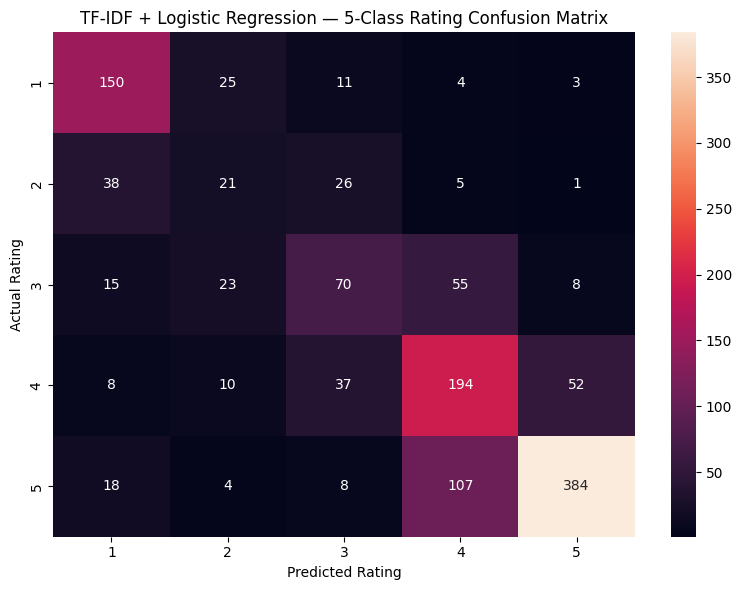

In [ ]:
rating_cm = confusion_matrix(
    y_val_rating,
    rating_val_predictions,
    labels=[1, 2, 3, 4, 5]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    rating_cm,
    annot=True,
    fmt="d",
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5]
)

plt.title(
    "TF-IDF + Logistic Regression — "
    "5-Class Rating Confusion Matrix"
)

plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")

plt.tight_layout()
plt.show()

In [ ]:
X_train_reg = train_df["Review_clean"]
y_train_reg = train_df["Rating_numeric"].astype(float)

X_val_reg = validation_df["Review_clean"]
y_val_reg = validation_df["Rating_numeric"].astype(float)

print("Training regression target:")
print(y_train_reg.describe())

print("\nValidation regression target:")
print(y_val_reg.describe())

Training regression target:
count    3681.000000
mean        3.668976
std         1.463913
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: Rating_numeric, dtype: float64

Validation regression target:
count    1277.000000
mean        3.669538
std         1.442483
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         5.000000
Name: Rating_numeric, dtype: float64


In [ ]:
reg_tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_reg_tfidf = reg_tfidf.fit_transform(X_train_reg)

X_val_reg_tfidf = reg_tfidf.transform(X_val_reg)

print("Training TF-IDF shape:", X_train_reg_tfidf.shape)
print("Validation TF-IDF shape:", X_val_reg_tfidf.shape)

Training TF-IDF shape: (3681, 22603)
Validation TF-IDF shape: (1277, 22603)


In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(
    alpha=1.0
)

ridge_model.fit(
    X_train_reg_tfidf,
    y_train_reg
)

ridge_val_predictions = ridge_model.predict(
    X_val_reg_tfidf
)

print("Ridge regression training completed.")

Ridge regression training completed.


In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_val_reg,
    ridge_val_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_val_reg,
        ridge_val_predictions
    )
)

r2 = r2_score(
    y_val_reg,
    ridge_val_predictions
)

print("TF-IDF + Ridge Regression — Validation")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

TF-IDF + Ridge Regression — Validation
MAE:  0.6436
RMSE: 0.8298
R²:   0.6688


In [ ]:
rating_error = np.abs(
    y_val_reg.values - ridge_val_predictions
)

within_half_star = (
    rating_error <= 0.5
).mean()

within_one_star = (
    rating_error <= 1.0
).mean()

print(
    f"Predictions within ±0.5 rating points: "
    f"{within_half_star * 100:.2f}%"
)

print(
    f"Predictions within ±1.0 rating points: "
    f"{within_one_star * 100:.2f}%"
)

Predictions within ±0.5 rating points: 49.10%
Predictions within ±1.0 rating points: 78.23%


In [ ]:
regression_results = pd.DataFrame({
    "Actual_Rating": y_val_reg.values,
    "Predicted_Rating": ridge_val_predictions
})

regression_results["Absolute_Error"] = (
    np.abs(
        regression_results["Actual_Rating"]
        - regression_results["Predicted_Rating"]
    )
)

display(
    regression_results.head(20).round(3)
)

,Actual_Rating,Predicted_Rating,Absolute_Error
0,4.0,3.515,0.485
1,5.0,4.330,0.670
2,5.0,4.578,0.422
3,1.0,1.263,0.263
4,2.0,2.602,0.602
5,1.0,2.644,1.644
6,5.0,3.867,1.133
7,4.0,4.592,0.592
8,4.0,4.112,0.112
9,5.0,5.320,0.320


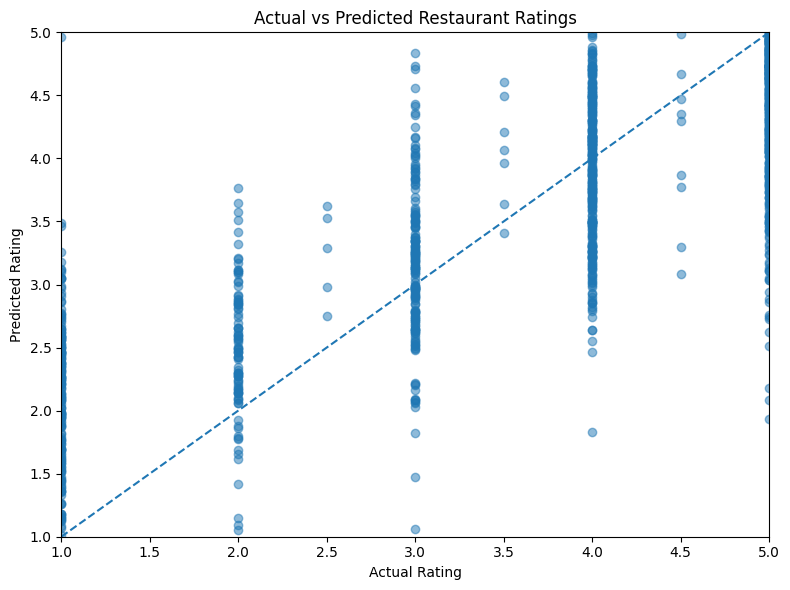

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    regression_results["Actual_Rating"],
    regression_results["Predicted_Rating"],
    alpha=0.5
)

plt.plot(
    [1, 5],
    [1, 5],
    linestyle="--"
)

plt.title("Actual vs Predicted Restaurant Ratings")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.xlim(1, 5)
plt.ylim(1, 5)

plt.tight_layout()
plt.show()

In [ ]:
mean_rating_baseline = np.full(
    len(y_val_reg),
    y_train_reg.mean()
)

baseline_mae = mean_absolute_error(
    y_val_reg,
    mean_rating_baseline
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_val_reg,
        mean_rating_baseline
    )
)

baseline_r2 = r2_score(
    y_val_reg,
    mean_rating_baseline
)

print("Mean-rating regression baseline")
print(f"MAE:  {baseline_mae:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"R²:   {baseline_r2:.4f}")

Mean-rating regression baseline
MAE:  1.2304
RMSE: 1.4419
R²:   -0.0000


# Aspect-Level Gastronomic Analysis

In [ ]:
aspect_keywords = {
    "Food Quality": [
        "food",
        "taste",
        "flavour",
        "flavor",
        "fresh",
        "stale",
        "delicious",
        "tasty",
        "spicy",
        "oily",
        "quality",
        "cooked",
        "undercooked",
        "overcooked",
        "cold",
        "hot",
        "ingredient"
    ],

    "Service": [
        "service",
        "staff",
        "waiter",
        "waitress",
        "server",
        "hospitality",
        "manager",
        "delivery",
        "wait",
        "slow",
        "quick",
        "prompt",
        "courteous",
        "friendly"
    ],

    "Ambience": [
        "ambience",
        "ambiance",
        "atmosphere",
        "decor",
        "decoration",
        "music",
        "lighting",
        "seating",
        "interior",
        "environment",
        "crowded",
        "quiet"
    ],

    "Value for Money": [
        "price",
        "pricing",
        "expensive",
        "overpriced",
        "cheap",
        "affordable",
        "reasonable",
        "value",
        "worth",
        "quantity",
        "portion",
        "cost"
    ],

    "Hygiene": [
        "hygiene",
        "hygienic",
        "clean",
        "cleanliness",
        "dirty",
        "hair",
        "stale",
        "sanitary",
        "washroom",
        "toilet"
    ],

    "Gastronomic Experience": [
        "experience",
        "enjoyed",
        "enjoy",
        "enjoyable",
        "pleasant",
        "disappointing",
        "disappointed",
        "recommend",
        "recommended",
        "must try",
        "visit",
        "worth visiting"
    ]
}

print("Number of aspects:", len(aspect_keywords))

for aspect, keywords in aspect_keywords.items():
    print(f"{aspect}: {len(keywords)} keywords")

Number of aspects: 6
Food Quality: 17 keywords
Service: 14 keywords
Ambience: 12 keywords
Value for Money: 12 keywords
Hygiene: 10 keywords
Gastronomic Experience: 12 keywords


In [ ]:
def detect_aspects(text):
    if pd.isna(text):
        return []

    text_lower = text.lower()

    detected = []

    for aspect, keywords in aspect_keywords.items():
        if any(keyword in text_lower for keyword in keywords):
            detected.append(aspect)

    return detected


ml_df["detected_aspects"] = (
    ml_df["Review_clean"]
    .apply(detect_aspects)
)

display(
    ml_df[
        ["Review_clean", "detected_aspects"]
    ].head(20)
)

,Review_clean,detected_aspects
0,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective . Good place for a sate brunch. One can also chill with friends and or parents. Waiter Soumen Das was rea...","[Food Quality, Service, Ambience, Value for Money]"
1,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,"[Food Quality, Service, Ambience, Gastronomic Experience]"
2,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.,"[Food Quality, Service, Ambience, Gastronomic Experience]"
3,"Soumen das and Arun was a great guy. Only because of their behavior and sincerety, And good food off course, I would like to visit this place again.","[Food Quality, Gastronomic Experience]"
4,Food is good.we ordered Kodi drumsticks and basket mutton biryani. All are good. Thanks to Pradeep. He served well. We enjoyed here. Ambience is also very good.,"[Food Quality, Ambience, Gastronomic Experience]"
5,"Ambiance is good, service is good, food is aPradeecp and subro best service Food is good. Papiya good hostess and ur caption very good. This is 4star restaurant.","[Food Quality, Service, Ambience]"
6,"Its a very nice place, ambience is different, all the food we ordered was very tasty, service is also gud, worth visit. Its reasonable as well. Really a must visit place.","[Food Quality, Service, Ambience, Value for Money, Gastronomic Experience]"
7,Well after reading so many reviews finally visited this place...ambience was so good and coming to food crispy corn is nice. Tawa fish was ok... Basket Biryani disappointed us... biryani was ok bu...,"[Food Quality, Service, Ambience, Gastronomic Experience]"
8,"Excellent food , specially if you like spicy food . Courteous staff . Shubro and pradeep and papiya gave excellent service to our corporate team dinner . Overall great for team dinners and party","[Food Quality, Service]"
9,"Came for the birthday treat of a close friend. Perfect place for a treat like this. Very hospitable and cooperative staff. Food was delicious, ambience was really good with the music and the light...","[Food Quality, Service, Ambience, Gastronomic Experience]"


In [ ]:
aspect_coverage = {}

for aspect in aspect_keywords:

    aspect_coverage[aspect] = ml_df[
        "detected_aspects"
    ].apply(
        lambda aspects: aspect in aspects
    ).sum()

aspect_coverage_df = pd.DataFrame({
    "Aspect": aspect_coverage.keys(),
    "Reviews_with_Aspect_Evidence": aspect_coverage.values()
})

aspect_coverage_df["Coverage_Percentage"] = (
    aspect_coverage_df["Reviews_with_Aspect_Evidence"]
    / len(ml_df)
    * 100
).round(2)

display(
    aspect_coverage_df.sort_values(
        "Coverage_Percentage",
        ascending=False
    )
)

,Aspect,Reviews_with_Aspect_Evidence,Coverage_Percentage
0,Food Quality,4434,72.00
1,Service,3033,49.25
5,Gastronomic Experience,2474,40.18
2,Ambience,1942,31.54
3,Value for Money,1327,21.55
4,Hygiene,246,3.99


In [ ]:
for aspect in aspect_keywords:

    aspect_reviews = ml_df[
        ml_df["detected_aspects"].apply(
            lambda aspects: aspect in aspects
        )
    ]

    print(f"\n===== {aspect} =====")
    print(
        "Reviews detected:",
        len(aspect_reviews)
    )

    display(
        aspect_reviews[
            ["Restaurant", "Review_clean", "Rating_numeric"]
        ].head(5)
    )


===== Food Quality =====
Reviews detected: 4434


,Restaurant,Review_clean,Rating_numeric
0,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective . Good place for a sate brunch. One can also chill with friends and or parents. Waiter Soumen Das was rea...",5.0
1,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,5.0
2,Beyond Flavours,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.,5.0
3,Beyond Flavours,"Soumen das and Arun was a great guy. Only because of their behavior and sincerety, And good food off course, I would like to visit this place again.",5.0
4,Beyond Flavours,Food is good.we ordered Kodi drumsticks and basket mutton biryani. All are good. Thanks to Pradeep. He served well. We enjoyed here. Ambience is also very good.,5.0



===== Service =====
Reviews detected: 3033


,Restaurant,Review_clean,Rating_numeric
0,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective . Good place for a sate brunch. One can also chill with friends and or parents. Waiter Soumen Das was rea...",5.0
1,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,5.0
2,Beyond Flavours,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.,5.0
5,Beyond Flavours,"Ambiance is good, service is good, food is aPradeecp and subro best service Food is good. Papiya good hostess and ur caption very good. This is 4star restaurant.",5.0
6,Beyond Flavours,"Its a very nice place, ambience is different, all the food we ordered was very tasty, service is also gud, worth visit. Its reasonable as well. Really a must visit place.",5.0



===== Ambience =====
Reviews detected: 1942


...

,Restaurant,Review_clean,Rating_numeric
0,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective . Good place for a sate brunch. One can also chill with friends and or parents. Waiter Soumen Das was rea...",5.0
6,Beyond Flavours,"Its a very nice place, ambience is different, all the food we ordered was very tasty, service is also gud, worth visit. Its reasonable as well. Really a must visit place.",5.0
21,Beyond Flavours,"please was good but it was quite expensive and coming to taste we can rate 3 out of 5, we cant click better pictures wen we visit in night🤣🤭best in day time for pics",4.0
30,Beyond Flavours,"Short review: Decent breads and starters, bad Shaam Savera, a little screwed up daal makhni (but should be a one-off case) Better ambience at night... And importantly good quantity! I wanted to gi...",3.0
35,Beyond Flavours,Service experience was very good especially by Papiya. Food served was very good and tasty and they served it very well. I would like to visit Beyond again and will recommend it to friends for its...,5.0



===== Hygiene =====
Reviews detected: 246


,Restaurant,Review_clean,Rating_numeric
14,Beyond Flavours,"We ordered corn cheese balls, manchow soup and paneer shashlik sizzler. The sizzler was stale. Paneer was smelling and the waiter was so impolite to even accept the mistake. Never going again",1.0
79,Beyond Flavours,"I would like to introduce this restaurant to a new ingredient called salt. If you add that yo your food, it would taste way better. So basically none of the food we ordered had salt. We ordered Fr...",1.0
84,Beyond Flavours,This was my worst experience at a restaurant ever. First our starters were served after half an hour of ordering and the chicken popcorn had a hair strand in it yuck! Then the guy who took our mai...,1.0
98,Beyond Flavours,Pathetic and horrible experience Ambience and hospitality 1 Food 1 chairs and tables were broken food is cold and tasteless Buffet arrangement is not good could be a bit more spacious,2.0
127,Paradise,Good food and good service. Good options for vegetarians also. Desserts are very tasty. Ambience is also neat and the place looks very hygienic,4.0



===== Gastronomic Experience =====
Reviews detected: 2474


,Restaurant,Review_clean,Rating_numeric
1,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,5.0
2,Beyond Flavours,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.,5.0
3,Beyond Flavours,"Soumen das and Arun was a great guy. Only because of their behavior and sincerety, And good food off course, I would like to visit this place again.",5.0
4,Beyond Flavours,Food is good.we ordered Kodi drumsticks and basket mutton biryani. All are good. Thanks to Pradeep. He served well. We enjoyed here. Ambience is also very good.,5.0
6,Beyond Flavours,"Its a very nice place, ambience is different, all the food we ordered was very tasty, service is also gud, worth visit. Its reasonable as well. Really a must visit place.",5.0


In [ ]:
aspect_patterns = {
    "Food Quality": [
        "food", "taste", "tasty", "delicious", "flavour", "flavor",
        "fresh", "stale", "quality", "cooked", "cooking",
        "undercooked", "overcooked", "cold food", "hot food",
        "spicy", "salty", "oily", "bland", "portion", "quantity",
        "dish", "dishes", "starter", "starters", "main course",
        "dessert", "desserts", "biryani", "pasta", "pizza"
    ],

    "Service": [
        "service", "staff", "waiter", "waitress", "server",
        "hospitality", "attitude", "behaviour", "behavior",
        "courteous", "friendly staff", "polite staff",
        "slow service", "quick service", "prompt service",
        "waiting", "waited", "bill", "manager"
    ],

    "Ambience": [
        "ambience", "ambiance", "atmosphere", "decor",
        "decoration", "interior", "lighting", "music",
        "seating", "chairs", "tables", "crowded", "quiet",
        "spacious", "cramped", "environment", "view"
    ],

    "Value for Money": [
        "price", "pricing", "expensive", "overpriced",
        "affordable", "reasonable", "cheap", "worth",
        "value for money", "cost", "quantity", "portion",
        "price paid", "worth the price"
    ],

    "Hygiene": [
        "hygiene", "hygienic", "clean", "cleanliness",
        "dirty", "hair in", "hair strand", "insect",
        "cockroach", "fly in", "stale food", "smelling food",
        "bad smell", "foul smell", "contaminated",
        "washroom", "toilet", "sanitary", "unclean",
        "not clean", "poor hygiene"
    ],

    "Gastronomic Experience": [
        "experience", "overall experience", "dining experience",
        "meal experience", "enjoyed", "enjoyable",
        "pleasant", "disappointing", "disappointed",
        "recommend", "recommended", "must try",
        "must visit", "visit again", "go again",
        "would recommend", "worth visiting"
    ]
}

In [ ]:
import re

def split_into_sentences(text):
    if pd.isna(text):
        return []

    text = str(text).strip()

    sentences = re.split(
        r'(?<=[.!?])\s+|\n+',
        text
    )

    return [
        sentence.strip()
        for sentence in sentences
        if sentence.strip()
    ]

In [ ]:
def detect_sentence_aspects(sentence):
    sentence_lower = sentence.lower()

    detected = []

    for aspect, patterns in aspect_patterns.items():

        for pattern in patterns:

            if pattern in sentence_lower:
                detected.append(aspect)
                break

    return detected

In [ ]:
aspect_evidence = []

for _, row in ml_df.iterrows():

    review = row["Review_clean"]

    for sentence in split_into_sentences(review):

        detected = detect_sentence_aspects(sentence)

        for aspect in detected:

            aspect_evidence.append({
                "Restaurant": row["Restaurant"],
                "Review": review,
                "Sentence": sentence,
                "Aspect": aspect,
                "Rating_numeric": row["Rating_numeric"]
            })

aspect_evidence_df = pd.DataFrame(aspect_evidence)

print(
    "Aspect evidence records:",
    len(aspect_evidence_df)
)

display(
    aspect_evidence_df.head(20)
)

Aspect evidence records: 21395


,Restaurant,Review,Sentence,Aspect,Rating_numeric
0,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...","The ambience was good, food was quite good .",Food Quality,5.0
1,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...","The ambience was good, food was quite good .",Ambience,5.0
2,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...","had Saturday lunch , which was cost effective .",Value for Money,5.0
3,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...",Waiter Soumen Das was really courteous and helpful.,Service,5.0
4,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Ambience is too good for a pleasant evening.,Ambience,5.0
5,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Ambience is too good for a pleasant evening.,Gastronomic Experience,5.0
6,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Service is very prompt.,Service,5.0
7,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Food is good.,Food Quality,5.0
8,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Over all a good experience.,Gastronomic Experience,5.0
9,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Soumen Das - kudos to the service,Service,5.0


In [ ]:
aspect_sentence_coverage = (
    aspect_evidence_df
    .groupby("Aspect")
    .size()
    .reset_index(name="Aspect_Evidence_Count")
)

aspect_sentence_coverage["Percentage_of_Evidence"] = (
    aspect_sentence_coverage["Aspect_Evidence_Count"]
    / len(aspect_evidence_df)
    * 100
).round(2)

display(
    aspect_sentence_coverage
    .sort_values(
        "Aspect_Evidence_Count",
        ascending=False
    )
)

,Aspect,Aspect_Evidence_Count,Percentage_of_Evidence
1,Food Quality,10421,48.71
4,Service,3765,17.60
0,Ambience,2825,13.20
2,Gastronomic Experience,2498,11.68
5,Value for Money,1645,7.69
3,Hygiene,241,1.13


In [ ]:
for aspect in aspect_patterns:

    print(f"\n========== {aspect} ==========")

    sample = (
        aspect_evidence_df[
            aspect_evidence_df["Aspect"] == aspect
        ]
        .sample(
            min(
                10,
                (
                    aspect_evidence_df["Aspect"] == aspect
                ).sum()
            ),
            random_state=42
        )
    )

    display(
        sample[
            [
                "Restaurant",
                "Sentence",
                "Rating_numeric"
            ]
        ]
    )


========== Food Quality ==========


,Restaurant,Sentence,Rating_numeric
16438,Al Saba Restaurant,Taste also very bad.,1.0
1457,The Fisherman's Wharf,You sure would get amazing non veg and sea food but they have good veg options as well and in my five to six visits to this place I have covered the entire vegetarian menu.,4.0
19751,Desi Bytes,", forest food",1.0
20795,Triptify,"I think the biggest disappointment while ordering a stuffed paratha would be ""less stuffing"", but here is a big thumps up to these people Coz evrytime we ordered parathas from here the quality and...",5.0
17339,American Wild Wings,"Follow me on- Instagram and Facebook- @curiousfoodieswanderlust, Curious Foodies Wanderlust",4.0
90,Beyond Flavours,"Food was perfect desserts, starters was wonderful",5.0
1438,The Fisherman's Wharf,"The have amazing ambience, delicious food and extremely courteous staff.",5.0
16441,Al Saba Restaurant,The flavours are perfectly balanced it was my first order though I have never had it before this so I will have it again in future to know if the consistency is the same !,5.0
15542,Khaan Saab,The taste is good but as compared to price quantity is less.,4.0
5936,Pot Pourri,We ordered Andhra dishes.,5.0



========== Service ==========


,Restaurant,Sentence,Rating_numeric
8060,Kritunga Restaurant,Very bad service.,1.0
16353,Delhi-39,In terms of ambience it has very less to offer and an okayish service.,3.0
847,Flechazo,Service: it's very good and all the servers are trained very well.,3.0
16067,Olive Garden,"Though service is a bit on slower side, food will make for it.",4.0
10711,Udipi's Upahar,"Be prepared for the rush and once you get the token, be prepared to be squeezed in a corner to give out your token to the waiters inside.",4.0
8601,The Glass Onion,"However the restaurant did not live up to the high expectations, considering the average food and slow service.",3.0
10764,Udipi's Upahar,thank thank you for your services.,5.0
1158,Shah Ghouse Hotel & Restaurant,Decent service as well.,4.0
18643,Collage - Hyatt Hyderabad Gachibowli,My server Tushar was very patient and attentive.,4.0
13239,Komatose - Holiday Inn Express & Suites,The service for me was average unfortunately.,4.0



========== Ambience ==========


...

,Restaurant,Sentence,Rating_numeric
9766,Owm Nom Nom,"Old fish, cheap oil they use.",1.0
20449,Zega - Sheraton Hyderabad Hotel,Cost is very reasonable for the place which is a very pleasant surprise.,5.0
10279,Shanghai Chef 2,Price is reasonable.,5.0
15502,Khaan Saab,Food quantity is too less.,4.0
16545,Al Saba Restaurant,quantity is less,4.0
3702,NorFest - The Dhaba,They are very small quantity.,1.0
19863,Hyderabadi Daawat,It was worth travelling 25 KM's to visit this place.,5.0
11142,Mathura Vilas,The cost of the thali was 300 plus taxes so it costed around 330 per thali.,4.0
16292,Delhi-39,Price is average.,4.0
12366,Feast - Sheraton Hyderabad Hotel,And when i asked if they can prepare (with the huge cost of ₹1750 involved) they couldn't.,1.0



========== Hygiene ==========


,Restaurant,Sentence,Rating_numeric
2312,Hyper Local,I had a very experience related to the hygiene of the place.,1.0
676,Paradise,The place is clean and neat .,4.0
20106,Hyderabadi Daawat,Hygiene:3/5(table was not properly cleaned),4.0
18248,Cascade - Radisson Hyderabad Hitec City,They cleaned the room everyday.,4.0
20845,Triptify,paratha had some sort of foul smell.,2.0
16107,Tandoori Food Works,Neat and clean packing with great taste.,5.0
17118,T Grill,Ambience and cleanliness: 1/5 (worst),2.0
19669,Desi Bytes,no cleanliness.,1.0
1137,Shah Ghouse Hotel & Restaurant,There i like they serve to us and the way they maintain the restaurant clean,5.0
10417,Shanghai Chef 2,Unhygienic pace!,1.0



========== Gastronomic Experience ==========


,Restaurant,Sentence,Rating_numeric
19411,Zing's Northeast Kitchen,Thoroughly disappointed.,1.0
15684,Khaan Saab,"Rajwada Raj Gosht is a must try, I bet you would be mesmerized by the tender lamb pieces in the spicy curry.",5.0
6889,Marsala Food Company,"Treating myself with the milkshakes and Desserts now in milkshakes I tried chocolate, butterscotch and KitKat I liked the KitKat one it was so deliciously topped with a scoop of ice-cream and then...",5.0
18994,Collage - Hyatt Hyderabad Gachibowli,I strongly recommend everyone that Collage is a place you must have meals during your stay at Hyderabad.,5.0
10504,Shanghai Chef 2,Went to this place which a bunch of foodies for a review session and to my delight it turned out to be an awesome experience.,5.0
392,Beyond Flavours,It’s a worst service experience.,1.0
16938,T Grill,I recommend don't go to this place at all,1.0
5805,Pot Pourri,"So, wouldn't recommend to order chinese again from here.",3.0
5930,Pot Pourri,Must try place,4.0
6892,Marsala Food Company,I was totally disappointed with the food.,1.0


In [ ]:
aspect_texts = aspect_evidence_df["Sentence"]

aspect_tfidf = best_vectorizer.transform(
    aspect_texts
)

aspect_predictions = (
    best_logistic_model.predict(aspect_tfidf)
)

aspect_evidence_df["Predicted_Sentiment"] = (
    aspect_predictions
)

display(
    aspect_evidence_df.head(20)
)

,Restaurant,Review,Sentence,Aspect,Rating_numeric,Predicted_Sentiment
0,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...","The ambience was good, food was quite good .",Food Quality,5.0,Positive
1,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...","The ambience was good, food was quite good .",Ambience,5.0,Positive
2,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...","had Saturday lunch , which was cost effective .",Value for Money,5.0,Neutral
3,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...",Waiter Soumen Das was really courteous and helpful.,Service,5.0,Positive
4,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Ambience is too good for a pleasant evening.,Ambience,5.0,Positive
5,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Ambience is too good for a pleasant evening.,Gastronomic Experience,5.0,Positive
6,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Service is very prompt.,Service,5.0,Positive
7,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Food is good.,Food Quality,5.0,Positive
8,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Over all a good experience.,Gastronomic Experience,5.0,Positive
9,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Soumen Das - kudos to the service,Service,5.0,Positive


In [ ]:
aspect_validation_sample = (
    aspect_evidence_df
    .sample(
        min(100, len(aspect_evidence_df)),
        random_state=42
    )
    .reset_index(drop=True)
)

aspect_validation_sample["Aspect_Correct"] = ""

display(aspect_validation_sample)

,Restaurant,Review,Sentence,Aspect,Rating_numeric,Predicted_Sentiment,Aspect_Correct
0,AB's - Absolute Barbecues,Varun and sandeep done excellent job\n..awesome hospitality.... excellent food and ambience..will recommend tommy other college and family members....,..awesome hospitality....,Service,5.0,Positive,
1,Pot Pourri,*Writing this review as soon as I got out of the restaurant*\nFrom the beginning itself the restaurant caught my bad impression and bad experience. Left right after starters. I wouldn't even care ...,"After seeing no improvement we finally had to speak to the manager as listen to ""sorrys"".",Service,1.0,Negative,
2,Aromas@11SIX,Situated a little away from the main road Aromas serves quite good Indian as well as Continental dishes including Chinese and Thai food. The cost of all the dishes are at the lower side as compare...,Though the service here is not so good but the food covers it all.,Food Quality,5.0,Neutral,
3,Frio Bistro,Been to this place last month. Quite a peaceful place not many people were there. We ordered some drinks and pizza and pasta. I somehow felt pizza could have been little better the taste was good ...,I somehow felt pizza could have been little better the taste was good and it was cooked properly.,Food Quality,3.0,Positive,
4,B-Dubs,This is a very overhyped and overpriced place.\nThe wings are small in size and very shrivelled and the sauces are not that great too. The Jalapeño poppers we undercooked and nachos were very blan...,The Jalapeño poppers we undercooked and nachos were very bland.,Food Quality,1.0,Negative,
...,...,...,...,...,...,...,...
95,Ulavacharu,Worst service. Food quantity is very less. Even the AC temperature was high. I suggest not to visit this place. Ridiculous thing was thums up and water was served hot.,Worst service.,Service,1.0,Negative,
96,Ulavacharu,Too much expensive for the quantity served. Not worth the money. Most items in the menu aren't available.\n\nTaste is just average. Not recommended,Not recommended,Gastronomic Experience,1.0,Negative,
97,Gal Punjab Di,When you love food and especially north Indian food you crave for the perfect butter chicken that you would probably get up north.\n\nI guess I finally seemed to have found it in Hyderabad.\n\nHav...,will update that later once I visit the place but food is something that's outstanding,Food Quality,4.0,Positive,
98,The Indi Grill,This place is nice for formal dinners and family dinners. It's a comfortable place and the service was quick.\nBarbeque and starters was good here but the food here was average.,It's a comfortable place and the service was quick.,Service,4.0,Positive,


In [ ]:
import re

aspect_patterns_refined = {
    "Food Quality": [
        "food",
        "taste",
        "tasty",
        "delicious",
        "flavour",
        "flavor",
        "fresh",
        "stale",
        "food quality",
        "cooking",
        "cooked",
        "undercooked",
        "overcooked",
        "cold food",
        "hot food",
        "spicy",
        "salty",
        "oily",
        "bland",
        "dish",
        "dishes",
        "starter",
        "starters",
        "main course",
        "dessert",
        "desserts",
        "biryani",
        "pasta",
        "pizza"
    ],

    "Service": [
        "service",
        "staff",
        "waiter",
        "waitress",
        "server",
        "hospitality",
        "manager",
        "rude staff",
        "polite staff",
        "friendly staff",
        "courteous staff",
        "slow service",
        "quick service",
        "prompt service",
        "poor service",
        "bad service",
        "staff behaviour",
        "staff behavior"
    ],

    "Ambience": [
        "ambience",
        "ambiance",
        "atmosphere",
        "decor",
        "decoration",
        "interior",
        "lighting",
        "music",
        "seating",
        "chairs",
        "tables",
        "crowded",
        "quiet",
        "spacious",
        "cramped",
        "environment",
        "view"
    ],

    "Value for Money": [
        "price",
        "pricing",
        "expensive",
        "overpriced",
        "affordable",
        "reasonable price",
        "reasonable pricing",
        "cheap",
        "value for money",
        "cost",
        "quantity",
        "portion",
        "worth the price",
        "price paid",
        "worth the money",
        "cost effective"
    ],

    "Hygiene": [
        "hygiene",
        "hygienic",
        "cleanliness",
        "dirty",
        "hair in",
        "hair strand",
        "insect",
        "cockroach",
        "fly in",
        "contaminated",
        "unclean",
        "poor hygiene",
        "unhygienic",
        "washroom",
        "toilet",
        "sanitary",
        "foul smell",
        "bad smell"
    ],

    "Overall Dining Experience": [
        "overall experience",
        "dining experience",
        "meal experience",
        "pleasant experience",
        "disappointing experience",
        "terrible experience",
        "wonderful experience",
        "awesome experience",
        "would recommend",
        "strongly recommend",
        "highly recommend",
        "must try",
        "must visit",
        "visit again",
        "go again"
    ]
}

In [ ]:
def contains_pattern(text, pattern):
    text = text.lower()

    # Match phrases normally
    if " " in pattern:
        return pattern in text

    # Match single words using word boundaries
    return re.search(
        rf"\b{re.escape(pattern)}\b",
        text
    ) is not None

In [ ]:
def detect_refined_aspects(sentence):
    sentence = str(sentence).strip()

    detected = []

    for aspect, patterns in aspect_patterns_refined.items():

        if any(
            contains_pattern(sentence, pattern)
            for pattern in patterns
        ):
            detected.append(aspect)

    return detected

In [ ]:
refined_aspect_evidence = []

for _, row in ml_df.iterrows():

    review = row["Review_clean"]

    for sentence in split_into_sentences(review):

        detected = detect_refined_aspects(sentence)

        for aspect in detected:

            refined_aspect_evidence.append({
                "Restaurant": row["Restaurant"],
                "Review": review,
                "Sentence": sentence,
                "Aspect": aspect,
                "Rating_numeric": row["Rating_numeric"]
            })

refined_aspect_evidence_df = pd.DataFrame(
    refined_aspect_evidence
)

print(
    "Refined aspect evidence records:",
    len(refined_aspect_evidence_df)
)

display(
    refined_aspect_evidence_df.head(20)
)

Refined aspect evidence records: 17557


,Restaurant,Review,Sentence,Aspect,Rating_numeric
0,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...","The ambience was good, food was quite good .",Food Quality,5.0
1,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...","The ambience was good, food was quite good .",Ambience,5.0
2,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...","had Saturday lunch , which was cost effective .",Value for Money,5.0
3,Beyond Flavours,"The ambience was good, food was quite good . had Saturday lunch , which was cost effective .\nGood place for a sate brunch. One can also chill with friends and or parents.\nWaiter Soumen Das was r...",Waiter Soumen Das was really courteous and helpful.,Service,5.0
4,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Ambience is too good for a pleasant evening.,Ambience,5.0
5,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Service is very prompt.,Service,5.0
6,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Food is good.,Food Quality,5.0
7,Beyond Flavours,Ambience is too good for a pleasant evening. Service is very prompt. Food is good. Over all a good experience. Soumen Das - kudos to the service,Soumen Das - kudos to the service,Service,5.0
8,Beyond Flavours,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.,A must try..,Overall Dining Experience,5.0
9,Beyond Flavours,A must try.. great food great ambience. Thnx for the service by Pradeep and Subroto. My personal recommendation is Penne Alfredo Pasta:) ....... Also the music in the background is amazing.,great food great ambience.,Food Quality,5.0


In [ ]:
old_coverage = (
    ml_df["detected_aspects"]
    .explode()
    .value_counts()
)

new_coverage = (
    refined_aspect_evidence_df["Aspect"]
    .value_counts()
)

coverage_comparison = pd.DataFrame({
    "Previous_Count": old_coverage,
    "Refined_Count": new_coverage
}).fillna(0)

coverage_comparison["Reduction_%"] = (
    (
        coverage_comparison["Previous_Count"]
        - coverage_comparison["Refined_Count"]
    )
    / coverage_comparison["Previous_Count"]
    * 100
).round(2)

display(
    coverage_comparison.sort_values(
        "Refined_Count",
        ascending=False
    )
)

,Previous_Count,Refined_Count,Reduction_%
Food Quality,4434.0,9465.0,-113.46
Service,3033.0,3345.0,-10.29
Ambience,1942.0,2502.0,-28.84
Value for Money,1327.0,1165.0,12.21
Overall Dining Experience,0.0,926.0,-inf
Hygiene,246.0,154.0,37.40
Gastronomic Experience,2474.0,0.0,100.00


In [ ]:
aspect_validation_sample = (
    refined_aspect_evidence_df
    .sample(
        min(100, len(refined_aspect_evidence_df)),
        random_state=42
    )
    .reset_index(drop=True)
)

aspect_validation_sample["Aspect_Correct"] = ""
aspect_validation_sample["Sentiment_Correct"] = ""

display(aspect_validation_sample)

,Restaurant,Review,Sentence,Aspect,Rating_numeric,Aspect_Correct,Sentiment_Correct
0,Hyderabadi Daawat,It's always good to see restaurants which focus on Hyderabadi cuisine since it's so diverse and encompasses a lot of different varieties within it. Hyderabadi Daawat does justice to it's name but ...,Hyderabadi Daawat does justice to it's name but treating us to good Hyderabadi food.,Food Quality,4.0,,
1,Hyderabadi Daawat,This is a newly opened restaurant in Gachibowli. It is famous for it's Nizami style of cuisine. It is very spacious and has a cozy ambience with good music.\n\nDishes that we have tried:\n\n1. Chi...,The pictures of the famous dishes served here are displayed in the LCD Tv's.,Food Quality,4.0,,
2,Royal Spicy Restaurant,"I ordered ulavacharu chicken biryani spicy fried chicken, chicken fried piece Biryani excellent taste and good quality and quick delivery 😀😀😀","I ordered ulavacharu chicken biryani spicy fried chicken, chicken fried piece Biryani excellent taste and good quality and quick delivery 😀😀😀",Food Quality,5.0,,
3,Pista House,Had ordered almond cake from pista house.\nIt was not much fresh but tastes okay.\nOver all seemed like they have not delivered fresh cake as I saw water was also coming from the cake.\nHope so th...,Over all seemed like they have not delivered fresh cake as I saw water was also coming from the cake.,Food Quality,3.0,,
4,Hyderabadi Daawat,"'Say no more!'\n\nFood - The name itself will get any Hyderabadis taste buds jiggle! And certainly it stood up to it's name, the food here was delectable!\n\nI'll list out my favorites first, In t...",Service - It was decent!,Service,4.0,,
...,...,...,...,...,...,...,...
95,Urban Asia - Kitchen & Bar,"Amazing interior, heartwarming services, affordable price and wow food! The quantity was more than adequate too! We ordered pork ribs, heaven on a plate, fried ice cream and Nasi goreng. A must vi...","Amazing interior, heartwarming services, affordable price and wow food!",Value for Money,5.0,,
96,Zega - Sheraton Hyderabad Hotel,"We have been to this place for a special occasion and we loved every bit of the offering this place had in store for us . The food , ambience , service and nevertheless the service of the host. Th...",The dishes were rightfully suggested and we dug in fully satisfied.,Food Quality,4.0,,
97,Pista House,Every year I desparately wait to try their Haleem during Ramadan season.\nAlways knew about their Haleem and was surprised to taste their mughai range.\n\nThe food was delicious and quite easy on ...,The dessert range in the bakery section was yummy and delicious.,Food Quality,5.0,,
98,"3B's - Buddies, Bar & Barbecue","Nice ambiance, nice food in affordable price. Mr. Govind's served us\nGood service by Govind. My favourite dish is chicken tikka chicken wings especially pineapple","Nice ambiance, nice food in affordable price.",Food Quality,5.0,,


In [ ]:
def calculate_annotation_accuracy(data, column_name):

    annotations = pd.to_numeric(
        data[column_name],
        errors="coerce"
    )

    valid_annotations = annotations.dropna()

    if len(valid_annotations) == 0:
        return None

    return valid_annotations.mean()


aspect_accuracy = calculate_annotation_accuracy(
    aspect_validation_sample,
    "Aspect_Correct"
)

sentiment_accuracy = calculate_annotation_accuracy(
    aspect_validation_sample,
    "Sentiment_Correct"
)

if aspect_accuracy is None:
    print("No Aspect_Correct annotations have been entered yet.")
else:
    print(
        f"Aspect annotation accuracy: "
        f"{aspect_accuracy * 100:.2f}%"
    )

if sentiment_accuracy is None:
    print("No Sentiment_Correct annotations have been entered yet.")
else:
    print(
        f"Sentiment annotation accuracy: "
        f"{sentiment_accuracy * 100:.2f}%"
    )

No Aspect_Correct annotations have been entered yet.
No Sentiment_Correct annotations have been entered yet.


In [ ]:
review_level_aspect_coverage = (
    refined_aspect_evidence_df[
        ["Restaurant", "Review", "Aspect"]
    ]
    .drop_duplicates()
    .groupby("Aspect")
    .size()
    .reset_index(name="Reviews_with_Aspect_Evidence")
)

review_level_aspect_coverage["Coverage_Percentage"] = (
    review_level_aspect_coverage["Reviews_with_Aspect_Evidence"]
    / len(ml_df)
    * 100
).round(2)

display(
    review_level_aspect_coverage
    .sort_values(
        "Coverage_Percentage",
        ascending=False
    )
)

,Aspect,Reviews_with_Aspect_Evidence,Coverage_Percentage
1,Food Quality,4624,75.09
4,Service,2565,41.65
0,Ambience,1981,32.17
5,Value for Money,985,16.00
3,Overall Dining Experience,840,13.64
2,Hygiene,135,2.19


In [ ]:
aspect_evidence_density = (
    refined_aspect_evidence_df
    .groupby("Aspect")
    .size()
    .reset_index(name="Evidence_Sentences")
)

aspect_evidence_density["Evidence_per_Review"] = (
    aspect_evidence_density["Evidence_Sentences"]
    / review_level_aspect_coverage
      .set_index("Aspect")
      ["Reviews_with_Aspect_Evidence"]
      .reindex(aspect_evidence_density["Aspect"])
      .values
).round(2)

display(
    aspect_evidence_density
    .sort_values(
        "Evidence_Sentences",
        ascending=False
    )
)

,Aspect,Evidence_Sentences,Evidence_per_Review
1,Food Quality,9465,2.05
4,Service,3345,1.30
0,Ambience,2502,1.26
5,Value for Money,1165,1.18
3,Overall Dining Experience,926,1.10
2,Hygiene,154,1.14


In [ ]:
evaluation_words = {
    "positive": [
        "good", "great", "excellent", "amazing", "awesome",
        "delicious", "tasty", "wonderful", "perfect",
        "fantastic", "best", "nice", "pleasant", "friendly",
        "courteous", "prompt", "quick", "reasonable",
        "affordable", "clean", "hygienic", "worth"
    ],

    "negative": [
        "bad", "worst", "poor", "terrible", "horrible",
        "pathetic", "awful", "stale", "bland", "oily",
        "salty", "cold", "slow", "rude", "dirty",
        "expensive", "overpriced", "unhygienic",
        "disappointing", "disappointed", "not good",
        "not worth", "less quantity"
    ]
}

all_evaluation_words = (
    evaluation_words["positive"]
    + evaluation_words["negative"]
)

In [ ]:
aspect_triggers = {

    "Food Quality": [
        "food", "taste", "tasty", "delicious", "flavour",
        "flavor", "fresh", "stale", "food quality",
        "cooking", "cooked", "undercooked", "overcooked",
        "spicy", "salty", "oily", "bland", "dish",
        "dishes", "starter", "starters", "main course",
        "dessert", "desserts", "biryani", "pasta", "pizza"
    ],

    "Service": [
        "service", "staff", "waiter", "waitress", "server",
        "hospitality", "rude staff", "polite staff",
        "friendly staff", "courteous staff",
        "slow service", "quick service", "prompt service",
        "poor service", "bad service", "waiting",
        "waited", "manager", "bill"
    ],

    "Ambience": [
        "ambience", "ambiance", "atmosphere", "decor",
        "decoration", "interior", "lighting", "music",
        "seating", "chairs", "tables", "crowded",
        "quiet", "spacious", "cramped", "environment"
    ],

    "Value for Money": [
        "price", "pricing", "expensive", "overpriced",
        "affordable", "reasonable price", "reasonable pricing",
        "cheap", "value for money", "cost", "quantity",
        "portion", "worth the price", "price paid",
        "worth the money", "cost effective", "less quantity"
    ],

    "Hygiene": [
        "hygiene", "hygienic", "cleanliness", "dirty",
        "hair in", "hair strand", "insect", "cockroach",
        "fly in", "contaminated", "unclean", "poor hygiene",
        "unhygienic", "washroom", "toilet", "sanitary",
        "foul smell", "bad smell"
    ],

    "Overall Dining Experience": [
        "overall experience", "dining experience",
        "meal experience", "pleasant experience",
        "disappointing experience", "terrible experience",
        "wonderful experience", "awesome experience",
        "would recommend", "strongly recommend",
        "highly recommend", "must try", "must visit",
        "visit again", "go again", "not recommended"
    ]
}

In [ ]:
def has_evaluation_context(sentence):
    text = sentence.lower()

    return any(
        contains_pattern(text, word)
        for word in all_evaluation_words
    )


def detect_strong_aspects(sentence):
    text = str(sentence).strip()

    if not text:
        return []

    detected = []

    for aspect, triggers in aspect_triggers.items():

        aspect_found = any(
            contains_pattern(text, trigger)
            for trigger in triggers
        )

        evaluation_found = has_evaluation_context(text)

        # Keep explicit experience/recommendation phrases
        if aspect == "Overall Dining Experience":
            if aspect_found:
                detected.append(aspect)

        # For other aspects, require an evaluative context.
        elif aspect_found and evaluation_found:
            detected.append(aspect)

    return detected

In [ ]:
strong_aspect_evidence = []

for _, row in ml_df.iterrows():

    review = row["Review_clean"]

    for sentence in split_into_sentences(review):

        detected = detect_strong_aspects(sentence)

        for aspect in detected:

            strong_aspect_evidence.append({
                "Restaurant": row["Restaurant"],
                "Review": review,
                "Sentence": sentence,
                "Aspect": aspect,
                "Rating_numeric": row["Rating_numeric"]
            })

strong_aspect_evidence_df = pd.DataFrame(
    strong_aspect_evidence
)

print(
    "Strong aspect evidence records:",
    len(strong_aspect_evidence_df)
)

Strong aspect evidence records: 10077


In [ ]:
strong_review_coverage = (
    strong_aspect_evidence_df[
        ["Restaurant", "Review", "Aspect"]
    ]
    .drop_duplicates()
    .groupby("Aspect")
    .size()
    .reset_index(
        name="Reviews_with_Strong_Aspect_Evidence"
    )
)

strong_review_coverage["Coverage_Percentage"] = (
    strong_review_coverage[
        "Reviews_with_Strong_Aspect_Evidence"
    ]
    / len(ml_df)
    * 100
).round(2)

display(
    strong_review_coverage
    .sort_values(
        "Coverage_Percentage",
        ascending=False
    )
)

,Aspect,Reviews_with_Strong_Aspect_Evidence,Coverage_Percentage
1,Food Quality,3574,58.04
4,Service,1931,31.36
0,Ambience,1253,20.35
3,Overall Dining Experience,853,13.85
5,Value for Money,600,9.74
2,Hygiene,77,1.25


In [ ]:
for aspect in aspect_triggers:

    print(f"\n========== {aspect} ==========")

    aspect_rows = strong_aspect_evidence_df[
        strong_aspect_evidence_df["Aspect"] == aspect
    ]

    print("Evidence records:", len(aspect_rows))

    if len(aspect_rows) > 0:

        display(
            aspect_rows[
                [
                    "Restaurant",
                    "Sentence",
                    "Rating_numeric"
                ]
            ]
            .sample(
                min(8, len(aspect_rows)),
                random_state=42
            )
        )


========== Food Quality ==========
Evidence records: 4916


,Restaurant,Sentence,Rating_numeric
4998,Ulavacharu,Food is very tasty.,5.0
9621,Zega - Sheraton Hyderabad Hotel,"We ordered Thai curry red chicken for main course ,it was coconut milk curry paste had taste of lime grass,basil ,some veggie like baby corn ,beans also used ,having ting of sweetness,served with ...",4.0
1627,Absolute Sizzlers,Worst food and their best item is chicken shashlik sizzler which is worst today..,1.0
8107,T Grill,"On the whole, all the dishes we tasted there were awesome except for the heat from the spice!",4.0
5271,Udipi's Upahar,awesome food,5.0
195,Beyond Flavours,Food was very good and the ambience was also very nice.,5.0
5527,Gal Punjab Di,We had both veg and non veg food and both were pretty tasty.,5.0
9892,Chinese Pavilion,Great place for Chinese food lovers,5.0



========== Service ==========
Evidence records: 2164


,Restaurant,Sentence,Rating_numeric
9653,Zega - Sheraton Hyderabad Hotel,Wait staff is friendly and polite.,5.0
7172,Eat India Company,Eat India company# Ambience was apt# Chose alakarte# Dragon chicken was tender & Juicy# Nizami Handi went perfect with Phulkas# chicken biryani was good as expected# Srikanth the guy who suggested...,5.0
6455,Komatose - Holiday Inn Express & Suites,Cold food and poor service sums it all.,1.0
5003,Ulavacharu,And staff is not customer friendly.,2.0
6813,The Indi Grill,"Food,service is great,price is affordable.will definitely",5.0
8192,T Grill,Bad service.,2.0
1801,AB's - Absolute Barbecues,And the best part is service.,5.0
4290,The Glass Onion,"This was a fantastic place to go the outer view of this place with golf course was marvelous, hospitality was good and every attendant informed about their food well",5.0



========== Ambience ==========
Evidence records: 1324


...

,Restaurant,Sentence,Rating_numeric
9832,Triptify,Paneer paratha was luscious too..paneer masala was tempting..even paratha side's were filled with good quantity was sufficient..,4.0
4716,The Foodie Monster Kitchen,Quantity of the food was good.,3.0
4677,Frio Bistro,"All in all, the place did come across as expensive for the items and portion sizes but worth a visit.",4.0
7814,Tandoori Food Works,"Ordered Murg malai tikka which was just amazing, Chicken biryani- tastes good but quantity was less as compared to other places in the same range.",4.0
2015,NorFest - The Dhaba,We were more than overwhelmed looking at the Quantity and awesome taste of authentic North India.,5.0
6998,Urban Asia - Kitchen & Bar,It's little expensive but the food taste is too good,5.0
4470,Deli 9 Bistro,"Byw, I love how they give you good quantity of food as well.",5.0
2982,Pot Pourri,Affordable good food.,4.0



========== Hygiene ==========
Evidence records: 79


,Restaurant,Sentence,Rating_numeric
4018,Kritunga Restaurant,The place where we sat was dirty.,1.0
322,Paradise,Ambience is also neat and the place looks very hygienic,4.0
3139,Pot Pourri,This place has nice ambience and is very clean and hygienic.,4.0
4046,Kritunga Restaurant,The staff especially the receptionist was rude when asked about the hygiene.,1.0
2266,Pakwaan Grand,Chicken biryani home delivery open the packet Very bad service not satisfied test is very good lekin no hygienic very very bad home delivery chicken biryani test very good please next time not reply,2.0
3677,Mazzo - Marriott Executive Apartments,Next to the dessert counter there were dirty clothes kept in plain view.,1.0
1202,Hyper Local,"We asked for regular water , and they brought dirty, stinky water just to sell the bottled water.",2.0
9104,Zing's Northeast Kitchen,The wash basin and toilet should have been as neat and clean as the restaurant.,4.0



========== Overall Dining Experience ==========
Evidence records: 943


,Restaurant,Sentence,Rating_numeric
991,The Fisherman's Wharf,We ordered stuffed crab and I would say it is a must try dish.,4.0
2335,13 Dhaba,"One of the best dhabas located in the centre of the city,must try for all the punjabi food lovers ,the taste of parathas mouth watering and they have the best lassi .Best one , service is also qui...",4.0
8783,Cascade - Radisson Hyderabad Hitec City,Would love to visit again.,5.0
230,Beyond Flavours,Won’t visit again.,1.0
324,Paradise,So I am happy next time visit again with my friends and family,5.0
2477,Jonathan's Kitchen - Holiday Inn Express & Suites,Must Try:,5.0
5730,Diners Pavilion,Would visit again and recommend all my friends to visit again,5.0
2231,Pakwaan Grand,Must try chicken biriyani.,5.0


In [ ]:
validation_parts = []

for aspect in strong_aspect_evidence_df["Aspect"].unique():

    aspect_rows = strong_aspect_evidence_df[
        strong_aspect_evidence_df["Aspect"] == aspect
    ]

    sample_size = min(20, len(aspect_rows))

    validation_parts.append(
        aspect_rows.sample(
            sample_size,
            random_state=42
        )
    )

aspect_validation_sample = (
    pd.concat(validation_parts)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

aspect_validation_sample["Aspect_Correct"] = ""
aspect_validation_sample["Sentiment_Correct"] = ""

print(
    "Manual validation rows:",
    len(aspect_validation_sample)
)

display(aspect_validation_sample)

Manual validation rows: 120


,Restaurant,Review,Sentence,Aspect,Rating_numeric,Aspect_Correct,Sentiment_Correct
0,The Indi Grill,"Chicken wings,chocolate killer pudding,Balu shahi are delicious. Food,service is great,price is affordable.will definitely\n\ncome again for sure","Food,service is great,price is affordable.will definitely",Service,5.0,,
1,The Glass Onion,"This was a fantastic place to go the outer view of this place with golf course was marvelous, hospitality was good and every attendant informed about their food well\nIt was nice experience going ...","This was a fantastic place to go the outer view of this place with golf course was marvelous, hospitality was good and every attendant informed about their food well",Service,5.0,,
2,Udipi's Upahar,awesome food,awesome food,Food Quality,5.0,,
3,Paradise,Taste is good 😋\nService is good other then for restaurant and very helpful employees. Sweetdish is nice and also many varities in menu card for other than restaurant,Service is good other then for restaurant and very helpful employees.,Service,4.0,,
4,Collage - Hyatt Hyderabad Gachibowli,Prices are 5 star hotel’s but food and hospitality is just as normal restaurant\nAmbience is good\nI suggest them to increase the hospitality,Ambience is good,Ambience,2.0,,
...,...,...,...,...,...,...,...
115,Hyper Local,"Food - 4/5\nAmbience - 3.5/5\nService - 1/5\n\nI visited the place last week. The food was tasty and so was ambience but I have serious concern with the services.\n\nWe asked for regular water , a...","We asked for regular water , and they brought dirty, stinky water just to sell the bottled water.",Hygiene,2.0,,
116,Jonathan's Kitchen - Holiday Inn Express & Suites,This was one of those places on my list that I have been wanting to try for the longest time that I can remember. I specifically wanted to try out the Sushi (Veg) in this place. I remember reading...,"In my opinion, they ought to get rid of those toppings and keep it simple as it was quite delicious by itself.",Food Quality,3.0,,
117,Eat India Company,"Best one to try for, had Ala-Carte and starters were too good with decent quantity and good taste. Prawns and Fish items are must try here which anyone would fall in love with. Looking forward to ...","Best one to try for, had Ala-Carte and starters were too good with decent quantity and good taste.",Value for Money,5.0,,
118,Collage - Hyatt Hyderabad Gachibowli,Below expectations experience for us at Sunday brunch last weekend. Service was extremely slow. The pizza arrived after 3-4 reminders. Food was very average - not appetising enough to suffer the s...,Food was very average - not appetising enough to suffer the super slow service.,Service,1.0,,


In [ ]:
import re


def get_aspect_context(sentence, aspect, window=8):
    words = sentence.split()

    aspect_terms = aspect.lower().split()

    lower_words = [
        word.lower().strip(".,!?;:()[]{}")
        for word in words
    ]

    # Find the first occurrence of the aspect phrase
    for i in range(len(lower_words) - len(aspect_terms) + 1):

        if lower_words[i:i + len(aspect_terms)] == aspect_terms:

            start = max(0, i - window)
            end = min(
                len(words),
                i + len(aspect_terms) + window
            )

            return " ".join(words[start:end])

    # If the aspect itself is not literally present,
    # fall back to the complete sentence.
    return sentence

In [ ]:
strong_aspect_evidence_df["Aspect_Context"] = (
    strong_aspect_evidence_df.apply(
        lambda row: get_aspect_context(
            row["Sentence"],
            row["Aspect"]
        ),
        axis=1
    )
)

display(
    strong_aspect_evidence_df[
        [
            "Sentence",
            "Aspect",
            "Aspect_Context"
        ]
    ].head(30)
)

,Sentence,Aspect,Aspect_Context
0,"The ambience was good, food was quite good .",Food Quality,"The ambience was good, food was quite good ."
1,"The ambience was good, food was quite good .",Ambience,"The ambience was good, food was quite good ."
2,Waiter Soumen Das was really courteous and helpful.,Service,Waiter Soumen Das was really courteous and helpful.
3,Ambience is too good for a pleasant evening.,Ambience,Ambience is too good for a pleasant evening.
4,Service is very prompt.,Service,Service is very prompt.
5,Food is good.,Food Quality,Food is good.
6,A must try..,Overall Dining Experience,A must try..
7,great food great ambience.,Food Quality,great food great ambience.
8,great food great ambience.,Ambience,great food great ambience.
9,Also the music in the background is amazing.,Ambience,Also the music in the background is amazing.


In [ ]:
aspect_context_tfidf = best_vectorizer.transform(
    strong_aspect_evidence_df["Aspect_Context"]
)

strong_aspect_predictions = (
    best_logistic_model.predict(
        aspect_context_tfidf
    )
)

strong_aspect_evidence_df["Aspect_Sentiment"] = (
    strong_aspect_predictions
)

display(
    strong_aspect_evidence_df[
        [
            "Restaurant",
            "Aspect",
            "Aspect_Context",
            "Aspect_Sentiment",
            "Rating_numeric"
        ]
    ].head(30)
)

,Restaurant,Aspect,Aspect_Context,Aspect_Sentiment,Rating_numeric
0,Beyond Flavours,Food Quality,"The ambience was good, food was quite good .",Positive,5.0
1,Beyond Flavours,Ambience,"The ambience was good, food was quite good .",Positive,5.0
2,Beyond Flavours,Service,Waiter Soumen Das was really courteous and helpful.,Positive,5.0
3,Beyond Flavours,Ambience,Ambience is too good for a pleasant evening.,Positive,5.0
4,Beyond Flavours,Service,Service is very prompt.,Positive,5.0
5,Beyond Flavours,Food Quality,Food is good.,Positive,5.0
6,Beyond Flavours,Overall Dining Experience,A must try..,Positive,5.0
7,Beyond Flavours,Food Quality,great food great ambience.,Positive,5.0
8,Beyond Flavours,Ambience,great food great ambience.,Positive,5.0
9,Beyond Flavours,Ambience,Also the music in the background is amazing.,Positive,5.0


In [ ]:
aspect_sentiment_counts = pd.crosstab(
    strong_aspect_evidence_df["Aspect"],
    strong_aspect_evidence_df["Aspect_Sentiment"]
)

display(
    aspect_sentiment_counts
)

Aspect_Sentiment,Negative,Neutral,Positive
Aspect,,,
Ambience,58,162,1104
Food Quality,841,678,3397
Hygiene,40,4,35
Overall Dining Experience,62,24,857
Service,327,162,1675
Value for Money,114,125,412


In [ ]:
aspect_sentiment_percent = pd.crosstab(
    strong_aspect_evidence_df["Aspect"],
    strong_aspect_evidence_df["Aspect_Sentiment"],
    normalize="index"
) * 100

aspect_sentiment_percent = (
    aspect_sentiment_percent
    .reindex(
        columns=[
            "Negative",
            "Neutral",
            "Positive"
        ],
        fill_value=0
    )
    .round(2)
)

display(aspect_sentiment_percent)

Aspect_Sentiment,Negative,Neutral,Positive
Aspect,,,
Ambience,4.38,12.24,83.38
Food Quality,17.11,13.79,69.10
Hygiene,50.63,5.06,44.30
Overall Dining Experience,6.57,2.55,90.88
Service,15.11,7.49,77.40
Value for Money,17.51,19.20,63.29


In [ ]:
aspect_validation_parts = []

for aspect in strong_aspect_evidence_df["Aspect"].unique():

    aspect_rows = strong_aspect_evidence_df[
        strong_aspect_evidence_df["Aspect"] == aspect
    ]

    sample_size = min(20, len(aspect_rows))

    aspect_validation_parts.append(
        aspect_rows.sample(
            sample_size,
            random_state=42
        )
    )

aspect_validation_sample = (
    pd.concat(aspect_validation_parts)
    .sample(
        frac=1,
        random_state=42
    )
    .reset_index(drop=True)
)

aspect_validation_sample[
    "Aspect_Correct"
] = ""

aspect_validation_sample[
    "Sentiment_Correct"
] = ""

print(
    "Manual validation sample:",
    len(aspect_validation_sample)
)

display(
    aspect_validation_sample[
        [
            "Restaurant",
            "Sentence",
            "Aspect",
            "Aspect_Context",
            "Aspect_Sentiment",
            "Rating_numeric",
            "Aspect_Correct",
            "Sentiment_Correct"
        ]
    ]
)

Manual validation sample: 120


,Restaurant,Sentence,Aspect,Aspect_Context,Aspect_Sentiment,Rating_numeric,Aspect_Correct,Sentiment_Correct
0,The Indi Grill,"Food,service is great,price is affordable.will definitely",Service,"Food,service is great,price is affordable.will definitely",Positive,5.0,,
1,The Glass Onion,"This was a fantastic place to go the outer view of this place with golf course was marvelous, hospitality was good and every attendant informed about their food well",Service,"This was a fantastic place to go the outer view of this place with golf course was marvelous, hospitality was good and every attendant informed about their food well",Positive,5.0,,
2,Udipi's Upahar,awesome food,Food Quality,awesome food,Positive,5.0,,
3,Paradise,Service is good other then for restaurant and very helpful employees.,Service,Service is good other then for restaurant and very,Positive,4.0,,
4,Collage - Hyatt Hyderabad Gachibowli,Ambience is good,Ambience,Ambience is good,Neutral,2.0,,
...,...,...,...,...,...,...,...,...
115,Hyper Local,"We asked for regular water , and they brought dirty, stinky water just to sell the bottled water.",Hygiene,"We asked for regular water , and they brought dirty, stinky water just to sell the bottled water.",Negative,2.0,,
116,Jonathan's Kitchen - Holiday Inn Express & Suites,"In my opinion, they ought to get rid of those toppings and keep it simple as it was quite delicious by itself.",Food Quality,"In my opinion, they ought to get rid of those toppings and keep it simple as it was quite delicious by itself.",Positive,3.0,,
117,Eat India Company,"Best one to try for, had Ala-Carte and starters were too good with decent quantity and good taste.",Value for Money,"Best one to try for, had Ala-Carte and starters were too good with decent quantity and good taste.",Positive,5.0,,
118,Collage - Hyatt Hyderabad Gachibowli,Food was very average - not appetising enough to suffer the super slow service.,Service,not appetising enough to suffer the super slow service.,Negative,1.0,,


In [ ]:
[name for name in globals() if isinstance(globals()[name], pd.DataFrame)]
# Create a reproducible manual validation sample
# Maximum 20 samples per aspect

samples_per_aspect = 20

validation_sample = (
    strong_aspect_evidence_df
    .groupby("Aspect", group_keys=False)[
        [
            "Restaurant",
            "Review",
            "Sentence",
            "Aspect",
            "Aspect_Context",
            "Aspect_Sentiment",
            "Rating_numeric"
        ]
    ]
    .apply(
        lambda x: x.sample(
            n=min(len(x), samples_per_aspect),
            random_state=42
        ),
        include_groups=False
    )
    .reset_index(drop=True)
)

# Add blank annotation columns
validation_sample["Aspect_Correct"] = ""
validation_sample["Sentiment_Correct"] = ""

print("Manual validation sample:", len(validation_sample))

display(validation_sample)

Manual validation sample: 120


,Restaurant,Review,Sentence,Aspect,Aspect_Context,Aspect_Sentiment,Rating_numeric,Aspect_Correct,Sentiment_Correct
0,Komatose - Holiday Inn Express & Suites,"After a very long time came across a place where trending Bollywood numbers are also played, the food is great! The music may be loud if you wish to have a good discussion with your folks but over...",The music may be loud if you wish to have a good discussion with your folks but overall a nice experience.,Ambience,The music may be loud if you wish to have a good discussion with your folks but overall a nice experience.,Positive,4.0,,
1,Gal Punjab Di,"As they promise best butter chicken its not true butter chicken was not that creamy and smooth it was missing that hint. Ambience is good other things were good. Menu is quite funky, decor is punj...",Ambience is good other things were good.,Ambience,Ambience is good other things were good.,Positive,4.0,,
2,Arena Eleven,Best place to hang out I am here with my friends .nice ambiance and the live screening also good. Nice food music also pretty good and best part is out side,Best place to hang out I am here with my friends .nice ambiance and the live screening also good.,Ambience,Best place to hang out I am here with my friends .nice ambiance and the live screening also good.,Positive,5.0,,
3,The Glass Onion,"Talk about a perfect date night and The Glass Onion is the best decision to go for. With amazing music, perfect view of the golf course, beautiful seating arrangements and sophisticated ambience m...","With amazing music, perfect view of the golf course, beautiful seating arrangements and sophisticated ambience made the night worth remembering.",Ambience,"the golf course, beautiful seating arrangements and sophisticated ambience made the night worth remembering.",Positive,5.0,,
4,Olive Garden,This place is located opposite Star Super Market Gachibowli . Place is good ; Decent Ambience . Staff is Good but food isn't upto the mark . Taste less...Maza nahi aaya,Place is good ; Decent Ambience .,Ambience,Place is good ; Decent Ambience .,Neutral,3.0,,
...,...,...,...,...,...,...,...,...,...
115,Aromas@11SIX,"This is the place you should be, if you are treating your friends full meals without burning your pocket.. Everything we ordered was tasty and good quantity..",Everything we ordered was tasty and good quantity..,Value for Money,Everything we ordered was tasty and good quantity..,Positive,4.0,,
116,Diners Pavilion,"Ambience is average.\nFood is awesome, although starters quantity served is less in comparison of price, but taste covers it's all.\n\nMust visit place","Food is awesome, although starters quantity served is less in comparison of price, but taste covers it's all.",Value for Money,"Food is awesome, although starters quantity served is less in comparison of price, but taste covers it's all.",Positive,5.0,,
117,Arena Eleven,It's during this time of the year where the cricket fanactics are on a lookout for places offering sports screenings and feel almost heartbroken not to find any dedicated sports bar in town. But n...,"Trying out their Chicken Tikka Pizza from the a'la carte section turned out to be a disaster as the puffy base seemed to be store bought and stale, which definitely didn't justify the price tag fo...",Value for Money,"Trying out their Chicken Tikka Pizza from the a'la carte section turned out to be a disaster as the puffy base seemed to be store bought and stale, which definitely didn't justify the price tag fo...",Negative,3.0,,
118,NorFest - The Dhaba,A really good meal at a reasonable price. The quantity was perfect. Not a lot and not too less. I ordered the paneer combo and shikanji . Norfest dhaba has probably one of the best packaging mater...,The quantity was perfect.,Value for Money,The quantity was perfect.,Positive,4.0,,


In [ ]:
validation_sample["Aspect_Correct"] = ""
validation_sample["Sentiment_Correct"] = ""

display(validation_sample)

,Restaurant,Review,Sentence,Aspect,Rating_numeric,Aspect_Context,Aspect_Sentiment,Aspect_Correct,Sentiment_Correct
0,Komatose - Holiday Inn Express & Suites,"After a very long time came across a place where trending Bollywood numbers are also played, the food is great! The music may be loud if you wish to have a good discussion with your folks but over...",The music may be loud if you wish to have a good discussion with your folks but overall a nice experience.,Ambience,4.0,The music may be loud if you wish to have a good discussion with your folks but overall a nice experience.,Positive,,
1,Gal Punjab Di,"As they promise best butter chicken its not true butter chicken was not that creamy and smooth it was missing that hint. Ambience is good other things were good. Menu is quite funky, decor is punj...",Ambience is good other things were good.,Ambience,4.0,Ambience is good other things were good.,Positive,,
2,Arena Eleven,Best place to hang out I am here with my friends .nice ambiance and the live screening also good. Nice food music also pretty good and best part is out side,Best place to hang out I am here with my friends .nice ambiance and the live screening also good.,Ambience,5.0,Best place to hang out I am here with my friends .nice ambiance and the live screening also good.,Positive,,
3,The Glass Onion,"Talk about a perfect date night and The Glass Onion is the best decision to go for. With amazing music, perfect view of the golf course, beautiful seating arrangements and sophisticated ambience m...","With amazing music, perfect view of the golf course, beautiful seating arrangements and sophisticated ambience made the night worth remembering.",Ambience,5.0,"the golf course, beautiful seating arrangements and sophisticated ambience made the night worth remembering.",Positive,,
4,Olive Garden,This place is located opposite Star Super Market Gachibowli . Place is good ; Decent Ambience . Staff is Good but food isn't upto the mark . Taste less...Maza nahi aaya,Place is good ; Decent Ambience .,Ambience,3.0,Place is good ; Decent Ambience .,Neutral,,
...,...,...,...,...,...,...,...,...,...
115,Aromas@11SIX,"This is the place you should be, if you are treating your friends full meals without burning your pocket.. Everything we ordered was tasty and good quantity..",Everything we ordered was tasty and good quantity..,Value for Money,4.0,Everything we ordered was tasty and good quantity..,Positive,,
116,Diners Pavilion,"Ambience is average.\nFood is awesome, although starters quantity served is less in comparison of price, but taste covers it's all.\n\nMust visit place","Food is awesome, although starters quantity served is less in comparison of price, but taste covers it's all.",Value for Money,5.0,"Food is awesome, although starters quantity served is less in comparison of price, but taste covers it's all.",Positive,,
117,Arena Eleven,It's during this time of the year where the cricket fanactics are on a lookout for places offering sports screenings and feel almost heartbroken not to find any dedicated sports bar in town. But n...,"Trying out their Chicken Tikka Pizza from the a'la carte section turned out to be a disaster as the puffy base seemed to be store bought and stale, which definitely didn't justify the price tag fo...",Value for Money,3.0,"Trying out their Chicken Tikka Pizza from the a'la carte section turned out to be a disaster as the puffy base seemed to be store bought and stale, which definitely didn't justify the price tag fo...",Negative,,
118,NorFest - The Dhaba,A really good meal at a reasonable price. The quantity was perfect. Not a lot and not too less. I ordered the paneer combo and shikanji . Norfest dhaba has probably one of the best packaging mater...,The quantity was perfect.,Value for Money,4.0,The quantity was perfect.,Positive,,


In [ ]:
# Convert manual annotations to numeric values
validation_df = validation_sample.copy()

validation_df["Aspect_Correct"] = pd.to_numeric(
    validation_df["Aspect_Correct"],
    errors="coerce"
)

validation_df["Sentiment_Correct"] = pd.to_numeric(
    validation_df["Sentiment_Correct"],
    errors="coerce"
)

# Only include completely annotated rows
completed = validation_df.dropna(
    subset=["Aspect_Correct", "Sentiment_Correct"]
).copy()

print("Annotated rows:", len(completed))

if len(completed) == 0:
    print("No annotations found yet. Fill Aspect_Correct and Sentiment_Correct with 0 or 1.")
else:
    aspect_agreement = completed["Aspect_Correct"].mean() * 100
    sentiment_agreement = completed["Sentiment_Correct"].mean() * 100

    print(f"Overall aspect agreement: {aspect_agreement:.2f}%")
    print(f"Overall sentiment agreement: {sentiment_agreement:.2f}%")

    aspect_validation_summary = (
        completed
        .groupby("Aspect")
        .agg(
            Samples=("Aspect_Correct", "size"),
            Aspect_Agreement=("Aspect_Correct", "mean"),
            Sentiment_Agreement=("Sentiment_Correct", "mean")
        )
        .reset_index()
    )

    aspect_validation_summary["Aspect_Agreement"] *= 100
    aspect_validation_summary["Sentiment_Agreement"] *= 100

    display(aspect_validation_summary)

Annotated rows: 0
No annotations found yet. Fill Aspect_Correct and Sentiment_Correct with 0 or 1.


In [ ]:
# Save the 120-row manual validation sample for annotation

annotation_file = "aspect_manual_validation.csv"

validation_sample.to_csv(
    annotation_file,
    index=False
)

print(f"Saved annotation file: {annotation_file}")
print("Open/download this CSV, fill Aspect_Correct and Sentiment_Correct with 0 or 1,")
print("then upload the completed CSV back into the notebook.")

Saved annotation file: aspect_manual_validation.csv
Open/download this CSV, fill Aspect_Correct and Sentiment_Correct with 0 or 1,
then upload the completed CSV back into the notebook.


In [ ]:
# Load completed manual annotations

completed_file = "aspect_manual_validation.csv"

validation_df = pd.read_csv(completed_file)

# Convert annotations safely
validation_df["Aspect_Correct"] = pd.to_numeric(
    validation_df["Aspect_Correct"],
    errors="coerce"
)

validation_df["Sentiment_Correct"] = pd.to_numeric(
    validation_df["Sentiment_Correct"],
    errors="coerce"
)

# Keep rows where both annotations were provided
completed = validation_df.dropna(
    subset=["Aspect_Correct", "Sentiment_Correct"]
).copy()

print("Annotated rows:", len(completed))

if len(completed) < len(validation_df):
    print(
        f"Warning: {len(validation_df) - len(completed)} rows "
        "are still missing annotations."
    )

if len(completed) > 0:

    aspect_agreement = completed["Aspect_Correct"].mean() * 100
    sentiment_agreement = completed["Sentiment_Correct"].mean() * 100

    print(f"Overall aspect agreement: {aspect_agreement:.2f}%")
    print(f"Overall sentiment agreement: {sentiment_agreement:.2f}%")

    aspect_validation_summary = (
        completed
        .groupby("Aspect")
        .agg(
            Samples=("Aspect_Correct", "size"),
            Aspect_Agreement=("Aspect_Correct", "mean"),
            Sentiment_Agreement=("Sentiment_Correct", "mean")
        )
        .reset_index()
    )

    aspect_validation_summary["Aspect_Agreement"] *= 100
    aspect_validation_summary["Sentiment_Agreement"] *= 100

    display(aspect_validation_summary)

Annotated rows: 0


In [ ]:
print(validation_sample[
    ["Aspect", "Aspect_Sentiment", "Aspect_Correct", "Sentiment_Correct"]
].head(20))

print("\nAspect_Correct values:")
print(validation_sample["Aspect_Correct"].value_counts(dropna=False))

print("\nSentiment_Correct values:")
print(validation_sample["Sentiment_Correct"].value_counts(dropna=False))

      Aspect Aspect_Sentiment Aspect_Correct Sentiment_Correct
0   Ambience         Positive                                 
1   Ambience         Positive                                 
2   Ambience         Positive                                 
3   Ambience         Positive                                 
4   Ambience          Neutral                                 
5   Ambience         Positive                                 
6   Ambience          Neutral                                 
7   Ambience         Positive                                 
8   Ambience         Positive                                 
9   Ambience         Positive                                 
10  Ambience         Positive                                 
11  Ambience         Positive                                 
12  Ambience         Positive                                 
13  Ambience         Positive                                 
14  Ambience         Positive                          

In [ ]:
# Create the annotation file

annotation_cols = [
    "Restaurant",
    "Review",
    "Sentence",
    "Aspect",
    "Aspect_Context",
    "Aspect_Sentiment",
    "Rating_numeric",
    "Aspect_Correct",
    "Sentiment_Correct"
]

validation_sample[annotation_cols].to_csv(
    "aspect_manual_validation.csv",
    index=False
)

print("Created: aspect_manual_validation.csv")

Created: aspect_manual_validation.csv


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Work on a copy so the original sample stays safe
validation_sample = validation_sample.copy()

# Make sure annotation columns exist
validation_sample["Aspect_Correct"] = ""
validation_sample["Sentiment_Correct"] = ""

current_row = 0

# Display areas
row_info = widgets.Output()

# Buttons
aspect_yes = widgets.Button(
    description="Aspect Correct (1)",
    button_style="success"
)

aspect_no = widgets.Button(
    description="Aspect Wrong (0)",
    button_style="danger"
)

sentiment_yes = widgets.Button(
    description="Sentiment Correct (1)",
    button_style="success"
)

sentiment_no = widgets.Button(
    description="Sentiment Wrong (0)",
    button_style="danger"
)

next_button = widgets.Button(
    description="Next Row →",
    button_style="primary"
)

status = widgets.HTML()

# Temporary selections
selected_aspect = None
selected_sentiment = None


def show_row():
    global current_row

    with row_info:
        clear_output(wait=True)

        if current_row >= len(validation_sample):
            print("✅ Annotation complete!")
            status.value = (
                f"<b>Completed all {len(validation_sample)} rows.</b>"
            )
            return

        row = validation_sample.iloc[current_row]

        print(f"ROW {current_row + 1} / {len(validation_sample)}")
        print("=" * 80)

        print(f"Restaurant: {row['Restaurant']}")
        print(f"\nAspect: {row['Aspect']}")
        print(f"\nContext:\n{row['Aspect_Context']}")
        print(f"\nPredicted sentiment: {row['Aspect_Sentiment']}")
        print(f"Overall rating: {row['Rating_numeric']}")

        print("\nYour task:")
        print("1. Is the assigned aspect genuinely discussed/evaluated?")
        print("2. Is the predicted sentiment correct FOR THAT ASPECT?")

        status.value = (
            f"<b>Row {current_row + 1} of {len(validation_sample)}</b>"
        )


def set_aspect(value):
    global selected_aspect
    selected_aspect = value


def set_sentiment(value):
    global selected_sentiment
    selected_sentiment = value


def save_and_next(button):
    global current_row, selected_aspect, selected_sentiment

    if selected_aspect is None or selected_sentiment is None:
        status.value = (
            "<b style='color:red'>Please answer both questions before "
            "moving to the next row.</b>"
        )
        return

    validation_sample.loc[
        validation_sample.index[current_row], "Aspect_Correct"
    ] = selected_aspect

    validation_sample.loc[
        validation_sample.index[current_row], "Sentiment_Correct"
    ] = selected_sentiment

    current_row += 1

    selected_aspect = None
    selected_sentiment = None

    show_row()


# Button actions
aspect_yes.on_click(lambda b: set_aspect(1))
aspect_no.on_click(lambda b: set_aspect(0))

sentiment_yes.on_click(lambda b: set_sentiment(1))
sentiment_no.on_click(lambda b: set_sentiment(0))

next_button.on_click(save_and_next)

# Display
display(row_info)

print("ASPECT")
display(widgets.HBox([aspect_yes, aspect_no]))

print("\nSENTIMENT")
display(widgets.HBox([sentiment_yes, sentiment_no]))

display(next_button)
display(status)

show_row()

Output()

ASPECT



SENTIMENT


Button(button_style='primary', description='Next Row →', style=ButtonStyle())

HTML(value='')

In [ ]:
import re
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Independent aspect keyword rules
# ---------------------------------------------------------

independent_aspect_terms = {
    "Food Quality": [
        "food", "dish", "dishes", "taste", "tasty", "delicious",
        "flavour", "flavor", "flavours", "flavors", "meal",
        "biryani", "starter", "starters", "dessert", "desserts",
        "chicken", "mutton", "fish", "pizza", "paneer",
        "spicy", "bland", "stale", "fresh", "crispy",
        "cooked", "overcooked", "undercooked", "portion"
    ],

    "Service": [
        "service", "staff", "waiter", "waitress", "server",
        "employee", "employees", "attendant", "hospitality",
        "helpful", "courteous", "polite", "prompt", "slow service",
        "rude", "friendly", "serving", "served"
    ],

    "Ambience": [
        "ambience", "ambiance", "atmosphere", "music", "lighting",
        "light", "seating", "decor", "decoration", "interior",
        "view", "loud", "quiet", "beautiful", "environment",
        "place", "vibe", "live screening"
    ],

    "Value for Money": [
        "price", "prices", "priced", "cost", "costly", "expensive",
        "cheap", "affordable", "value", "worth", "money",
        "quantity", "portion", "reasonable", "budget",
        "burning your pocket", "for the price", "price tag"
    ],

    "Hygiene": [
        "clean", "cleanliness", "hygiene", "hygienic", "dirty",
        "stinky", "filthy", "unclean", "sanitary", "sanitation",
        "washroom", "restroom", "toilet", "smell", "odour",
        "odor", "dust", "mosquito", "flies", "pest"
    ],

    "Overall Dining Experience": [
        "experience", "visit", "visited", "visit again",
        "must try", "must visit", "recommend", "recommended",
        "worth visit", "worth visiting", "love this place",
        "great place", "best place", "enjoyed", "enjoy",
        "overall", "dining experience"
    ]
}


# ---------------------------------------------------------
# 2. Sentiment keyword rules
# ---------------------------------------------------------

positive_terms = [
    "good", "great", "excellent", "amazing", "awesome",
    "best", "beautiful", "delicious", "tasty", "perfect",
    "love", "loved", "nice", "fantastic", "wonderful",
    "friendly", "polite", "courteous", "helpful", "prompt",
    "fresh", "crispy", "affordable", "reasonable", "worth",
    "must try", "must visit", "recommend", "enjoyed"
]

negative_terms = [
    "bad", "worst", "horrible", "pathetic", "terrible",
    "poor", "disappointed", "disappointing", "slow", "rude",
    "stale", "dirty", "filthy", "unclean", "expensive",
    "overpriced", "bland", "average", "not good",
    "not worth", "didn't", "didnt", "never", "avoid",
    "waste", "disaster", "less", "loud"
]


def normalize_text(text):
    """Lowercase text and normalize whitespace."""
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def contains_term(text, term):
    """Check whether a term occurs as a word/phrase."""
    if " " in term:
        return term in text

    return bool(re.search(r"\b" + re.escape(term) + r"\b", text))


def rule_aspects(text):
    """
    Return aspects supported by the independent keyword rules.
    """
    text = normalize_text(text)
    detected = []

    for aspect, terms in independent_aspect_terms.items():
        if any(contains_term(text, term) for term in terms):
            detected.append(aspect)

    return detected


def rule_sentiment(text):
    """
    Simple independent sentiment consistency rule.

    Decision:
    - more negative cues than positive -> Negative
    - more positive cues than negative -> Positive
    - otherwise -> Neutral
    """
    text = normalize_text(text)

    positive_count = sum(
        contains_term(text, term)
        for term in positive_terms
    )

    negative_count = sum(
        contains_term(text, term)
        for term in negative_terms
    )

    if negative_count > positive_count:
        return "Negative"

    if positive_count > negative_count:
        return "Positive"

    return "Neutral"


# ---------------------------------------------------------
# 3. Apply the independent validator
# ---------------------------------------------------------

auto_validation = validation_sample.copy()

auto_validation["Rule_Aspects"] = (
    auto_validation["Aspect_Context"]
    .apply(rule_aspects)
)

auto_validation["Rule_Sentiment"] = (
    auto_validation["Aspect_Context"]
    .apply(rule_sentiment)
)


# ---------------------------------------------------------
# 4. Check whether the predicted aspect is supported
# ---------------------------------------------------------

auto_validation["Aspect_Consistency"] = auto_validation.apply(
    lambda row:
        1 if row["Aspect"] in row["Rule_Aspects"] else 0,
    axis=1
)

auto_validation["Sentiment_Consistency"] = (
    auto_validation["Aspect_Sentiment"]
    == auto_validation["Rule_Sentiment"]
).astype(int)


# ---------------------------------------------------------
# 5. Overall consistency
# ---------------------------------------------------------

aspect_consistency = (
    auto_validation["Aspect_Consistency"].mean() * 100
)

sentiment_consistency = (
    auto_validation["Sentiment_Consistency"].mean() * 100
)

print("=" * 70)
print("AUTOMATED RULE-BASED CONSISTENCY CHECK")
print("=" * 70)

print(f"\nRows evaluated: {len(auto_validation)}")
print(f"Aspect consistency: {aspect_consistency:.2f}%")
print(f"Sentiment consistency: {sentiment_consistency:.2f}%")


# ---------------------------------------------------------
# 6. Aspect-wise analysis
# ---------------------------------------------------------

aspect_consistency_summary = (
    auto_validation
    .groupby("Aspect")
    .agg(
        Samples=("Aspect", "size"),
        Aspect_Consistency=("Aspect_Consistency", "mean"),
        Sentiment_Consistency=("Sentiment_Consistency", "mean")
    )
    .reset_index()
)

aspect_consistency_summary["Aspect_Consistency"] *= 100
aspect_consistency_summary["Sentiment_Consistency"] *= 100

print("\nAspect-wise consistency:")
display(aspect_consistency_summary)


# ---------------------------------------------------------
# 7. Inspect disagreements
# ---------------------------------------------------------

aspect_disagreements = auto_validation[
    auto_validation["Aspect_Consistency"] == 0
].copy()

sentiment_disagreements = auto_validation[
    auto_validation["Sentiment_Consistency"] == 0
].copy()

print(
    f"\nAspect disagreements: {len(aspect_disagreements)}"
)

print(
    f"Sentiment disagreements: {len(sentiment_disagreements)}"
)

print("\nSample aspect disagreements:")
display(
    aspect_disagreements[
        [
            "Restaurant",
            "Aspect",
            "Aspect_Context",
            "Rule_Aspects",
            "Aspect_Sentiment"
        ]
    ].head(15)
)

print("\nSample sentiment disagreements:")
display(
    sentiment_disagreements[
        [
            "Restaurant",
            "Aspect",
            "Aspect_Context",
            "Aspect_Sentiment",
            "Rule_Sentiment"
        ]
    ].head(15)
)

AUTOMATED RULE-BASED CONSISTENCY CHECK

Rows evaluated: 120
Aspect consistency: 95.83%
Sentiment consistency: 78.33%

Aspect-wise consistency:


,Aspect,Samples,Aspect_Consistency,Sentiment_Consistency
0,Ambience,20,100.0,90.0
1,Food Quality,20,100.0,90.0
2,Hygiene,20,80.0,55.0
3,Overall Dining Experience,20,95.0,75.0
4,Service,20,100.0,85.0
5,Value for Money,20,100.0,75.0



Aspect disagreements: 5
Sentiment disagreements: 26

Sample aspect disagreements:


,Restaurant,Aspect,Aspect_Context,Rule_Aspects,Aspect_Sentiment
48,Shah Ghouse Hotel & Restaurant,Hygiene,Packing also very unhygienic.,[],Positive
50,Aromas@11SIX,Hygiene,I understand this place is for online orders but not for dine in given the fact that people dont get to see this unhygienic atmosphere.,[Ambience],Negative
55,Feast - Sheraton Hyderabad Hotel,Hygiene,FEAST tats really disgusting you guys are serving stale and contaminated food on this high cost.,"[Food Quality, Service, Value for Money]",Negative
58,Khaan Saab,Hygiene,Been to this place had the worst experience found hair in food not once but thrice and got plastic particle in shorba.,"[Food Quality, Ambience, Overall Dining Experience]",Negative
77,Ulavacharu,Overall Dining Experience,Will go again to this place to try other dishes.,"[Food Quality, Ambience]",Positive



Sample sentiment disagreements:


,Restaurant,Aspect,Aspect_Context,Aspect_Sentiment,Rule_Sentiment
4,Olive Garden,Ambience,Place is good ; Decent Ambience .,Neutral,Positive
6,Collage - Hyatt Hyderabad Gachibowli,Ambience,Ambience is good,Neutral,Positive
22,Absolute Sizzlers,Food Quality,Worst food and their best item is chicken shashlik sizzler which is worst today..,Negative,Neutral
36,Delhi-39,Food Quality,"Quantity and taste is satisfactory, Lacchi paratha and missi roti is not good in compare to other items",Negative,Neutral
41,Paradise,Hygiene,Ambience is also neat and the place looks very hygienic,Positive,Neutral
44,Pakwaan Grand,Hygiene,Chicken biryani home delivery open the packet Very bad service not satisfied test is very good lekin no hygienic very very bad home delivery chicken biryani test very good please next time not reply,Negative,Neutral
47,Zing's Northeast Kitchen,Hygiene,The wash basin and toilet should have been as neat and clean as the restaurant.,Positive,Neutral
48,Shah Ghouse Hotel & Restaurant,Hygiene,Packing also very unhygienic.,Positive,Neutral
49,Barbeque Nation,Hygiene,Dirty washroom and tiny doors.,Positive,Negative
50,Aromas@11SIX,Hygiene,I understand this place is for online orders but not for dine in given the fact that people dont get to see this unhygienic atmosphere.,Negative,Neutral


In [ ]:
# ---------------------------------------------------------
# Aspect-specific sentiment improvement
# Add simple negation-aware adjustments to ML predictions
# ---------------------------------------------------------

import re
import numpy as np
import pandas as pd

# Strong sentiment phrases that should override ambiguous ML cases
strong_negative_phrases = [
    "not good",
    "not worth",
    "not worth the",
    "won't visit again",
    "wont visit again",
    "will not visit again",
    "never visit again",
    "worst food",
    "worst service",
    "very bad",
    "very poor",
    "very slow",
    "not satisfied",
    "didn't like",
    "didnt like",
    "do not recommend",
    "don't recommend",
    "dont recommend",
    "avoid this place",
    "waste of money",
    "not hygienic",
    "very unhygienic",
    "dirty washroom",
    "dirty toilet",
    "stale food",
    "food was stale"
]

strong_positive_phrases = [
    "very good",
    "very tasty",
    "very delicious",
    "very helpful",
    "very polite",
    "very courteous",
    "very prompt",
    "excellent food",
    "excellent service",
    "great food",
    "great service",
    "highly recommend",
    "must try",
    "must visit",
    "worth visiting",
    "worth the price",
    "good value",
    "very hygienic",
    "clean and hygienic",
    "will visit again",
    "would visit again"
]


def normalize_context(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def adjusted_sentiment(context, ml_prediction):
    """
    Start with the ML prediction and apply highly explicit
    sentiment phrase overrides.
    """
    text = normalize_context(context)

    # Strong negative phrases take priority
    for phrase in strong_negative_phrases:
        if phrase in text:
            return "Negative"

    # Strong positive phrases
    for phrase in strong_positive_phrases:
        if phrase in text:
            return "Positive"

    # Otherwise retain ML prediction
    return ml_prediction


# Apply to our 120-row validation sample
sentiment_improved_df = validation_sample.copy()

sentiment_improved_df["Adjusted_Sentiment"] = sentiment_improved_df.apply(
    lambda row: adjusted_sentiment(
        row["Aspect_Context"],
        row["Aspect_Sentiment"]
    ),
    axis=1
)

# See how many predictions changed
changed = (
    sentiment_improved_df["Adjusted_Sentiment"]
    != sentiment_improved_df["Aspect_Sentiment"]
)

print("Total rows:", len(sentiment_improved_df))
print("Predictions changed:", changed.sum())

print("\nChanged predictions:")
display(
    sentiment_improved_df.loc[
        changed,
        [
            "Restaurant",
            "Aspect",
            "Aspect_Context",
            "Aspect_Sentiment",
            "Adjusted_Sentiment",
            "Rating_numeric"
        ]
    ]
)

Total rows: 120
Predictions changed: 3

Changed predictions:


,Restaurant,Aspect,Aspect_Context,Aspect_Sentiment,Adjusted_Sentiment,Rating_numeric
48,Shah Ghouse Hotel & Restaurant,Hygiene,Packing also very unhygienic.,Positive,Negative,1.0
49,Barbeque Nation,Hygiene,Dirty washroom and tiny doors.,Positive,Negative,2.5
88,Desi Bytes,Service,The service is very slow so you need to be,Neutral,Negative,3.0


In [ ]:
# ---------------------------------------------------------
# Apply the improved aspect sentiment pipeline
# to the complete aspect-evidence dataset
# ---------------------------------------------------------

full_aspect_df = strong_aspect_evidence_df.copy()

# Generate aspect-specific context
full_aspect_df["Aspect_Context"] = full_aspect_df.apply(
    lambda row: get_aspect_context(
        row["Sentence"],
        row["Aspect"]
    ),
    axis=1
)

# Convert context to TF-IDF features
full_context_tfidf = best_vectorizer.transform(
    full_aspect_df["Aspect_Context"]
)

# Original ML sentiment prediction
full_aspect_df["ML_Sentiment"] = (
    best_logistic_model.predict(full_context_tfidf)
)

# Apply our phrase-level correction
full_aspect_df["Aspect_Sentiment"] = full_aspect_df.apply(
    lambda row: adjusted_sentiment(
        row["Aspect_Context"],
        row["ML_Sentiment"]
    ),
    axis=1
)

# Count how many predictions were changed
full_changed = (
    full_aspect_df["ML_Sentiment"]
    != full_aspect_df["Aspect_Sentiment"]
)

print("Total aspect evidence records:", len(full_aspect_df))
print("Sentiment predictions changed:", full_changed.sum())
print(
    "Percentage changed:",
    round(full_changed.mean() * 100, 2),
    "%"
)

# Sentiment distribution after refinement
print("\nFinal aspect sentiment distribution:")
display(
    full_aspect_df["Aspect_Sentiment"]
    .value_counts()
    .rename_axis("Sentiment")
    .reset_index(name="Count")
)

Total aspect evidence records: 10077
Sentiment predictions changed: 133
Percentage changed: 1.32 %

Final aspect sentiment distribution:


,Sentiment,Count
0,Positive,7508
1,Negative,1507
2,Neutral,1062


In [ ]:
# ---------------------------------------------------------
# Restaurant-level evidence counts by aspect
# ---------------------------------------------------------

restaurant_aspect_summary = (
    full_aspect_df
    .groupby(["Restaurant", "Aspect"])
    .agg(
        Evidence_Count=("Aspect_Sentiment", "size"),
        Negative=("Aspect_Sentiment", lambda x: (x == "Negative").sum()),
        Neutral=("Aspect_Sentiment", lambda x: (x == "Neutral").sum()),
        Positive=("Aspect_Sentiment", lambda x: (x == "Positive").sum())
    )
    .reset_index()
)

restaurant_aspect_summary["Positive_Rate"] = (
    restaurant_aspect_summary["Positive"]
    / restaurant_aspect_summary["Evidence_Count"]
)

restaurant_aspect_summary["Negative_Rate"] = (
    restaurant_aspect_summary["Negative"]
    / restaurant_aspect_summary["Evidence_Count"]
)

restaurant_aspect_summary["Neutral_Rate"] = (
    restaurant_aspect_summary["Neutral"]
    / restaurant_aspect_summary["Evidence_Count"]
)

display(
    restaurant_aspect_summary.head(20)
)

,Restaurant,Aspect,Evidence_Count,Negative,Neutral,Positive,Positive_Rate,Negative_Rate,Neutral_Rate
0,13 Dhaba,Ambience,4,0,2,2,0.500000,0.000000,0.500000
1,13 Dhaba,Food Quality,54,9,3,42,0.777778,0.166667,0.055556
2,13 Dhaba,Hygiene,2,1,0,1,0.500000,0.500000,0.000000
3,13 Dhaba,Overall Dining Experience,12,0,0,12,1.000000,0.000000,0.000000
4,13 Dhaba,Service,10,3,1,6,0.600000,0.300000,0.100000
5,13 Dhaba,Value for Money,8,0,0,8,1.000000,0.000000,0.000000
6,"3B's - Buddies, Bar & Barbecue",Ambience,15,0,0,15,1.000000,0.000000,0.000000
7,"3B's - Buddies, Bar & Barbecue",Food Quality,84,4,4,76,0.904762,0.047619,0.047619
8,"3B's - Buddies, Bar & Barbecue",Overall Dining Experience,15,0,0,15,1.000000,0.000000,0.000000
9,"3B's - Buddies, Bar & Barbecue",Service,66,2,2,62,0.939394,0.030303,0.030303


# Scoring

In [ ]:
# ---------------------------------------------------------
# Build restaurant-level aspect scores
# ---------------------------------------------------------

ASPECT_SMOOTHING = 20

restaurant_aspect_scores = restaurant_aspect_summary.copy()

# Aspect score:
# Positive = 1 point
# Neutral = 0.5 point
# Negative = 0 points
restaurant_aspect_scores["Aspect_Score"] = (
    restaurant_aspect_scores["Positive_Rate"]
    + 0.5 * restaurant_aspect_scores["Neutral_Rate"]
) * 100

# Evidence-based confidence
restaurant_aspect_scores["Evidence_Confidence"] = (
    restaurant_aspect_scores["Evidence_Count"]
    / (
        restaurant_aspect_scores["Evidence_Count"]
        + ASPECT_SMOOTHING
    )
)

restaurant_aspect_scores["Evidence_Confidence_Pct"] = (
    restaurant_aspect_scores["Evidence_Confidence"] * 100
)

# Rounded presentation values
restaurant_aspect_scores["Aspect_Score"] = (
    restaurant_aspect_scores["Aspect_Score"].round(2)
)

restaurant_aspect_scores["Evidence_Confidence_Pct"] = (
    restaurant_aspect_scores["Evidence_Confidence_Pct"].round(2)
)

display(
    restaurant_aspect_scores[
        [
            "Restaurant",
            "Aspect",
            "Evidence_Count",
            "Negative",
            "Neutral",
            "Positive",
            "Aspect_Score",
            "Evidence_Confidence_Pct"
        ]
    ].head(30)
)

,Restaurant,Aspect,Evidence_Count,Negative,Neutral,Positive,Aspect_Score,Evidence_Confidence_Pct
0,13 Dhaba,Ambience,4,0,2,2,75.00,16.67
1,13 Dhaba,Food Quality,54,9,3,42,80.56,72.97
2,13 Dhaba,Hygiene,2,1,0,1,50.00,9.09
3,13 Dhaba,Overall Dining Experience,12,0,0,12,100.00,37.50
4,13 Dhaba,Service,10,3,1,6,65.00,33.33
5,13 Dhaba,Value for Money,8,0,0,8,100.00,28.57
6,"3B's - Buddies, Bar & Barbecue",Ambience,15,0,0,15,100.00,42.86
7,"3B's - Buddies, Bar & Barbecue",Food Quality,84,4,4,76,92.86,80.77
8,"3B's - Buddies, Bar & Barbecue",Overall Dining Experience,15,0,0,15,100.00,42.86
9,"3B's - Buddies, Bar & Barbecue",Service,66,2,2,62,95.45,76.74


In [ ]:
# ---------------------------------------------------------
# Inspect aspects with very low evidence
# ---------------------------------------------------------

low_evidence_aspects = (
    restaurant_aspect_scores
    .sort_values(
        ["Evidence_Count", "Restaurant"],
        ascending=[True, True]
    )
)

display(
    low_evidence_aspects[
        [
            "Restaurant",
            "Aspect",
            "Evidence_Count",
            "Aspect_Score",
            "Evidence_Confidence_Pct"
        ]
    ].head(30)
)

,Restaurant,Aspect,Evidence_Count,Aspect_Score,Evidence_Confidence_Pct
15,AB's - Absolute Barbecues,Value for Money,1,100.0,4.76
73,Chinese Pavilion,Hygiene,1,0.0,4.76
84,Delhi-39,Overall Dining Experience,1,100.0,4.76
89,Deli 9 Bistro,Hygiene,1,0.0,4.76
110,Eat India Company,Hygiene,1,0.0,4.76
122,Flechazo,Hygiene,1,100.0,4.76
137,Gal Punjab Di,Hygiene,1,50.0,4.76
141,Green Bawarchi Restaurant,Ambience,1,0.0,4.76
143,Green Bawarchi Restaurant,Hygiene,1,0.0,4.76
144,Green Bawarchi Restaurant,Overall Dining Experience,1,0.0,4.76


In [ ]:
# ---------------------------------------------------------
# Evidence-adjusted aspect scores
# ---------------------------------------------------------

restaurant_aspect_scores["Adjusted_Aspect_Score"] = (
    restaurant_aspect_scores["Aspect_Score"]
    * restaurant_aspect_scores["Evidence_Confidence"]
    +
    50
    * (1 - restaurant_aspect_scores["Evidence_Confidence"])
)

restaurant_aspect_scores["Adjusted_Aspect_Score"] = (
    restaurant_aspect_scores["Adjusted_Aspect_Score"].round(2)
)

display(
    restaurant_aspect_scores[
        [
            "Restaurant",
            "Aspect",
            "Evidence_Count",
            "Aspect_Score",
            "Evidence_Confidence_Pct",
            "Adjusted_Aspect_Score"
        ]
    ].head(30)
)

,Restaurant,Aspect,Evidence_Count,Aspect_Score,Evidence_Confidence_Pct,Adjusted_Aspect_Score
0,13 Dhaba,Ambience,4,75.00,16.67,54.17
1,13 Dhaba,Food Quality,54,80.56,72.97,72.30
2,13 Dhaba,Hygiene,2,50.00,9.09,50.00
3,13 Dhaba,Overall Dining Experience,12,100.00,37.50,68.75
4,13 Dhaba,Service,10,65.00,33.33,55.00
5,13 Dhaba,Value for Money,8,100.00,28.57,64.29
6,"3B's - Buddies, Bar & Barbecue",Ambience,15,100.00,42.86,71.43
7,"3B's - Buddies, Bar & Barbecue",Food Quality,84,92.86,80.77,84.62
8,"3B's - Buddies, Bar & Barbecue",Overall Dining Experience,15,100.00,42.86,71.43
9,"3B's - Buddies, Bar & Barbecue",Service,66,95.45,76.74,84.88


In [ ]:
low_evidence_adjusted = (
    restaurant_aspect_scores
    .sort_values(
        ["Evidence_Count", "Restaurant"],
        ascending=[True, True]
    )
)

display(
    low_evidence_adjusted[
        [
            "Restaurant",
            "Aspect",
            "Evidence_Count",
            "Aspect_Score",
            "Evidence_Confidence_Pct",
            "Adjusted_Aspect_Score"
        ]
    ].head(30)
)

,Restaurant,Aspect,Evidence_Count,Aspect_Score,Evidence_Confidence_Pct,Adjusted_Aspect_Score
15,AB's - Absolute Barbecues,Value for Money,1,100.0,4.76,52.38
73,Chinese Pavilion,Hygiene,1,0.0,4.76,47.62
84,Delhi-39,Overall Dining Experience,1,100.0,4.76,52.38
89,Deli 9 Bistro,Hygiene,1,0.0,4.76,47.62
110,Eat India Company,Hygiene,1,0.0,4.76,47.62
122,Flechazo,Hygiene,1,100.0,4.76,52.38
137,Gal Punjab Di,Hygiene,1,50.0,4.76,50.00
141,Green Bawarchi Restaurant,Ambience,1,0.0,4.76,47.62
143,Green Bawarchi Restaurant,Hygiene,1,0.0,4.76,47.62
144,Green Bawarchi Restaurant,Overall Dining Experience,1,0.0,4.76,47.62


# Final Scoring Scheme

In [ ]:
# ---------------------------------------------------------
# Create complete restaurant × aspect matrix
# ---------------------------------------------------------

ASPECTS = [
    "Food Quality",
    "Service",
    "Ambience",
    "Value for Money",
    "Hygiene",
    "Overall Dining Experience"
]

# Get all 62 restaurants from the curated master dataset
all_restaurants = (
    restaurant_df["Restaurant"]
    .dropna()
    .unique()
)

# Create every possible Restaurant × Aspect combination
restaurant_aspect_grid = pd.MultiIndex.from_product(
    [all_restaurants, ASPECTS],
    names=["Restaurant", "Aspect"]
).to_frame(index=False)

# Merge observed aspect scores onto complete grid
restaurant_profiles = restaurant_aspect_grid.merge(
    restaurant_aspect_scores[
        [
            "Restaurant",
            "Aspect",
            "Evidence_Count",
            "Negative",
            "Neutral",
            "Positive",
            "Aspect_Score",
            "Evidence_Confidence",
            "Evidence_Confidence_Pct",
            "Adjusted_Aspect_Score"
        ]
    ],
    on=["Restaurant", "Aspect"],
    how="left"
)

# Fill missing evidence with zero
count_columns = [
    "Evidence_Count",
    "Negative",
    "Neutral",
    "Positive"
]

restaurant_profiles[count_columns] = (
    restaurant_profiles[count_columns]
    .fillna(0)
    .astype(int)
)

# No evidence = neutral prior with zero confidence
restaurant_profiles["Aspect_Score"] = (
    restaurant_profiles["Aspect_Score"]
    .fillna(50)
)

restaurant_profiles["Evidence_Confidence"] = (
    restaurant_profiles["Evidence_Confidence"]
    .fillna(0)
)

restaurant_profiles["Evidence_Confidence_Pct"] = (
    restaurant_profiles["Evidence_Confidence_Pct"]
    .fillna(0)
)

restaurant_profiles["Adjusted_Aspect_Score"] = (
    restaurant_profiles["Adjusted_Aspect_Score"]
    .fillna(50)
)

# Round scores for presentation
restaurant_profiles["Aspect_Score"] = (
    restaurant_profiles["Aspect_Score"].round(2)
)

restaurant_profiles["Adjusted_Aspect_Score"] = (
    restaurant_profiles["Adjusted_Aspect_Score"].round(2)
)

print("Restaurants:", restaurant_profiles["Restaurant"].nunique())
print("Aspects per restaurant:")

print(
    restaurant_profiles
    .groupby("Restaurant")["Aspect"]
    .count()
    .value_counts()
    .sort_index()
)

display(restaurant_profiles.head(20))

Restaurants: 62
Aspects per restaurant:
Aspect
6    62
Name: count, dtype: int64


,Restaurant,Aspect,Evidence_Count,Negative,Neutral,Positive,Aspect_Score,Evidence_Confidence,Evidence_Confidence_Pct,Adjusted_Aspect_Score
0,Beyond Flavours,Food Quality,98,13,8,77,82.65,0.830508,83.05,77.12
1,Beyond Flavours,Service,65,9,0,56,86.15,0.764706,76.47,77.64
2,Beyond Flavours,Ambience,55,4,1,50,91.82,0.733333,73.33,80.67
3,Beyond Flavours,Value for Money,6,0,1,5,91.67,0.230769,23.08,59.62
4,Beyond Flavours,Hygiene,0,0,0,0,50.00,0.000000,0.00,50.00
5,Beyond Flavours,Overall Dining Experience,26,0,1,25,98.08,0.565217,56.52,77.18
6,Paradise,Food Quality,104,3,6,95,94.23,0.838710,83.87,87.10
7,Paradise,Service,83,2,0,81,97.59,0.805825,80.58,88.35
8,Paradise,Ambience,29,0,1,28,98.28,0.591837,59.18,78.57
9,Paradise,Value for Money,3,0,1,2,83.33,0.130435,13.04,54.35


In [ ]:
# ---------------------------------------------------------
# Restaurant evidence coverage
# ---------------------------------------------------------

restaurant_evidence_summary = (
    restaurant_profiles
    .groupby("Restaurant")
    .agg(
        Total_Aspect_Evidence=("Evidence_Count", "sum"),
        Aspects_With_Evidence=(
            "Evidence_Count",
            lambda x: (x > 0).sum()
        ),
        Mean_Aspect_Confidence=("Evidence_Confidence", "mean")
    )
    .reset_index()
)

restaurant_evidence_summary["Aspect_Coverage_Pct"] = (
    restaurant_evidence_summary["Aspects_With_Evidence"] / len(ASPECTS)
) * 100

restaurant_evidence_summary["Mean_Aspect_Confidence_Pct"] = (
    restaurant_evidence_summary["Mean_Aspect_Confidence"] * 100
)

restaurant_evidence_summary = (
    restaurant_evidence_summary
    .sort_values(
        "Total_Aspect_Evidence",
        ascending=False
    )
)

display(restaurant_evidence_summary.head(20))

,Restaurant,Total_Aspect_Evidence,Aspects_With_Evidence,Mean_Aspect_Confidence,Aspect_Coverage_Pct,Mean_Aspect_Confidence_Pct
36,Marsala Food Company,264,6,0.563615,100.000000,56.361478
12,Cascade - Radisson Hyderabad Hitec City,255,6,0.528538,100.000000,52.853801
11,Beyond Flavours,250,5,0.520756,83.333333,52.075572
55,The Indi Grill,245,6,0.514204,100.000000,51.420445
54,The Glass Onion,243,5,0.548146,83.333333,54.814625
33,Khaan Saab,242,6,0.530457,100.000000,53.045669
32,Jonathan's Kitchen - Holiday Inn Express & Suites,242,5,0.499294,83.333333,49.929357
43,Paradise,240,6,0.495154,100.000000,49.515424
22,Flechazo,238,6,0.507916,100.000000,50.791646
52,The Fisherman's Wharf,238,6,0.552267,100.000000,55.226734


In [ ]:
# ---------------------------------------------------------
# GastroEval: Evidence-Aware Restaurant Score
# ---------------------------------------------------------

aspect_weights = {
    "Food Quality": 0.30,
    "Service": 0.20,
    "Ambience": 0.15,
    "Value for Money": 0.15,
    "Hygiene": 0.10,
    "Overall Dining Experience": 0.10
}

scoring_df = restaurant_profiles.copy()

# Base weight assigned to each aspect
scoring_df["Base_Weight"] = scoring_df["Aspect"].map(aspect_weights)

# Evidence-adjusted weight
scoring_df["Effective_Weight"] = (
    scoring_df["Base_Weight"]
    * scoring_df["Evidence_Confidence"]
)

# Calculate normalized weights within each restaurant
scoring_df["Normalized_Weight"] = (
    scoring_df["Effective_Weight"]
    /
    scoring_df.groupby("Restaurant")["Effective_Weight"]
    .transform("sum")
)

# Weighted contribution
scoring_df["Weighted_Contribution"] = (
    scoring_df["Adjusted_Aspect_Score"]
    * scoring_df["Normalized_Weight"]
)

# Final restaurant score
restaurant_final_scores = (
    scoring_df
    .groupby("Restaurant")
    .agg(
        GastroEval_Score=("Weighted_Contribution", "sum"),
        Total_Aspect_Evidence=("Evidence_Count", "sum"),
        Aspects_With_Evidence=(
            "Evidence_Count",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

# Round score
restaurant_final_scores["GastroEval_Score"] = (
    restaurant_final_scores["GastroEval_Score"]
    .round(2)
)

# Overall evidence coverage
restaurant_final_scores["Aspect_Coverage_Pct"] = (
    restaurant_final_scores["Aspects_With_Evidence"]
    / len(ASPECTS)
    * 100
)

# Sort from highest to lowest
restaurant_final_scores = (
    restaurant_final_scores
    .sort_values(
        "GastroEval_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Restaurants scored:", len(restaurant_final_scores))

display(restaurant_final_scores.head(20))

Restaurants scored: 62


,Restaurant,GastroEval_Score,Total_Aspect_Evidence,Aspects_With_Evidence,Aspect_Coverage_Pct
0,AB's - Absolute Barbecues,85.03,217,5,83.333333
1,Paradise,83.26,240,6,100.000000
2,The Indi Grill,82.76,245,6,100.000000
3,B-Dubs,82.75,163,5,83.333333
4,Flechazo,81.26,238,6,100.000000
5,"3B's - Buddies, Bar & Barbecue",80.53,187,5,83.333333
6,The Fisherman's Wharf,80.52,238,6,100.000000
7,Zega - Sheraton Hyderabad Hotel,79.70,215,6,100.000000
8,Beyond Flavours,76.90,250,5,83.333333
9,Cascade - Radisson Hyderabad Hitec City,76.30,255,6,100.000000


In [ ]:
display(
    restaurant_final_scores.tail(20)
)

,Restaurant,GastroEval_Score,Total_Aspect_Evidence,Aspects_With_Evidence,Aspect_Coverage_Pct
42,Collage - Hyatt Hyderabad Gachibowli,62.53,187,5,83.333333
43,Pista House,61.75,158,6,100.000000
44,Shah Ghouse Hotel & Restaurant,61.05,126,6,100.000000
45,Aromas@11SIX,60.56,137,6,100.000000
46,T Grill,60.23,189,6,100.000000
47,Ulavacharu,59.99,203,5,83.333333
48,Hyderabad Chefs,59.74,43,6,100.000000
49,Royal Spicy Restaurant,59.36,61,5,83.333333
50,Tandoori Food Works,58.30,89,5,83.333333
51,Desi Bytes,58.03,67,5,83.333333


In [ ]:
restaurant_to_inspect = "Beyond Flavours"

display(
    scoring_df[
        scoring_df["Restaurant"] == restaurant_to_inspect
    ][
        [
            "Restaurant",
            "Aspect",
            "Evidence_Count",
            "Aspect_Score",
            "Evidence_Confidence_Pct",
            "Adjusted_Aspect_Score",
            "Base_Weight",
            "Normalized_Weight",
            "Weighted_Contribution"
        ]
    ]
)

,Restaurant,Aspect,Evidence_Count,Aspect_Score,Evidence_Confidence_Pct,Adjusted_Aspect_Score,Base_Weight,Normalized_Weight,Weighted_Contribution
0,Beyond Flavours,Food Quality,98,82.65,83.05,77.12,0.30,0.413030,31.852887
1,Beyond Flavours,Service,65,86.15,76.47,77.64,0.20,0.253537,19.684592
2,Beyond Flavours,Ambience,55,91.82,73.33,80.67,0.15,0.182351,14.710289
3,Beyond Flavours,Value for Money,6,91.67,23.08,59.62,0.15,0.057383,3.421193
4,Beyond Flavours,Hygiene,0,50.00,0.00,50.00,0.10,0.000000,0.000000
5,Beyond Flavours,Overall Dining Experience,26,98.08,56.52,77.18,0.10,0.093698,7.231639


# Validateing the restaurant-level score

In [ ]:
# ---------------------------------------------------------
# Compare GastroEval scores with original restaurant ratings
# ---------------------------------------------------------

# Calculate original restaurant-level mean rating
restaurant_rating_reference = (
    restaurant_df
    .groupby("Restaurant")
    .agg(
        Mean_Original_Rating=("Rating_numeric", "mean"),
        Median_Original_Rating=("Rating_numeric", "median"),
        Number_of_Reviews=("Rating_numeric", "count")
    )
    .reset_index()
)

# Merge with GastroEval scores
score_validation = restaurant_final_scores.merge(
    restaurant_rating_reference,
    on="Restaurant",
    how="inner"
)

# Correlations
pearson_corr = score_validation[
    ["GastroEval_Score", "Mean_Original_Rating"]
].corr().iloc[0, 1]

spearman_corr = score_validation[
    ["GastroEval_Score", "Mean_Original_Rating"]
].corr(
    method="spearman"
).iloc[0, 1]

print("=" * 70)
print("GASTROEVAL SCORE VALIDATION")
print("=" * 70)

print(f"\nRestaurants compared: {len(score_validation)}")
print(f"Pearson correlation:  {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

# Convert original rating to a 0-100 scale for easier comparison
score_validation["Original_Rating_100"] = (
    score_validation["Mean_Original_Rating"] / 5 * 100
)

score_validation["Score_Difference"] = (
    score_validation["GastroEval_Score"]
    - score_validation["Original_Rating_100"]
)

# Display the strongest agreements
display(
    score_validation[
        [
            "Restaurant",
            "GastroEval_Score",
            "Mean_Original_Rating",
            "Original_Rating_100",
            "Score_Difference",
            "Number_of_Reviews"
        ]
    ]
    .sort_values("GastroEval_Score", ascending=False)
    .head(20)
)

GASTROEVAL SCORE VALIDATION

Restaurants compared: 62
Pearson correlation:  0.849
Spearman correlation: 0.871


,Restaurant,GastroEval_Score,Mean_Original_Rating,Original_Rating_100,Score_Difference,Number_of_Reviews
0,AB's - Absolute Barbecues,85.03,4.880000,97.600000,-12.570000,100
1,Paradise,83.26,4.700000,94.000000,-10.740000,100
2,The Indi Grill,82.76,4.600000,92.000000,-9.240000,100
3,B-Dubs,82.75,4.810000,96.200000,-13.450000,100
4,Flechazo,81.26,4.660000,93.200000,-11.940000,100
5,"3B's - Buddies, Bar & Barbecue",80.53,4.760000,95.200000,-14.670000,100
6,The Fisherman's Wharf,80.52,4.220000,84.400000,-3.880000,100
7,Zega - Sheraton Hyderabad Hotel,79.70,4.450000,89.000000,-9.300000,100
8,Beyond Flavours,76.90,4.280000,85.600000,-8.700000,100
9,Cascade - Radisson Hyderabad Hitec City,76.30,4.260000,85.200000,-8.900000,100


In [ ]:
# ---------------------------------------------------------
# Find restaurants where GastroEval differs most
# from the original rating
# ---------------------------------------------------------

largest_differences = (
    score_validation
    .assign(
        Absolute_Difference=lambda x:
            x["Score_Difference"].abs()
    )
    .sort_values(
        "Absolute_Difference",
        ascending=False
    )
)

display(
    largest_differences[
        [
            "Restaurant",
            "GastroEval_Score",
            "Original_Rating_100",
            "Score_Difference",
            "Total_Aspect_Evidence",
            "Aspect_Coverage_Pct"
        ]
    ].head(15)
)

,Restaurant,GastroEval_Score,Original_Rating_100,Score_Difference,Total_Aspect_Evidence,Aspect_Coverage_Pct
59,Hitech Bawarchi Food Zone,39.81,61.0,-21.19,42,66.666667
56,Green Bawarchi Restaurant,49.00,69.8,-20.80,47,100.000000
55,Kritunga Restaurant,49.78,69.4,-19.62,64,100.000000
60,Shree Santosh Dhaba Family Restaurant,37.84,56.6,-18.76,36,83.333333
57,Owm Nom Nom,48.22,65.8,-17.58,59,83.333333
48,Hyderabad Chefs,59.74,76.2,-16.46,43,100.000000
49,Royal Spicy Restaurant,59.36,74.8,-15.44,61,83.333333
5,"3B's - Buddies, Bar & Barbecue",80.53,95.2,-14.67,187,83.333333
35,Udipi's Upahar,66.12,80.6,-14.48,55,100.000000
3,B-Dubs,82.75,96.2,-13.45,163,83.333333


# building the final restaurant report

In [ ]:
# ---------------------------------------------------------
# Create final GastroEval restaurant report
# ---------------------------------------------------------

def recommendation_label(score):
    if score >= 85:
        return "Highly Recommended"
    elif score >= 75:
        return "Recommended"
    elif score >= 65:
        return "Generally Recommended"
    elif score >= 50:
        return "Consider with Caution"
    else:
        return "Not Recommended"


# Add recommendation
final_restaurant_report = restaurant_final_scores.copy()

final_restaurant_report["Recommendation"] = (
    final_restaurant_report["GastroEval_Score"]
    .apply(recommendation_label)
)


# ---------------------------------------------------------
# Add six aspect scores
# ---------------------------------------------------------

aspect_score_matrix = (
    restaurant_profiles[
        [
            "Restaurant",
            "Aspect",
            "Adjusted_Aspect_Score"
        ]
    ]
    .pivot(
        index="Restaurant",
        columns="Aspect",
        values="Adjusted_Aspect_Score"
    )
    .reset_index()
)

# Rename columns
aspect_score_matrix = aspect_score_matrix.rename(
    columns={
        "Food Quality": "Food_Quality_Score",
        "Service": "Service_Score",
        "Ambience": "Ambience_Score",
        "Value for Money": "Value_for_Money_Score",
        "Hygiene": "Hygiene_Score",
        "Overall Dining Experience": "Overall_Experience_Score"
    }
)


# ---------------------------------------------------------
# Merge
# ---------------------------------------------------------

final_restaurant_report = final_restaurant_report.merge(
    aspect_score_matrix,
    on="Restaurant",
    how="left"
)


# ---------------------------------------------------------
# Add average evidence confidence
# ---------------------------------------------------------

confidence_summary = (
    restaurant_profiles
    .groupby("Restaurant")
    .agg(
        Mean_Evidence_Confidence=(
            "Evidence_Confidence",
            "mean"
        )
    )
    .reset_index()
)

confidence_summary["Mean_Evidence_Confidence_Pct"] = (
    confidence_summary["Mean_Evidence_Confidence"] * 100
)

final_restaurant_report = final_restaurant_report.merge(
    confidence_summary[
        [
            "Restaurant",
            "Mean_Evidence_Confidence_Pct"
        ]
    ],
    on="Restaurant",
    how="left"
)


# ---------------------------------------------------------
# Round values
# ---------------------------------------------------------

score_columns = [
    "GastroEval_Score",
    "Food_Quality_Score",
    "Service_Score",
    "Ambience_Score",
    "Value_for_Money_Score",
    "Hygiene_Score",
    "Overall_Experience_Score",
    "Mean_Evidence_Confidence_Pct",
    "Aspect_Coverage_Pct"
]

final_restaurant_report[score_columns] = (
    final_restaurant_report[score_columns].round(2)
)


# ---------------------------------------------------------
# Rank
# ---------------------------------------------------------

final_restaurant_report = (
    final_restaurant_report
    .sort_values(
        "GastroEval_Score",
        ascending=False
    )
    .reset_index(drop=True)
)

final_restaurant_report.insert(
    0,
    "Rank",
    np.arange(1, len(final_restaurant_report) + 1)
)


# ---------------------------------------------------------
# Display
# ---------------------------------------------------------

report_columns = [
    "Rank",
    "Restaurant",
    "GastroEval_Score",
    "Recommendation",
    "Food_Quality_Score",
    "Service_Score",
    "Ambience_Score",
    "Value_for_Money_Score",
    "Hygiene_Score",
    "Overall_Experience_Score",
    "Aspect_Coverage_Pct",
    "Total_Aspect_Evidence",
    "Mean_Evidence_Confidence_Pct"
]

display(
    final_restaurant_report[report_columns].head(20)
)

,Rank,Restaurant,GastroEval_Score,Recommendation,Food_Quality_Score,Service_Score,Ambience_Score,Value_for_Money_Score,Hygiene_Score,Overall_Experience_Score,Aspect_Coverage_Pct,Total_Aspect_Evidence,Mean_Evidence_Confidence_Pct
0,1,AB's - Absolute Barbecues,85.03,Highly Recommended,87.96,89.81,74.36,52.38,50.00,75.61,83.33,217,44.61
1,2,Paradise,83.26,Recommended,87.10,88.35,78.57,54.35,56.52,73.68,100.00,240,49.52
2,3,The Indi Grill,82.76,Recommended,86.11,88.66,80.56,58.93,52.38,74.36,100.00,245,51.42
3,4,B-Dubs,82.75,Recommended,85.52,88.10,77.27,56.52,50.00,72.22,83.33,163,43.65
4,5,Flechazo,81.26,Recommended,84.28,85.49,77.00,61.54,52.38,77.27,100.00,238,50.79
5,6,"3B's - Buddies, Bar & Barbecue",80.53,Recommended,84.62,84.88,71.43,62.96,50.00,71.43,83.33,187,44.86
6,7,The Fisherman's Wharf,80.52,Recommended,84.09,78.36,84.46,65.15,52.38,81.13,100.00,238,55.23
7,8,Zega - Sheraton Hyderabad Hotel,79.70,Recommended,84.54,80.00,82.76,53.57,52.38,74.42,100.00,215,51.25
8,9,Beyond Flavours,76.90,Recommended,77.12,77.64,80.67,59.62,50.00,77.18,83.33,250,52.08
9,10,Cascade - Radisson Hyderabad Hitec City,76.30,Recommended,76.76,83.93,76.00,53.70,50.00,74.00,100.00,255,52.85


In [ ]:
# ---------------------------------------------------------
# Robustness test for evidence smoothing
# Compare k = 10, 20, 30
# ---------------------------------------------------------

def calculate_gastroeval_scores(profiles, smoothing_k):
    temp = profiles.copy()

    # Recalculate evidence confidence
    temp["Confidence"] = (
        temp["Evidence_Count"]
        / (temp["Evidence_Count"] + smoothing_k)
    )

    # Evidence-adjusted aspect score
    temp["Adjusted_Score"] = (
        temp["Aspect_Score"] * temp["Confidence"]
        + 50 * (1 - temp["Confidence"])
    )

    # Base weights
    temp["Base_Weight"] = temp["Aspect"].map(aspect_weights)

    # Evidence-adjusted weights
    temp["Effective_Weight"] = (
        temp["Base_Weight"] * temp["Confidence"]
    )

    # Normalize within restaurant
    temp["Normalized_Weight"] = (
        temp["Effective_Weight"]
        / temp.groupby("Restaurant")["Effective_Weight"]
        .transform("sum")
    )

    # Weighted contributions
    temp["Contribution"] = (
        temp["Adjusted_Score"]
        * temp["Normalized_Weight"]
    )

    # Final score
    result = (
        temp.groupby("Restaurant")
        .agg(
            GastroEval_Score=("Contribution", "sum")
        )
        .reset_index()
    )

    return result.sort_values(
        "GastroEval_Score",
        ascending=False
    ).reset_index(drop=True)


# Calculate scores for three smoothing strengths
scores_k10 = calculate_gastroeval_scores(
    restaurant_profiles, 10
)

scores_k20 = calculate_gastroeval_scores(
    restaurant_profiles, 20
)

scores_k30 = calculate_gastroeval_scores(
    restaurant_profiles, 30
)


# ---------------------------------------------------------
# Create ranking comparison
# ---------------------------------------------------------

robustness = scores_k20[
    ["Restaurant", "GastroEval_Score"]
].rename(
    columns={"GastroEval_Score": "Score_k20"}
)

robustness = robustness.merge(
    scores_k10[
        ["Restaurant", "GastroEval_Score"]
    ].rename(
        columns={"GastroEval_Score": "Score_k10"}
    ),
    on="Restaurant"
)

robustness = robustness.merge(
    scores_k30[
        ["Restaurant", "GastroEval_Score"]
    ].rename(
        columns={"GastroEval_Score": "Score_k30"}
    ),
    on="Restaurant"
)


# Rank under each setting
robustness["Rank_k10"] = (
    robustness["Score_k10"]
    .rank(method="min", ascending=False)
    .astype(int)
)

robustness["Rank_k20"] = (
    robustness["Score_k20"]
    .rank(method="min", ascending=False)
    .astype(int)
)

robustness["Rank_k30"] = (
    robustness["Score_k30"]
    .rank(method="min", ascending=False)
    .astype(int)
)


# ---------------------------------------------------------
# Rank correlations
# ---------------------------------------------------------

rank_corr_10_20 = robustness[
    ["Rank_k10", "Rank_k20"]
].corr(method="spearman").iloc[0, 1]

rank_corr_20_30 = robustness[
    ["Rank_k20", "Rank_k30"]
].corr(method="spearman").iloc[0, 1]

rank_corr_10_30 = robustness[
    ["Rank_k10", "Rank_k30"]
].corr(method="spearman").iloc[0, 1]


print("=" * 70)
print("GASTROEVAL ROBUSTNESS TEST")
print("=" * 70)

print(f"\nRank correlation (k=10 vs k=20): {rank_corr_10_20:.3f}")
print(f"Rank correlation (k=20 vs k=30): {rank_corr_20_30:.3f}")
print(f"Rank correlation (k=10 vs k=30): {rank_corr_10_30:.3f}")


# Show top 15 under each setting
display(
    robustness.sort_values(
        "Rank_k20"
    )[
        [
            "Restaurant",
            "Score_k10",
            "Rank_k10",
            "Score_k20",
            "Rank_k20",
            "Score_k30",
            "Rank_k30"
        ]
    ].head(15)
)

GASTROEVAL ROBUSTNESS TEST

Rank correlation (k=10 vs k=20): 0.997
Rank correlation (k=20 vs k=30): 0.998
Rank correlation (k=10 vs k=30): 0.994


,Restaurant,Score_k10,Rank_k10,Score_k20,Rank_k20,Score_k30,Rank_k30
0,AB's - Absolute Barbecues,89.331960,1,85.030959,1,81.844021,1
1,Paradise,86.791127,3,83.262373,2,80.491269,2
2,The Indi Grill,86.482031,4,82.756424,3,79.914547,3
3,B-Dubs,87.998503,2,82.746770,4,78.921464,4
4,Flechazo,85.218318,5,81.263321,5,78.369594,5
5,"3B's - Buddies, Bar & Barbecue",85.032101,6,80.529767,6,77.505494,6
6,The Fisherman's Wharf,84.825060,7,80.522066,7,77.322365,7
7,Zega - Sheraton Hyderabad Hotel,83.332585,8,79.701922,8,76.799891,8
8,Beyond Flavours,80.492571,9,76.899042,9,74.228736,9
9,Cascade - Radisson Hyderabad Hitec City,79.201903,10,76.297672,10,73.948087,10


In [ ]:
# ---------------------------------------------------------
# Final GastroEval methodology summary
# ---------------------------------------------------------

methodology_summary = pd.DataFrame({
    "Component": [
        "Curated restaurant dataset",
        "Restaurants",
        "Usable restaurant review records",
        "Training reviews",
        "Validation reviews",
        "Test reviews",
        "Sentiment classes",
        "Sentiment model",
        "Sentiment validation accuracy",
        "Sentiment validation macro-F1",
        "Rating regression MAE",
        "Rating regression RMSE",
        "Rating regression R²",
        "Aspect categories",
        "Strong aspect evidence records",
        "Aspect automated consistency",
        "Aspect sentiment automated consistency",
        "Pearson correlation with mean rating",
        "Spearman correlation with mean rating",
        "Robustness rank correlation range",
        "Evidence smoothing parameter"
    ],
    "Value": [
        62,
        62,
        6158,
        3681,
        1277,
        1200,
        "Negative / Neutral / Positive",
        "TF-IDF (1,2) + Logistic Regression",
        0.8363,
        0.7492,
        0.6436,
        0.8298,
        0.6688,
        6,
        10077,
        95.83,
        78.33,
        0.849,
        0.871,
        "0.994 - 0.998",
        20
    ]
})

display(methodology_summary)

,Component,Value
0,Curated restaurant dataset,62
1,Restaurants,62
2,Usable restaurant review records,6158
3,Training reviews,3681
4,Validation reviews,1277
5,Test reviews,1200
6,Sentiment classes,Negative / Neutral / Positive
7,Sentiment model,"TF-IDF (1,2) + Logistic Regression"
8,Sentiment validation accuracy,0.8363
9,Sentiment validation macro-F1,0.7492


In [ ]:
# ---------------------------------------------------------
# Save final project outputs
# ---------------------------------------------------------

restaurant_profiles.to_csv(
    "GastroEval_restaurant_aspect_profiles.csv",
    index=False
)

final_restaurant_report.to_csv(
    "GastroEval_final_restaurant_scores.csv",
    index=False
)

score_validation.to_csv(
    "GastroEval_score_validation.csv",
    index=False
)

robustness.to_csv(
    "GastroEval_robustness_test.csv",
    index=False
)

methodology_summary.to_csv(
    "GastroEval_methodology_summary.csv",
    index=False
)

print("Final GastroEval outputs saved successfully.")

Final GastroEval outputs saved successfully.


# API Layer

In [ ]:
import joblib
from pathlib import Path

# Create an artifacts directory
artifact_dir = Path("gastroeval_artifacts")
artifact_dir.mkdir(exist_ok=True)

# Save the trained TF-IDF vectorizer
joblib.dump(
    best_vectorizer,
    artifact_dir / "tfidf_vectorizer.joblib"
)

# Save the trained sentiment model
joblib.dump(
    best_logistic_model,
    artifact_dir / "sentiment_model.joblib"
)

# Save aspect configuration
joblib.dump(
    aspect_weights,
    artifact_dir / "aspect_weights.joblib"
)

# Save the smoothing parameter
joblib.dump(
    ASPECT_SMOOTHING,
    artifact_dir / "aspect_smoothing.joblib"
)

# Save the final reference restaurant profiles
restaurant_profiles.to_csv(
    artifact_dir / "restaurant_aspect_profiles.csv",
    index=False
)

# Save the final scoring report
final_restaurant_report.to_csv(
    artifact_dir / "final_restaurant_scores.csv",
    index=False
)

print("GastroEval model artifacts saved successfully.")
print("\nFiles:")
for file in sorted(artifact_dir.iterdir()):
    print(" -", file.name)

GastroEval model artifacts saved successfully.

Files:
 - aspect_smoothing.joblib
 - aspect_weights.joblib
 - final_restaurant_scores.csv
 - restaurant_aspect_profiles.csv
 - sentiment_model.joblib
 - tfidf_vectorizer.joblib


In [ ]:
# ---------------------------------------------------------
# Verify that all saved artifacts can be loaded
# ---------------------------------------------------------

import joblib
import pandas as pd

loaded_vectorizer = joblib.load(
    "gastroeval_artifacts/tfidf_vectorizer.joblib"
)

loaded_model = joblib.load(
    "gastroeval_artifacts/sentiment_model.joblib"
)

loaded_weights = joblib.load(
    "gastroeval_artifacts/aspect_weights.joblib"
)

loaded_smoothing = joblib.load(
    "gastroeval_artifacts/aspect_smoothing.joblib"
)

loaded_profiles = pd.read_csv(
    "gastroeval_artifacts/restaurant_aspect_profiles.csv"
)

loaded_final_scores = pd.read_csv(
    "gastroeval_artifacts/final_restaurant_scores.csv"
)

print("Vectorizer:", type(loaded_vectorizer).__name__)
print("Model:", type(loaded_model).__name__)
print("Aspect weights:", loaded_weights)
print("Smoothing parameter:", loaded_smoothing)

print("Restaurant × aspect profiles:", loaded_profiles.shape)
print("Final restaurant scores:", loaded_final_scores.shape)

# Correct structural checks
assert len(loaded_profiles) == 62 * 6
assert loaded_profiles["Restaurant"].nunique() == 62
assert loaded_profiles["Aspect"].nunique() == 6

assert len(loaded_final_scores) == 62
assert loaded_final_scores["Restaurant"].nunique() == 62

assert loaded_smoothing == 20

print("\n✅ All GastroEval artifacts verified successfully.")

Vectorizer: TfidfVectorizer
Model: LogisticRegression
Aspect weights: {'Food Quality': 0.3, 'Service': 0.2, 'Ambience': 0.15, 'Value for Money': 0.15, 'Hygiene': 0.1, 'Overall Dining Experience': 0.1}
Smoothing parameter: 20
Restaurant × aspect profiles: (372, 10)
Final restaurant scores: (62, 14)

✅ All GastroEval artifacts verified successfully.


In [ ]:
# =========================================================
# GastroEval End-to-End Restaurant Evaluation Function
# =========================================================

def evaluate_restaurant_reviews(
    restaurant_name,
    reviews,
    vectorizer=best_vectorizer,
    sentiment_model=best_logistic_model,
    aspect_weights=aspect_weights,
    smoothing_k=ASPECT_SMOOTHING
):
    """
    Evaluate a restaurant from a collection of review texts.

    Parameters
    ----------
    restaurant_name : str
        Name of the restaurant.

    reviews : list[str]
        Review texts for the restaurant.

    vectorizer : fitted TfidfVectorizer
        Trained TF-IDF vectorizer.

    sentiment_model : fitted LogisticRegression
        Trained sentiment classifier.

    aspect_weights : dict
        Weight assigned to each aspect.

    smoothing_k : int
        Evidence smoothing parameter.

    Returns
    -------
    dict
        Complete GastroEval evaluation.
    """

    # -----------------------------------------------------
    # 1. Validate input
    # -----------------------------------------------------

    if not isinstance(reviews, (list, tuple, pd.Series)):
        raise TypeError(
            "reviews must be a list, tuple, or pandas Series."
        )

    cleaned_reviews = []

    for review in reviews:
        if pd.isna(review):
            continue

        review = str(review).strip()

        if review:
            cleaned_reviews.append(review)

    if len(cleaned_reviews) == 0:
        raise ValueError(
            "No valid review text was provided."
        )

    # -----------------------------------------------------
    # 2. Aspect evidence extraction
    # -----------------------------------------------------

    evidence_records = []

    for review in cleaned_reviews:

        sentences = split_into_sentences(review)

        for sentence in sentences:

            if not sentence.strip():
                continue

            detected_aspects = detect_refined_aspects(sentence)

            for aspect in detected_aspects:

                context = get_aspect_context(
                    sentence,
                    aspect
                )

                evidence_records.append({
                    "Restaurant": restaurant_name,
                    "Review": review,
                    "Sentence": sentence,
                    "Aspect": aspect,
                    "Aspect_Context": context
                })

    # No aspect evidence found
    if len(evidence_records) == 0:

        return {
            "Restaurant": restaurant_name,
            "Total_Reviews": len(cleaned_reviews),
            "Total_Aspect_Evidence": 0,
            "GastroEval_Score": 50.0,
            "Recommendation": "Insufficient Evidence",
            "Aspect_Coverage_Pct": 0.0,
            "Aspect_Scores": {},
            "Evidence_Counts": {},
            "Evidence_Confidence": {}
        }

    evidence_df = pd.DataFrame(evidence_records)

    # -----------------------------------------------------
    # 3. Sentiment prediction
    # -----------------------------------------------------

    context_tfidf = vectorizer.transform(
        evidence_df["Aspect_Context"]
    )

    evidence_df["ML_Sentiment"] = (
        sentiment_model.predict(context_tfidf)
    )

    # Apply conservative phrase corrections
    evidence_df["Aspect_Sentiment"] = evidence_df.apply(
        lambda row: adjusted_sentiment(
            row["Aspect_Context"],
            row["ML_Sentiment"]
        ),
        axis=1
    )

    # -----------------------------------------------------
    # 4. Restaurant × aspect aggregation
    # -----------------------------------------------------

    summary = (
        evidence_df
        .groupby("Aspect")
        .agg(
            Evidence_Count=(
                "Aspect_Sentiment",
                "size"
            ),
            Negative=(
                "Aspect_Sentiment",
                lambda x: (x == "Negative").sum()
            ),
            Neutral=(
                "Aspect_Sentiment",
                lambda x: (x == "Neutral").sum()
            ),
            Positive=(
                "Aspect_Sentiment",
                lambda x: (x == "Positive").sum()
            )
        )
        .reindex(aspect_weights.keys())
        .fillna(0)
        .reset_index()
    )

    # -----------------------------------------------------
    # 5. Aspect scores
    # -----------------------------------------------------

    summary["Positive_Rate"] = (
        summary["Positive"]
        / summary["Evidence_Count"].replace(0, np.nan)
    )

    summary["Neutral_Rate"] = (
        summary["Neutral"]
        / summary["Evidence_Count"].replace(0, np.nan)
    )

    summary["Negative_Rate"] = (
        summary["Negative"]
        / summary["Evidence_Count"].replace(0, np.nan)
    )

    # Raw aspect score
    summary["Aspect_Score"] = (
        summary["Positive_Rate"].fillna(0)
        + 0.5 * summary["Neutral_Rate"].fillna(0)
    ) * 100

    # -----------------------------------------------------
    # 6. Evidence confidence
    # -----------------------------------------------------

    summary["Evidence_Confidence"] = np.where(
        summary["Evidence_Count"] > 0,
        summary["Evidence_Count"]
        / (
            summary["Evidence_Count"]
            + smoothing_k
        ),
        0
    )

    # -----------------------------------------------------
    # 7. Evidence-adjusted aspect score
    # -----------------------------------------------------

    summary["Adjusted_Aspect_Score"] = np.where(
        summary["Evidence_Count"] > 0,
        (
            summary["Aspect_Score"]
            * summary["Evidence_Confidence"]
            + 50
            * (1 - summary["Evidence_Confidence"])
        ),
        50
    )

    # -----------------------------------------------------
    # 8. Evidence-aware restaurant weighting
    # -----------------------------------------------------

    summary["Base_Weight"] = (
        summary["Aspect"].map(aspect_weights)
    )

    summary["Effective_Weight"] = (
        summary["Base_Weight"]
        * summary["Evidence_Confidence"]
    )

    total_effective_weight = (
        summary["Effective_Weight"].sum()
    )

    # Completely unsupported restaurant
    if total_effective_weight == 0:

        final_score = 50.0

    else:

        summary["Normalized_Weight"] = (
            summary["Effective_Weight"]
            / total_effective_weight
        )

        summary["Weighted_Contribution"] = (
            summary["Adjusted_Aspect_Score"]
            * summary["Normalized_Weight"]
        )

        final_score = (
            summary["Weighted_Contribution"].sum()
        )

    # -----------------------------------------------------
    # 9. Coverage
    # -----------------------------------------------------

    aspects_with_evidence = (
        summary["Evidence_Count"] > 0
    ).sum()

    aspect_coverage = (
        aspects_with_evidence
        / len(aspect_weights)
        * 100
    )

    # -----------------------------------------------------
    # 10. Recommendation
    # -----------------------------------------------------

    recommendation = recommendation_label(
        final_score
    )

    # -----------------------------------------------------
    # 11. Build result
    # -----------------------------------------------------

    aspect_scores = {}

    evidence_counts = {}

    evidence_confidence = {}

    for _, row in summary.iterrows():

        aspect = row["Aspect"]

        aspect_scores[aspect] = round(
            float(row["Adjusted_Aspect_Score"]),
            2
        )

        evidence_counts[aspect] = int(
            row["Evidence_Count"]
        )

        evidence_confidence[aspect] = round(
            float(row["Evidence_Confidence"] * 100),
            2
        )

    return {
        "Restaurant": restaurant_name,
        "Total_Reviews": len(cleaned_reviews),
        "Total_Aspect_Evidence": int(
            len(evidence_df)
        ),
        "GastroEval_Score": round(
            float(final_score),
            2
        ),
        "Recommendation": recommendation,
        "Aspect_Coverage_Pct": round(
            float(aspect_coverage),
            2
        ),
        "Aspect_Scores": aspect_scores,
        "Evidence_Counts": evidence_counts,
        "Evidence_Confidence": evidence_confidence,
        "Evidence_Detail": evidence_df,
        "Aspect_Summary": summary
    }

print("✅ GastroEval inference function created.")

✅ GastroEval inference function created.


In [ ]:
# ---------------------------------------------------------
# Test inference on Beyond Flavours
# ---------------------------------------------------------

beyond_reviews = (
    restaurant_df[
        restaurant_df["Restaurant"] == "Beyond Flavours"
    ]["Review"]
    .dropna()
    .tolist()
)

beyond_result = evaluate_restaurant_reviews(
    restaurant_name="Beyond Flavours",
    reviews=beyond_reviews
)

print("Restaurant:", beyond_result["Restaurant"])
print("Reviews:", beyond_result["Total_Reviews"])
print("Aspect evidence:", beyond_result["Total_Aspect_Evidence"])
print("GastroEval Score:", beyond_result["GastroEval_Score"])
print("Recommendation:", beyond_result["Recommendation"])
print("Aspect Coverage:", beyond_result["Aspect_Coverage_Pct"])

print("\nAspect scores:")
for aspect, score in beyond_result["Aspect_Scores"].items():
    print(f"  {aspect}: {score}")

print("\nEvidence confidence:")
for aspect, confidence in beyond_result["Evidence_Confidence"].items():
    print(f"  {aspect}: {confidence}%")


Restaurant: Beyond Flavours
Reviews: 100
Aspect evidence: 350
GastroEval Score: 73.32
Recommendation: Generally Recommended
Aspect Coverage: 100.0

Aspect scores:
  Food Quality: 70.11
  Service: 79.25
  Ambience: 78.72
  Value for Money: 55.17
  Hygiene: 47.62
  Overall Dining Experience: 77.17

Evidence confidence:
  Food Quality: 88.51%
  Service: 81.13%
  Ambience: 78.72%
  Value for Money: 31.03%
  Hygiene: 4.76%
  Overall Dining Experience: 56.52%


In [ ]:
# ---------------------------------------------------------
# Compare original reference evidence with inference evidence
# ---------------------------------------------------------

reference_beyond = strong_aspect_evidence_df[
    strong_aspect_evidence_df["Restaurant"] == "Beyond Flavours"
].copy()

inference_beyond = beyond_result["Evidence_Detail"].copy()

print("REFERENCE PIPELINE")
print("------------------")
print("Evidence:", len(reference_beyond))
print(
    reference_beyond["Aspect"].value_counts()
)

print("\nINFERENCE PIPELINE")
print("------------------")
print("Evidence:", len(inference_beyond))
print(
    inference_beyond["Aspect"].value_counts()
)

REFERENCE PIPELINE
------------------
Evidence: 250
Aspect
Food Quality                 98
Service                      65
Ambience                     55
Overall Dining Experience    26
Value for Money               6
Name: count, dtype: int64

INFERENCE PIPELINE
------------------
Evidence: 350
Aspect
Food Quality                 154
Service                       86
Ambience                      74
Overall Dining Experience     26
Value for Money                9
Hygiene                        1
Name: count, dtype: int64


In [ ]:
# ---------------------------------------------------------
# Compare aspect evidence counts directly
# ---------------------------------------------------------

reference_counts = (
    reference_beyond
    .groupby("Aspect")
    .size()
    .rename("Reference_Count")
)

inference_counts = (
    inference_beyond
    .groupby("Aspect")
    .size()
    .rename("Inference_Count")
)

comparison = pd.concat(
    [
        reference_counts,
        inference_counts
    ],
    axis=1
).fillna(0)

comparison["Difference"] = (
    comparison["Inference_Count"]
    - comparison["Reference_Count"]
)

comparison = comparison.astype(int)

display(comparison)

,Reference_Count,Inference_Count,Difference
Aspect,,,
Ambience,55,74,19
Food Quality,98,154,56
Overall Dining Experience,26,26,0
Service,65,86,21
Value for Money,6,9,3
Hygiene,0,1,1


In [ ]:
# Show the functions currently available that are related to aspect extraction

[name for name in globals()
 if any(
     keyword in name.lower()
     for keyword in [
         "aspect",
         "evidence",
         "trigger",
         "evaluation"
     ]
 )
]

['aspect_keywords',
 'aspect',
 'detect_aspects',
 'aspect_coverage',
 'aspect_coverage_df',
 'aspect_reviews',
 'aspect_patterns',
 'detect_sentence_aspects',
 'aspect_evidence',
 'aspect_evidence_df',
 'aspect_sentence_coverage',
 'aspect_texts',
 'aspect_tfidf',
 'aspect_predictions',
 'aspect_validation_sample',
 'aspect_patterns_refined',
 'detect_refined_aspects',
 'refined_aspect_evidence',
 'refined_aspect_evidence_df',
 'aspect_accuracy',
 'review_level_aspect_coverage',
 'aspect_evidence_density',
 'evaluation_words',
 'all_evaluation_words',
 'aspect_triggers',
 'has_evaluation_context',
 'detect_strong_aspects',
 'strong_aspect_evidence',
 'strong_aspect_evidence_df',
 'aspect_rows',
 'get_aspect_context',
 'aspect_context_tfidf',
 'strong_aspect_predictions',
 'aspect_sentiment_counts',
 'aspect_sentiment_percent',
 'aspect_validation_parts',
 'samples_per_aspect',
 'aspect_yes',
 'aspect_no',
 'selected_aspect',
 'set_aspect',
 'independent_aspect_terms',
 'rule_aspects',

In [ ]:
# Display the source code of the aspect-related functions

import inspect

for function_name in [
    "detect_refined_aspects",
    "contains_pattern",
    "split_into_sentences"
]:
    if function_name in globals():
        print("=" * 80)
        print(function_name)
        print("=" * 80)
        print(inspect.getsource(globals()[function_name]))

detect_refined_aspects
def detect_refined_aspects(sentence):
    sentence = str(sentence).strip()

    detected = []

    for aspect, patterns in aspect_patterns_refined.items():

        if any(
            contains_pattern(sentence, pattern)
            for pattern in patterns
        ):
            detected.append(aspect)

    return detected

contains_pattern
def contains_pattern(text, pattern):
    text = text.lower()

    # Match phrases normally
    if " " in pattern:
        return pattern in text

    # Match single words using word boundaries
    return re.search(
        rf"\b{re.escape(pattern)}\b",
        text
    ) is not None

split_into_sentences
def split_into_sentences(text):
    if pd.isna(text):
        return []

    text = str(text).strip()

    sentences = re.split(
        r'(?<=[.!?])\s+|\n+',
        text
    )

    return [
        sentence.strip()
        for sentence in sentences
        if sentence.strip()
    ]



In [ ]:
import inspect

print(inspect.getsource(detect_strong_aspects))
print("\n" + "=" * 80 + "\n")
print(inspect.getsource(has_evaluation_context))

def detect_strong_aspects(sentence):
    text = str(sentence).strip()

    if not text:
        return []

    detected = []

    for aspect, triggers in aspect_triggers.items():

        aspect_found = any(
            contains_pattern(text, trigger)
            for trigger in triggers
        )

        evaluation_found = has_evaluation_context(text)

        # Keep explicit experience/recommendation phrases
        if aspect == "Overall Dining Experience":
            if aspect_found:
                detected.append(aspect)

        # For other aspects, require an evaluative context.
        elif aspect_found and evaluation_found:
            detected.append(aspect)

    return detected



def has_evaluation_context(sentence):
    text = sentence.lower()

    return any(
        contains_pattern(text, word)
        for word in all_evaluation_words
    )



In [ ]:
print(inspect.getsource(get_aspect_context))
print("aspect_triggers:")
print(aspect_triggers)

print("\nevaluation_words:")
print(evaluation_words)

def get_aspect_context(sentence, aspect, window=8):
    words = sentence.split()

    aspect_terms = aspect.lower().split()

    lower_words = [
        word.lower().strip(".,!?;:()[]{}")
        for word in words
    ]

    # Find the first occurrence of the aspect phrase
    for i in range(len(lower_words) - len(aspect_terms) + 1):

        if lower_words[i:i + len(aspect_terms)] == aspect_terms:

            start = max(0, i - window)
            end = min(
                len(words),
                i + len(aspect_terms) + window
            )

            return " ".join(words[start:end])

    # If the aspect itself is not literally present,
    # fall back to the complete sentence.
    return sentence

aspect_triggers:
{'Food Quality': ['food', 'taste', 'tasty', 'delicious', 'flavour', 'flavor', 'fresh', 'stale', 'food quality', 'cooking', 'cooked', 'undercooked', 'overcooked', 'spicy', 'salty', 'oily', 'bland', 'dish', 'dishes', 'starter', 'starters', 'main course', 'dessert', '

In [ ]:
# =========================================================
# GastroEval End-to-End Inference Function
# Uses the exact canonical strong-aspect pipeline
# =========================================================

def evaluate_restaurant_reviews(
    restaurant_name,
    reviews,
    vectorizer=best_vectorizer,
    sentiment_model=best_logistic_model,
    aspect_weights=aspect_weights,
    smoothing_k=ASPECT_SMOOTHING
):
    """
    Evaluate a restaurant from a collection of review texts.

    The function uses the same:
    - sentence segmentation
    - strong aspect detection
    - aspect context extraction
    - TF-IDF representation
    - Logistic Regression sentiment model
    - phrase-level sentiment correction
    - evidence-aware scoring

    used by the reference GastroEval pipeline.
    """

    # -----------------------------------------------------
    # 1. Validate and clean reviews
    # -----------------------------------------------------

    if not isinstance(reviews, (list, tuple, pd.Series)):
        raise TypeError(
            "reviews must be a list, tuple, or pandas Series."
        )

    cleaned_reviews = []

    for review in reviews:

        if pd.isna(review):
            continue

        review = str(review).strip()

        if review:
            cleaned_reviews.append(review)

    if len(cleaned_reviews) == 0:
        raise ValueError(
            "No valid review text was provided."
        )

    # -----------------------------------------------------
    # 2. Extract strong aspect evidence
    # -----------------------------------------------------

    evidence_records = []

    for review in cleaned_reviews:

        sentences = split_into_sentences(review)

        for sentence in sentences:

            if not sentence.strip():
                continue

            # IMPORTANT:
            # Use the exact strong detector used to
            # construct strong_aspect_evidence_df.
            detected_aspects = detect_strong_aspects(sentence)

            for aspect in detected_aspects:

                context = get_aspect_context(
                    sentence,
                    aspect
                )

                evidence_records.append({
                    "Restaurant": restaurant_name,
                    "Review": review,
                    "Sentence": sentence,
                    "Aspect": aspect,
                    "Aspect_Context": context
                })

    # -----------------------------------------------------
    # 3. Handle no aspect evidence
    # -----------------------------------------------------

    if len(evidence_records) == 0:

        empty_aspects = {
            aspect: 50.0
            for aspect in aspect_weights
        }

        empty_counts = {
            aspect: 0
            for aspect in aspect_weights
        }

        empty_confidence = {
            aspect: 0.0
            for aspect in aspect_weights
        }

        return {
            "Restaurant": restaurant_name,
            "Total_Reviews": len(cleaned_reviews),
            "Total_Aspect_Evidence": 0,
            "GastroEval_Score": 50.0,
            "Recommendation": "Insufficient Evidence",
            "Aspect_Coverage_Pct": 0.0,
            "Aspect_Scores": empty_aspects,
            "Evidence_Counts": empty_counts,
            "Evidence_Confidence": empty_confidence,
            "Evidence_Detail": pd.DataFrame(
                columns=[
                    "Restaurant",
                    "Review",
                    "Sentence",
                    "Aspect",
                    "Aspect_Context",
                    "ML_Sentiment",
                    "Aspect_Sentiment"
                ]
            )
        }

    evidence_df = pd.DataFrame(evidence_records)

    # -----------------------------------------------------
    # 4. Predict sentiment
    # -----------------------------------------------------

    context_tfidf = vectorizer.transform(
        evidence_df["Aspect_Context"]
    )

    evidence_df["ML_Sentiment"] = (
        sentiment_model.predict(context_tfidf)
    )

    # Apply the same phrase-level correction
    evidence_df["Aspect_Sentiment"] = evidence_df.apply(
        lambda row: adjusted_sentiment(
            row["Aspect_Context"],
            row["ML_Sentiment"]
        ),
        axis=1
    )

    # -----------------------------------------------------
    # 5. Aggregate evidence by aspect
    # -----------------------------------------------------

    summary = (
        evidence_df
        .groupby("Aspect")
        .agg(
            Evidence_Count=(
                "Aspect_Sentiment",
                "size"
            ),
            Negative=(
                "Aspect_Sentiment",
                lambda x: (x == "Negative").sum()
            ),
            Neutral=(
                "Aspect_Sentiment",
                lambda x: (x == "Neutral").sum()
            ),
            Positive=(
                "Aspect_Sentiment",
                lambda x: (x == "Positive").sum()
            )
        )
        .reindex(aspect_weights.keys())
        .fillna(0)
        .reset_index()
    )

    # -----------------------------------------------------
    # 6. Sentiment proportions
    # -----------------------------------------------------

    denominator = (
        summary["Evidence_Count"]
        .replace(0, np.nan)
    )

    summary["Positive_Rate"] = (
        summary["Positive"] / denominator
    )

    summary["Neutral_Rate"] = (
        summary["Neutral"] / denominator
    )

    summary["Negative_Rate"] = (
        summary["Negative"] / denominator
    )

    # -----------------------------------------------------
    # 7. Raw aspect score
    # -----------------------------------------------------

    summary["Aspect_Score"] = (
        summary["Positive_Rate"].fillna(0)
        + 0.5 * summary["Neutral_Rate"].fillna(0)
    ) * 100

    # -----------------------------------------------------
    # 8. Evidence confidence
    # -----------------------------------------------------

    summary["Evidence_Confidence"] = np.where(
        summary["Evidence_Count"] > 0,
        summary["Evidence_Count"]
        / (
            summary["Evidence_Count"]
            + smoothing_k
        ),
        0
    )

    # -----------------------------------------------------
    # 9. Evidence-adjusted aspect score
    # -----------------------------------------------------

    summary["Adjusted_Aspect_Score"] = np.where(
        summary["Evidence_Count"] > 0,
        (
            summary["Aspect_Score"]
            * summary["Evidence_Confidence"]
            +
            50
            * (
                1
                - summary["Evidence_Confidence"]
            )
        ),
        50
    )

    # -----------------------------------------------------
    # 10. Evidence-aware aspect weighting
    # -----------------------------------------------------

    summary["Base_Weight"] = (
        summary["Aspect"].map(aspect_weights)
    )

    summary["Effective_Weight"] = (
        summary["Base_Weight"]
        * summary["Evidence_Confidence"]
    )

    total_effective_weight = (
        summary["Effective_Weight"].sum()
    )

    if total_effective_weight == 0:

        final_score = 50.0

        summary["Normalized_Weight"] = 0.0
        summary["Weighted_Contribution"] = 0.0

    else:

        summary["Normalized_Weight"] = (
            summary["Effective_Weight"]
            / total_effective_weight
        )

        summary["Weighted_Contribution"] = (
            summary["Adjusted_Aspect_Score"]
            * summary["Normalized_Weight"]
        )

        final_score = (
            summary["Weighted_Contribution"].sum()
        )

    # -----------------------------------------------------
    # 11. Aspect coverage
    # -----------------------------------------------------

    aspects_with_evidence = (
        summary["Evidence_Count"] > 0
    ).sum()

    aspect_coverage = (
        aspects_with_evidence
        / len(aspect_weights)
        * 100
    )

    # -----------------------------------------------------
    # 12. Recommendation
    # -----------------------------------------------------

    recommendation = (
        recommendation_label(final_score)
        if len(evidence_df) > 0
        else "Insufficient Evidence"
    )

    # -----------------------------------------------------
    # 13. Build dictionaries
    # -----------------------------------------------------

    aspect_scores = {}
    evidence_counts = {}
    evidence_confidence = {}

    for _, row in summary.iterrows():

        aspect = row["Aspect"]

        aspect_scores[aspect] = round(
            float(row["Adjusted_Aspect_Score"]),
            2
        )

        evidence_counts[aspect] = int(
            row["Evidence_Count"]
        )

        evidence_confidence[aspect] = round(
            float(
                row["Evidence_Confidence"] * 100
            ),
            2
        )

    # -----------------------------------------------------
    # 14. Return complete result
    # -----------------------------------------------------

    return {
        "Restaurant": restaurant_name,
        "Total_Reviews": len(cleaned_reviews),
        "Total_Aspect_Evidence": int(
            len(evidence_df)
        ),
        "GastroEval_Score": round(
            float(final_score),
            2
        ),
        "Recommendation": recommendation,
        "Aspect_Coverage_Pct": round(
            float(aspect_coverage),
            2
        ),
        "Aspect_Scores": aspect_scores,
        "Evidence_Counts": evidence_counts,
        "Evidence_Confidence": evidence_confidence,
        "Evidence_Detail": evidence_df,
        "Aspect_Summary": summary
    }


print("✅ Corrected GastroEval inference function created.")

✅ Corrected GastroEval inference function created.


In [ ]:
# ---------------------------------------------------------
# Re-test Beyond Flavours with corrected inference pipeline
# ---------------------------------------------------------

beyond_reviews = (
    restaurant_df[
        restaurant_df["Restaurant"] == "Beyond Flavours"
    ]["Review"]
    .dropna()
    .tolist()
)

beyond_result = evaluate_restaurant_reviews(
    restaurant_name="Beyond Flavours",
    reviews=beyond_reviews
)

print("Restaurant:", beyond_result["Restaurant"])
print("Reviews:", beyond_result["Total_Reviews"])
print("Aspect evidence:", beyond_result["Total_Aspect_Evidence"])
print("GastroEval Score:", beyond_result["GastroEval_Score"])
print("Recommendation:", beyond_result["Recommendation"])
print("Aspect Coverage:", beyond_result["Aspect_Coverage_Pct"])

print("\nAspect scores:")
for aspect, score in beyond_result["Aspect_Scores"].items():
    print(f"  {aspect}: {score}")

print("\nEvidence confidence:")
for aspect, confidence in beyond_result["Evidence_Confidence"].items():
    print(f"  {aspect}: {confidence}%")

Restaurant: Beyond Flavours
Reviews: 100
Aspect evidence: 250
GastroEval Score: 76.9
Recommendation: Recommended
Aspect Coverage: 83.33

Aspect scores:
  Food Quality: 77.12
  Service: 77.65
  Ambience: 80.67
  Value for Money: 59.62
  Hygiene: 50.0
  Overall Dining Experience: 77.17

Evidence confidence:
  Food Quality: 83.05%
  Service: 76.47%
  Ambience: 73.33%
  Value for Money: 23.08%
  Hygiene: 0.0%
  Overall Dining Experience: 56.52%


In [ ]:
# =========================================================
# Generate explainable strengths and weaknesses
# =========================================================

def generate_restaurant_explanation(result, min_evidence=5):
    """
    Generate strengths and weaknesses from a GastroEval result.

    Aspects with insufficient evidence are not labelled as
    strengths or weaknesses.
    """

    summary = result["Aspect_Summary"].copy()

    # Only use aspects with enough evidence
    supported = summary[
        summary["Evidence_Count"] >= min_evidence
    ].copy()

    if len(supported) == 0:
        return {
            "Strengths": [],
            "Weaknesses": [],
            "Limited_Evidence_Aspects": list(
                summary.loc[
                    summary["Evidence_Count"] < min_evidence,
                    "Aspect"
                ]
            )
        }

    # Highest and lowest supported aspects
    supported = supported.sort_values(
        "Adjusted_Aspect_Score",
        ascending=False
    )

    strengths = (
        supported[
            supported["Adjusted_Aspect_Score"] >= 70
        ]
        [["Aspect", "Adjusted_Aspect_Score", "Evidence_Count"]]
        .head(3)
        .to_dict("records")
    )

    weaknesses = (
        supported[
            supported["Adjusted_Aspect_Score"] < 60
        ]
        .sort_values(
            "Adjusted_Aspect_Score",
            ascending=True
        )
        [["Aspect", "Adjusted_Aspect_Score", "Evidence_Count"]]
        .head(3)
        .to_dict("records")
    )

    limited_evidence = list(
        summary.loc[
            summary["Evidence_Count"] < min_evidence,
            "Aspect"
        ]
    )

    return {
        "Strengths": strengths,
        "Weaknesses": weaknesses,
        "Limited_Evidence_Aspects": limited_evidence
    }


beyond_explanation = generate_restaurant_explanation(
    beyond_result
)

print("Strengths:")
for item in beyond_explanation["Strengths"]:
    print(
        f"  {item['Aspect']}: "
        f"{item['Adjusted_Aspect_Score']:.2f} "
        f"({item['Evidence_Count']} evidence records)"
    )

print("\nWeaknesses:")
for item in beyond_explanation["Weaknesses"]:
    print(
        f"  {item['Aspect']}: "
        f"{item['Adjusted_Aspect_Score']:.2f} "
        f"({item['Evidence_Count']} evidence records)"
    )

print("\nLimited evidence:")
for aspect in beyond_explanation["Limited_Evidence_Aspects"]:
    print(f"  {aspect}")

Strengths:
  Ambience: 80.67 (55.0 evidence records)
  Service: 77.65 (65.0 evidence records)
  Overall Dining Experience: 77.17 (26.0 evidence records)

Weaknesses:
  Value for Money: 59.62 (6.0 evidence records)

Limited evidence:
  Hygiene


In [ ]:
# =========================================================
# Extract representative evidence snippets
# =========================================================

def get_representative_evidence(
    result,
    max_positive=2,
    max_negative=2
):
    """
    Return representative positive and negative review
    contexts for each aspect.
    """

    evidence_df = result["Evidence_Detail"].copy()

    evidence_output = {}

    for aspect in ASPECTS:

        aspect_rows = evidence_df[
            evidence_df["Aspect"] == aspect
        ].copy()

        positive_rows = aspect_rows[
            aspect_rows["Aspect_Sentiment"] == "Positive"
        ]

        negative_rows = aspect_rows[
            aspect_rows["Aspect_Sentiment"] == "Negative"
        ]

        positive_examples = (
            positive_rows["Aspect_Context"]
            .drop_duplicates()
            .head(max_positive)
            .tolist()
        )

        negative_examples = (
            negative_rows["Aspect_Context"]
            .drop_duplicates()
            .head(max_negative)
            .tolist()
        )

        evidence_output[aspect] = {
            "Positive": positive_examples,
            "Negative": negative_examples
        }

    return evidence_output


# Get Beyond Flavours evidence
beyond_evidence = get_representative_evidence(
    beyond_result
)

# Display
for aspect, evidence in beyond_evidence.items():

    print("\n" + "=" * 70)
    print(aspect)

    print("\nPositive evidence:")

    if evidence["Positive"]:
        for text in evidence["Positive"]:
            print(" •", text)
    else:
        print(" • No positive evidence found.")

    print("\nNegative evidence:")

    if evidence["Negative"]:
        for text in evidence["Negative"]:
            print(" •", text)
    else:
        print(" • No negative evidence found.")


Food Quality

Positive evidence:
 • The ambience was good, food was quite good .
 • Food is good.

Negative evidence:
 • Basket Biryani disappointed us...
 • The sizzler was stale.

Service

Positive evidence:
 • Waiter Soumen Das was really courteous and helpful.
 • Service is very prompt.

Negative evidence:
 • One bad experience ee had is waiting time even though we booked table prior time.
 • the taste was really superb but the service was very very slow..!

Ambience

Positive evidence:
 • The ambience was good, food was quite good .
 • Ambience is too good for a pleasant evening.

Negative evidence:
 • Hostile staff, okeish food, not so great ambiance.
 • Nice ambience but very poor in customer handling.

Value for Money

Positive evidence:
 • And importantly good quantity!
 • I would like to visit Beyond again and will recommend it to friends for its food and its reasonable price.

Negative evidence:
 • No negative evidence found.

Hygiene

Positive evidence:
 • No positive evid

In [ ]:
# =========================================================
# Build complete explainable GastroEval result
# =========================================================

def build_explainable_result(result):
    explanation = generate_restaurant_explanation(result)
    evidence = get_representative_evidence(result)

    return {
        "Restaurant": result["Restaurant"],
        "GastroEval_Score": result["GastroEval_Score"],
        "Recommendation": result["Recommendation"],
        "Total_Reviews": result["Total_Reviews"],
        "Total_Aspect_Evidence": result["Total_Aspect_Evidence"],
        "Aspect_Coverage_Pct": result["Aspect_Coverage_Pct"],
        "Aspect_Scores": result["Aspect_Scores"],
        "Evidence_Confidence": result["Evidence_Confidence"],
        "Evidence_Counts": result["Evidence_Counts"],
        "Strengths": explanation["Strengths"],
        "Weaknesses": explanation["Weaknesses"],
        "Limited_Evidence_Aspects": explanation[
            "Limited_Evidence_Aspects"
        ],
        "Evidence": evidence
    }


beyond_explainable = build_explainable_result(
    beyond_result
)

print("Explainable GastroEval result created.")
print(
    "\nRestaurant:",
    beyond_explainable["Restaurant"]
)
print(
    "Score:",
    beyond_explainable["GastroEval_Score"]
)
print(
    "Recommendation:",
    beyond_explainable["Recommendation"]
)

Explainable GastroEval result created.

Restaurant: Beyond Flavours
Score: 76.9
Recommendation: Recommended


In [ ]:
# =========================================================
# Build complete explainable GastroEval result
# =========================================================

def build_explainable_result(result):
    explanation = generate_restaurant_explanation(result)
    evidence = get_representative_evidence(result)

    return {
        "Restaurant": result["Restaurant"],
        "GastroEval_Score": result["GastroEval_Score"],
        "Recommendation": result["Recommendation"],
        "Total_Reviews": result["Total_Reviews"],
        "Total_Aspect_Evidence": result["Total_Aspect_Evidence"],
        "Aspect_Coverage_Pct": result["Aspect_Coverage_Pct"],
        "Aspect_Scores": result["Aspect_Scores"],
        "Evidence_Confidence": result["Evidence_Confidence"],
        "Evidence_Counts": result["Evidence_Counts"],
        "Strengths": explanation["Strengths"],
        "Weaknesses": explanation["Weaknesses"],
        "Limited_Evidence_Aspects": explanation[
            "Limited_Evidence_Aspects"
        ],
        "Evidence": evidence
    }


beyond_explainable = build_explainable_result(
    beyond_result
)

print("Explainable GastroEval result created.")
print(
    "\nRestaurant:",
    beyond_explainable["Restaurant"]
)
print(
    "Score:",
    beyond_explainable["GastroEval_Score"]
)
print(
    "Recommendation:",
    beyond_explainable["Recommendation"]
)

Explainable GastroEval result created.

Restaurant: Beyond Flavours
Score: 76.9
Recommendation: Recommended


In [ ]:
# =========================================================
# Three-state interpretation for each aspect
# =========================================================

def interpret_aspect(score, evidence_count, confidence,
                     strong_threshold=70,
                     weak_threshold=60,
                     min_evidence=5):
    """
    Classify an aspect into:

    Strength
    Needs Attention
    Insufficient Evidence
    """

    # Not enough evidence for a reliable judgment
    if evidence_count < min_evidence:
        return "Insufficient Evidence"

    # Strong aspect
    if score >= strong_threshold:
        return "Strength"

    # Weak aspect with sufficient evidence
    if score < weak_threshold:
        return "Needs Attention"

    # Middle range
    return "Acceptable"


def build_aspect_interpretations(result, min_evidence=5):

    summary = result["Aspect_Summary"].copy()

    interpretations = []

    for _, row in summary.iterrows():

        interpretation = interpret_aspect(
            score=row["Adjusted_Aspect_Score"],
            evidence_count=int(row["Evidence_Count"]),
            confidence=row["Evidence_Confidence"],
            min_evidence=min_evidence
        )

        interpretations.append({
            "Aspect": row["Aspect"],
            "Score": round(
                float(row["Adjusted_Aspect_Score"]), 2
            ),
            "Evidence_Count": int(
                row["Evidence_Count"]
            ),
            "Confidence_Pct": round(
                float(row["Evidence_Confidence"] * 100),
                2
            ),
            "Interpretation": interpretation
        })

    return pd.DataFrame(interpretations)


beyond_aspect_interpretations = (
    build_aspect_interpretations(beyond_result)
)

display(beyond_aspect_interpretations)

,Aspect,Score,Evidence_Count,Confidence_Pct,Interpretation
0,Food Quality,77.12,98,83.05,Strength
1,Service,77.65,65,76.47,Strength
2,Ambience,80.67,55,73.33,Strength
3,Value for Money,59.62,6,23.08,Needs Attention
4,Hygiene,50.00,0,0.00,Insufficient Evidence
5,Overall Dining Experience,77.17,26,56.52,Strength


In [ ]:
# =========================================================
# Final user-facing aspect explanation
# =========================================================

def generate_final_aspect_explanation(result, min_evidence=5):

    summary = result["Aspect_Summary"].copy()

    output = []

    for _, row in summary.iterrows():

        aspect = row["Aspect"]
        score = float(row["Adjusted_Aspect_Score"])
        count = int(row["Evidence_Count"])
        confidence = float(row["Evidence_Confidence"] * 100)

        # Insufficient evidence
        if count < min_evidence:

            status = "Insufficient Evidence"

            explanation = (
                f"Only {count} evidence record(s) were found, "
                "so the system does not make a strong judgment."
            )

        # Strong aspect
        elif score >= 70:

            status = "Strength"

            explanation = (
                f"Positive evidence dominates, with an "
                f"aspect score of {score:.2f} based on "
                f"{count} evidence records."
            )

        # Needs attention
        elif score < 60:

            status = "Needs Attention"

            explanation = (
                f"Negative or mixed evidence reduces the "
                f"aspect score to {score:.2f}, based on "
                f"{count} evidence records."
            )

        # Middle
        else:

            status = "Acceptable"

            explanation = (
                f"The aspect has a mixed/acceptable profile "
                f"with a score of {score:.2f}, based on "
                f"{count} evidence records."
            )

        output.append({
            "Aspect": aspect,
            "Score": round(score, 2),
            "Evidence_Count": count,
            "Confidence_Pct": round(confidence, 2),
            "Status": status,
            "Explanation": explanation
        })

    return pd.DataFrame(output)


beyond_final_aspects = generate_final_aspect_explanation(
    beyond_result
)

display(beyond_final_aspects)

,Aspect,Score,Evidence_Count,Confidence_Pct,Status,Explanation
0,Food Quality,77.12,98,83.05,Strength,"Positive evidence dominates, with an aspect score of 77.12 based on 98 evidence records."
1,Service,77.65,65,76.47,Strength,"Positive evidence dominates, with an aspect score of 77.65 based on 65 evidence records."
2,Ambience,80.67,55,73.33,Strength,"Positive evidence dominates, with an aspect score of 80.67 based on 55 evidence records."
3,Value for Money,59.62,6,23.08,Needs Attention,"Negative or mixed evidence reduces the aspect score to 59.62, based on 6 evidence records."
4,Hygiene,50.00,0,0.00,Insufficient Evidence,"Only 0 evidence record(s) were found, so the system does not make a strong judgment."
5,Overall Dining Experience,77.17,26,56.52,Strength,"Positive evidence dominates, with an aspect score of 77.17 based on 26 evidence records."


In [ ]:
# =========================================================
# Multi-restaurant inference reproduction test
# =========================================================

test_restaurants = [
    "AB's - Absolute Barbecues",
    "Paradise",
    "Beyond Flavours",
    "Al Saba Restaurant",
    "Hotel Zara Hi-Fi"
]

multi_results = []

for restaurant in test_restaurants:

    reviews = (
        restaurant_df[
            restaurant_df["Restaurant"] == restaurant
        ]["Review"]
        .dropna()
        .tolist()
    )

    result = evaluate_restaurant_reviews(
        restaurant_name=restaurant,
        reviews=reviews
    )

    multi_results.append({
        "Restaurant": restaurant,
        "Reviews": result["Total_Reviews"],
        "Aspect_Evidence": result["Total_Aspect_Evidence"],
        "GastroEval_Score": result["GastroEval_Score"],
        "Recommendation": result["Recommendation"],
        "Aspect_Coverage_Pct": result["Aspect_Coverage_Pct"]
    })

multi_test_df = pd.DataFrame(multi_results)

display(multi_test_df)

,Restaurant,Reviews,Aspect_Evidence,GastroEval_Score,Recommendation,Aspect_Coverage_Pct
0,AB's - Absolute Barbecues,100,217,85.03,Highly Recommended,83.33
1,Paradise,100,240,83.26,Recommended,100.00
2,Beyond Flavours,100,250,76.90,Recommended,83.33
3,Al Saba Restaurant,99,93,57.71,Consider with Caution,100.00
4,Hotel Zara Hi-Fi,100,74,35.92,Not Recommended,66.67


In [ ]:
# =========================================================
# Compare inference scores with reference scores
# =========================================================

reference_scores = final_restaurant_report[
    [
        "Restaurant",
        "GastroEval_Score",
        "Recommendation",
        "Aspect_Coverage_Pct"
    ]
].copy()

reference_scores = reference_scores.rename(
    columns={
        "GastroEval_Score": "Reference_Score",
        "Recommendation": "Reference_Recommendation",
        "Aspect_Coverage_Pct": "Reference_Coverage"
    }
)

multi_comparison = multi_test_df.merge(
    reference_scores,
    on="Restaurant",
    how="inner"
)

multi_comparison["Score_Difference"] = (
    multi_comparison["GastroEval_Score"]
    - multi_comparison["Reference_Score"]
)

multi_comparison["Coverage_Difference"] = (
    multi_comparison["Aspect_Coverage_Pct"]
    - multi_comparison["Reference_Coverage"]
)

display(multi_comparison)

,Restaurant,Reviews,Aspect_Evidence,GastroEval_Score,Recommendation,Aspect_Coverage_Pct,Reference_Score,Reference_Recommendation,Reference_Coverage,Score_Difference,Coverage_Difference
0,AB's - Absolute Barbecues,100,217,85.03,Highly Recommended,83.33,85.03,Highly Recommended,83.33,0.0,0.0
1,Paradise,100,240,83.26,Recommended,100.00,83.26,Recommended,100.00,0.0,0.0
2,Beyond Flavours,100,250,76.90,Recommended,83.33,76.90,Recommended,83.33,0.0,0.0
3,Al Saba Restaurant,99,93,57.71,Consider with Caution,100.00,57.71,Consider with Caution,100.00,0.0,0.0
4,Hotel Zara Hi-Fi,100,74,35.92,Not Recommended,66.67,35.92,Not Recommended,66.67,0.0,0.0


# Streamlit app

In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 44.0 MB/s eta 0:00:00
